# Sensory Analysis Grid Comparison - Ham Descriptions

**Objective:** Compare 27 model/scale/temperature configurations to find optimal setup

**Grid (3 models × 3 scales × 3 temperatures = 27 configs):**

| Model | Thinking | Scales | Temperatures |
|-------|----------|--------|--------------|
| `gemini-flash-lite-latest` | N/A | 4, 6, 8 | 0, 0.3, 0.7 |
| `gemini-3-flash-preview` | minimal | 4, 6, 8 | 0, 0.3, 0.7 |
| `gemini-3-flash-preview` | low | 4, 6, 8 | 0, 0.3, 0.7 |

**Previous Best:** R² = 0.534, MAE = 1.264 (Flash Lite, 6-point, temp=0)

---

## ☁️ Google Drive Auto-Save

All outputs are automatically saved to Google Drive at:
```
/MyDrive/sensory_analysis_outputs/
```

**Files saved:**
- `all_scores_checkpoint.json` — After each config completes
- `all_scores_final.json` — Complete LLM scores
- `df_data.csv` — Processed dataframe
- `grid_comparison_results.csv` — Evaluation metrics
- `*.png` — All visualizations
- `best_config_from_bootstrap_a.json` — Winner from Option A
- `bootstrap_results_*.json` — Bootstrap results

**No more lost work from Colab timeouts!** 🎉

---

## 🔄 Checkpointing & Recovery

### Recovery After Timeout:
1. Run Cells 1-4 (Setup, Config, API Keys, Load Data)
2. Run **Cell 4b (Recovery)** — automatically loads saved state
3. Continue with Cell 9+ for analysis

### Bootstrap Workflow:
1. **Option A** — Runs all 27 configs (no API cost), selects winner by median R²
2. **Option B** — Runs only on the winner (expensive, paused by default)

---

In [1]:
# @title Cell 1: Setup & Dependencies

import subprocess, sys

packages = ["tabpfn", "pandas", "scikit-learn", "huggingface_hub", "openpyxl", "seaborn"]
for pkg in packages:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os, re, time, json, queue, requests, concurrent.futures
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from tabpfn import TabPFNRegressor
from huggingface_hub import login
import scipy.stats as stats
import torch

print("✅ Dependencies installed")
print(f"   PyTorch device: {'cuda' if torch.cuda.is_available() else 'cpu'}")



# =============================================================================
# GOOGLE DRIVE AUTO-SAVE
# =============================================================================
from google.colab import drive
import shutil

# Mount Google Drive
drive.mount('/content/drive')

# Create output folder in Drive
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/sensory_analysis_outputs"
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)

def save_to_drive(local_path, description=""):
    """Copy a local file to Google Drive."""
    if os.path.exists(local_path):
        filename = os.path.basename(local_path)
        drive_path = os.path.join(DRIVE_OUTPUT_DIR, filename)
        shutil.copy2(local_path, drive_path)
        print(f"   ☁️  {filename} → Drive{' (' + description + ')' if description else ''}")
        return drive_path
    return None

def save_all_to_drive():
    """Save all important files to Google Drive."""
    files_to_save = [
        ('all_scores_final.json', 'LLM scores'),
        ('df_data.csv', 'processed data'),
        ('grid_comparison_results.csv', 'evaluation metrics'),
        ('checkpoints/all_scores_checkpoint.json', 'checkpoint'),
        ('best_config_from_bootstrap_a.json', 'winner info'),
        ('bootstrap_results_a.json', 'bootstrap A results'),
        ('bootstrap_results_b.json', 'bootstrap B results'),
        ('grid_comparison_results.png', 'main visualization'),
        ('temperature_effect_results.png', 'temperature viz'),
        ('bootstrap_option_a_results.png', 'bootstrap A viz'),
        ('bootstrap_option_b_results.png', 'bootstrap B viz'),
    ]

    saved_count = 0
    for filepath, desc in files_to_save:
        if os.path.exists(filepath):
            save_to_drive(filepath, desc)
            saved_count += 1

    return saved_count

print(f"✅ Google Drive mounted")
print(f"   Output folder: {DRIVE_OUTPUT_DIR}")

# =============================================================================
# CHECKPOINTING UTILITIES
# =============================================================================
import os
from pathlib import Path

# Checkpoint directory
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

def save_checkpoint(all_scores, config_id=None, checkpoint_dir=CHECKPOINT_DIR):
    """Save all_scores to checkpoint file after each configuration."""
    checkpoint_file = checkpoint_dir / "all_scores_checkpoint.json"

    # Convert scores dict to JSON-serializable format
    # all_scores: Dict[str, Dict[int, Dict[str, float]]]
    serializable = {}
    for cfg_id, scores in all_scores.items():
        # Convert int keys to strings for JSON
        serializable[cfg_id] = {str(k): v for k, v in scores.items()}

    with open(checkpoint_file, 'w') as f:
        json.dump(serializable, f)

    # Also save to Google Drive
    save_to_drive(str(checkpoint_file), f"{len(all_scores)} configs")

    if config_id:
        print(f"   💾 Checkpoint saved ({len(all_scores)} configs complete)")
    return checkpoint_file

def load_checkpoint(checkpoint_dir=CHECKPOINT_DIR):
    """Load all_scores from checkpoint if exists."""
    checkpoint_file = checkpoint_dir / "all_scores_checkpoint.json"

    if not checkpoint_file.exists():
        return {}

    with open(checkpoint_file, 'r') as f:
        data = json.load(f)

    # Convert string keys back to int
    all_scores = {}
    for cfg_id, scores in data.items():
        all_scores[cfg_id] = {int(k): v for k, v in scores.items()}

    return all_scores

def get_completed_configs(checkpoint_dir=CHECKPOINT_DIR):
    """Get list of already-completed configuration IDs."""
    all_scores = load_checkpoint(checkpoint_dir)
    return set(all_scores.keys())

def save_final_outputs(all_scores, df_data, all_results):
    """Save all final outputs for recovery."""
    # 1. Save all_scores to JSON
    serializable = {}
    for cfg_id, scores in all_scores.items():
        serializable[cfg_id] = {str(k): v for k, v in scores.items()}

    with open('all_scores_final.json', 'w') as f:
        json.dump(serializable, f, indent=2)
    print("💾 Saved: all_scores_final.json")

    # 2. Save df_data to CSV
    df_data.to_csv('df_data.csv', index=False)
    print("💾 Saved: df_data.csv")

    # 3. Save all_results to CSV (existing behavior)
    df_results = pd.DataFrame(all_results)
    df_results.to_csv('grid_comparison_results.csv', index=False)
    print("💾 Saved: grid_comparison_results.csv")

    # 4. Copy all to Google Drive
    print("\n☁️  Syncing to Google Drive...")
    save_to_drive('all_scores_final.json', 'LLM scores')
    save_to_drive('df_data.csv', 'processed data')
    save_to_drive('grid_comparison_results.csv', 'evaluation metrics')

    return True

print("✅ Checkpointing utilities loaded")


✅ Dependencies installed
   PyTorch device: cuda
Mounted at /content/drive
✅ Google Drive mounted
   Output folder: /content/drive/MyDrive/sensory_analysis_outputs
✅ Checkpointing utilities loaded


In [2]:
# @title Cell 2: Configuration

# =============================================================================
# TEST MODE - Set to True for quick validation (~50 samples)
# =============================================================================
TEST_MODE = False  # @param {type:"boolean"}
TEST_SAMPLES = 50  # Number of samples in test mode

# =============================================================================
# GRID CONFIGURATION
# =============================================================================
# Thinking configuration notes:
# - Gemini Flash Lite: doesn't think by default, no config needed
# - Gemini 3: use thinkingLevel (recommended) or thinkingBudget (backwards compat)
# - thinkingLevel options for G3 Flash: "minimal", "low", "medium", "high"
# - "minimal" = likely no thinking (but not guaranteed)
# - Response may contain thought parts even with minimal; must parse correctly

MODELS = [
    {
        "name": "gemini-flash-lite-latest",
        "thinking_config": None,  # No thinking config - model doesn't think
        "is_gemini3": False,
        "label": "Flash Lite"
    },
    {
        "name": "gemini-3-flash-preview",
        "thinking_config": {"thinkingLevel": "minimal"},  # Minimize thinking
        "is_gemini3": True,
        "label": "G3 Flash (minimal)"
    },
    {
        "name": "gemini-3-flash-preview",
        "thinking_config": {"thinkingLevel": "low"},  # Low thinking
        "is_gemini3": True,
        "label": "G3 Flash (low)"
    },
]

# =============================================================================
# TEMPERATURE CONFIGURATION
# =============================================================================
# Temperature affects output randomness:
# - 0.0: Deterministic, always picks highest probability token
# - 0.3: Slight variation, mostly coherent
# - 0.7: More creative/varied responses
TEMPERATURES = [0, 0.3, 0.7]

SCALES = {
    4: {
        "labels": [
            "Very Different",
            "Somewhat Different",
            "Somewhat Similar",
            "Very Similar"
        ],
        "description": "4-point"
    },
    6: {
        "labels": [
            "Extremely Different",
            "Very Different",
            "Somewhat Different",
            "Somewhat Similar",
            "Very Similar",
            "Extremely Similar"
        ],
        "description": "6-point"
    },
    8: {
        "labels": [
            "Extremely Different",
            "Very Different",
            "Moderately Different",
            "Slightly Different",
            "Slightly Similar",
            "Moderately Similar",
            "Very Similar",
            "Extremely Similar"
        ],
        "description": "8-point"
    }
}

# =============================================================================
# EXECUTION SETTINGS
# =============================================================================
MAX_WORKERS = 32
FEATURES = ['visual', 'texture', 'flavor']
DATA_PATH = "dataset.xlsx"  # @param {type:"string"}

print(f"🔧 Configuration:")
print(f"   TEST_MODE: {TEST_MODE} ({TEST_SAMPLES} samples)" if TEST_MODE else f"   TEST_MODE: {TEST_MODE} (full dataset)")
print(f"   Models: {len(MODELS)}")
for m in MODELS:
    print(f"      - {m['label']}: {m['name']}")
    if m['thinking_config']:
        print(f"        thinking: {m['thinking_config']}")
print(f"   Scales: {list(SCALES.keys())}")
print(f"   Temperatures: {TEMPERATURES}")
print(f"   Total configurations: {len(MODELS) * len(SCALES) * len(TEMPERATURES)}")

🔧 Configuration:
   TEST_MODE: False (full dataset)
   Models: 3
      - Flash Lite: gemini-flash-lite-latest
      - G3 Flash (minimal): gemini-3-flash-preview
        thinking: {'thinkingLevel': 'minimal'}
      - G3 Flash (low): gemini-3-flash-preview
        thinking: {'thinkingLevel': 'low'}
   Scales: [4, 6, 8]
   Temperatures: [0, 0.3, 0.7]
   Total configurations: 27


In [3]:
# @title Cell 3: API Key Setup

api_keys = []

try:
    from google.colab import userdata

    # Try pool first
    try:
        pool = userdata.get('GEMINI_KEY_POOL')
        if pool:
            api_keys = json.loads(pool)
            print(f"✅ Loaded {len(api_keys)} API keys from pool")
    except:
        pass

    # Fallback to single key
    if not api_keys:
        try:
            k = userdata.get('GEMINI_API_KEY')
            if k:
                api_keys = [k]
                print("✅ Loaded 1 API key")
        except:
            pass

    # HuggingFace for TabPFN
    try:
        login(token=userdata.get('HF_TOKEN'), add_to_git_credential=True)
        print("✅ HuggingFace logged in")
    except:
        print("⚠️ HuggingFace login failed (TabPFN may still work)")

except:
    print("⚠️ Not in Colab - set api_keys manually")

if not api_keys:
    raise ValueError("❌ No API keys found! Set GEMINI_API_KEY or GEMINI_KEY_POOL in Colab secrets.")

UNIQUE_KEYS = list(set(api_keys))
print(f"   Unique keys: {len(UNIQUE_KEYS)}")

✅ Loaded 32 API keys from pool
✅ HuggingFace logged in
   Unique keys: 32


In [4]:
# @title Cell 4: Load Dataset

print(f"📂 Loading {DATA_PATH}...")

df_sensory = pd.read_excel(DATA_PATH, sheet_name='product sensory properties')
df_ideal = pd.read_excel(DATA_PATH, sheet_name='consumer questionnaire (home)')

# Standardize column names
if 'Liking' in df_sensory.columns:
    df_sensory.rename(columns={'Liking': 'Liking_Score'}, inplace=True)

# Deduplicate ideals (one per consumer)
df_ideal = df_ideal.drop_duplicates(subset=['Consumer'])

# Merge
df_full = pd.merge(
    df_sensory[['Consumer', 'Liking_Score',
                'DescriptionVisual', 'DescriptionTexture', 'DescriptionFlavor']],
    df_ideal[['Consumer', 'IdealVisual', 'IdealTexture', 'IdealFlavor']],
    on='Consumer', how='inner'
).dropna(subset=['Liking_Score'])

print(f"✅ Full dataset: {len(df_full)} evaluations, {df_full['Consumer'].nunique()} consumers")
print(f"   Liking: {df_full['Liking_Score'].mean():.2f} ± {df_full['Liking_Score'].std():.2f}")

# Apply test mode subsample
if TEST_MODE:
    df_data = df_full.sample(n=min(TEST_SAMPLES, len(df_full)), random_state=42).reset_index(drop=True)
    print(f"\n⚡ TEST MODE: Using {len(df_data)} samples")
else:
    df_data = df_full.copy().reset_index(drop=True)
    print(f"\n📊 FULL MODE: Using all {len(df_data)} samples")

display(df_data.head())

📂 Loading dataset.xlsx...
✅ Full dataset: 2758 evaluations, 483 consumers
   Liking: 6.36 ± 2.49

📊 FULL MODE: Using all 2758 samples


,Consumer,Liking_Score,DescriptionVisual,DescriptionTexture,DescriptionFlavor,IdealVisual,IdealTexture,IdealFlavor
0,H001,9.52,Belle couleur pas de gras en apparence tranche...,Texture moelleuse bonne tenu en bouche,Très bon goût beaucoup de saveur salé juste co...,Une couleur pas rose mais foncer qui ressemble...,Tendre et moelleuse,Bon goût de bouillons avec des aromates pas t...
1,H001,6.53,Belle couleur rose Clair trace légère de gras,Texture ferme non caoutchouc. Un gros morceaux...,Bon goût pas trop salé,Une couleur pas rose mais foncer qui ressemble...,Tendre et moelleuse,Bon goût de bouillons avec des aromates pas t...
2,H001,6.85,Brillants plusieurs couleur rose plus au moin ...,Un peu ferme texture gélatine,Goût moyen pas de grande saveur en bouche sel ...,Une couleur pas rose mais foncer qui ressemble...,Tendre et moelleuse,Bon goût de bouillons avec des aromates pas t...
3,H001,0.58,Brillant trace de gras et cartilage couleur un...,Grasse gélatineux dur à manger l'impression de...,Aucun goût fade,Une couleur pas rose mais foncer qui ressemble...,Tendre et moelleuse,Bon goût de bouillons avec des aromates pas t...
4,H001,3.42,Gras brillant de gros morceaux de cartilage de...,Gélatineu un peu ferme,Salé goût faible,Une couleur pas rose mais foncer qui ressemble...,Tendre et moelleuse,Bon goût de bouillons avec des aromates pas t...


In [5]:
# @title Cell 4b: Recovery - Load from Saved Files (Run after Colab restart)
# =============================================================================
# RECOVERY CELL: Reload state from saved files after Colab timeout/restart
# =============================================================================
# This cell can be run standalone after running cells 1-4 (setup, config, API, data)
# It will restore all_scores, df_data, and all_results from disk

import json
import os
from pathlib import Path

def load_all_saved_state():
    """
    Load all saved state from files.
    Returns: (all_scores, df_data, all_results, df_results)
    """
    all_scores = {}
    all_results = []
    df_results = None

    # Try to load all_scores from final file first, then checkpoint
    if os.path.exists('all_scores_final.json'):
        print("📂 Loading all_scores from all_scores_final.json...")
        with open('all_scores_final.json', 'r') as f:
            data = json.load(f)
        all_scores = {cfg_id: {int(k): v for k, v in scores.items()}
                      for cfg_id, scores in data.items()}
        print(f"   ✅ Loaded {len(all_scores)} configurations")
    elif os.path.exists('checkpoints/all_scores_checkpoint.json'):
        print("📂 Loading all_scores from checkpoint...")
        with open('checkpoints/all_scores_checkpoint.json', 'r') as f:
            data = json.load(f)
        all_scores = {cfg_id: {int(k): v for k, v in scores.items()}
                      for cfg_id, scores in data.items()}
        print(f"   ✅ Loaded {len(all_scores)} configurations from checkpoint")
    else:
        print("⚠️  No all_scores file found")

    # Load df_data if saved
    if os.path.exists('df_data.csv'):
        print("📂 Loading df_data from df_data.csv...")
        df_data_loaded = pd.read_csv('df_data.csv')
        print(f"   ✅ Loaded {len(df_data_loaded)} rows")
    else:
        print("⚠️  No df_data.csv found - using current df_data")
        df_data_loaded = df_data if 'df_data' in dir() else None

    # Load results
    if os.path.exists('grid_comparison_results.csv'):
        print("📂 Loading results from grid_comparison_results.csv...")
        df_results = pd.read_csv('grid_comparison_results.csv')
        all_results = df_results.to_dict('records')
        print(f"   ✅ Loaded {len(all_results)} result records")
    else:
        print("⚠️  No grid_comparison_results.csv found")

    return all_scores, df_data_loaded, all_results, df_results

# Auto-detect if we need to recover
RECOVERY_MODE = False

if 'all_scores' not in dir() or len(all_scores if 'all_scores' in dir() else {}) == 0:
    # Check if saved files exist
    if os.path.exists('all_scores_final.json') or os.path.exists('checkpoints/all_scores_checkpoint.json'):
        print("="*60)
        print("🔄 RECOVERY MODE DETECTED")
        print("="*60)
        print("No all_scores in memory but saved files found.")
        print("")

        all_scores, df_data_recovered, all_results, df_results = load_all_saved_state()

        # Update df_data if recovered
        if df_data_recovered is not None:
            df_data = df_data_recovered

        RECOVERY_MODE = True

        print("")
        print("="*60)
        print("✅ RECOVERY COMPLETE")
        print("="*60)
        print(f"   all_scores: {len(all_scores)} configurations")
        print(f"   df_data: {len(df_data)} rows")
        print(f"   all_results: {len(all_results)} records")
        print("")
        print("You can now run:")
        print("  - Cell 9+ for results analysis")
        print("  - Bootstrap cells for confidence intervals")
    else:
        print("ℹ️  No saved state found. Run Cell 8 (Grid Comparison) to generate data.")
else:
    print(f"ℹ️  all_scores already in memory with {len(all_scores)} configurations")
    print("   No recovery needed.")


ℹ️  No saved state found. Run Cell 8 (Grid Comparison) to generate data.


In [6]:
# @title Cell 5: Prompt & Scoring Functions

def build_prompt(row, scale_points, scale_labels):
    """Build prompt with dynamic scale"""

    scale_text = "\n".join([f"  {i+1} = {label}" for i, label in enumerate(scale_labels)])

    prompt = f"""
You are a sensory and consumer scientist conducting consumer research on ham products.

TASK: Compare a consumer's ACTUAL ham experience to their IDEAL ham experience.
Score the alignment on each sensory dimension.

SCALE (1-{scale_points}):
{scale_text}

Focus only on sensory descriptions of the ham itself. Ignore any non-sensory comments.
Note: Responses are from French consumers and written in French.

IDEAL EXPERIENCE:
- Visual: {row.get('IdealVisual', '') or '(empty)'}
- Texture: {row.get('IdealTexture', '') or '(empty)'}
- Flavor: {row.get('IdealFlavor', '') or '(empty)'}

ACTUAL EXPERIENCE:
- Visual: {row.get('DescriptionVisual', '') or '(empty)'}
- Texture: {row.get('DescriptionTexture', '') or '(empty)'}
- Flavor: {row.get('DescriptionFlavor', '') or '(empty)'}

Return JSON only: {{"visual": X, "texture": X, "flavor": X}}
"""
    return prompt.strip()


def parse_scores(text, scale_points):
    """Extract and validate scores from LLM response"""
    if not text:
        return None

    # Clean markdown fences
    text = re.sub(r'^```(?:json)?\s*|\s*```$', '', text.strip())

    # Try direct JSON parse
    try:
        data = json.loads(text)
        if all(k in data for k in FEATURES):
            scores = {k: int(data[k]) for k in FEATURES}
            if all(1 <= v <= scale_points for v in scores.values()):
                return scores
    except:
        pass

    # Fallback: regex extraction
    matches = re.findall(r'"(visual|texture|flavor)"\s*:\s*(\d+)', text)
    if len(matches) == 3:
        scores = {k: int(v) for k, v in matches}
        if all(1 <= v <= scale_points for v in scores.values()):
            return scores

    return None


def extract_response_text(resp_json, is_gemini3):
    """
    Extract text from response, handling Gemini 3 thinking format.

    For Gemini 3 models, response may contain thought parts even with
    thinkingLevel='minimal'. We must skip parts where thought=True
    and return the actual answer text.

    Response structure:
    {
      "candidates": [{
        "content": {
          "parts": [
            {"text": "...", "thought": true},   # Thought summary (skip)
            {"text": "..."}                      # Actual answer (return this)
          ]
        }
      }]
    }
    """
    try:
        parts = resp_json['candidates'][0]['content']['parts']

        if is_gemini3:
            # For Gemini 3: ALWAYS check for thought parts and skip them
            # Even with thinkingLevel='minimal', thoughts may appear
            for part in parts:
                # Skip thought summaries
                if part.get('thought', False):
                    continue
                # Return first non-thought text
                if 'text' in part:
                    return part['text']
            # If all parts are thoughts (shouldn't happen), try last part
            return parts[-1].get('text', '')
        else:
            # For non-Gemini 3 models: just get first text
            return parts[0].get('text', '')
    except (KeyError, IndexError, TypeError) as e:
        return None


print("✅ Scoring functions defined")

# Preview a prompt
sample_prompt = build_prompt(df_data.iloc[0], 6, SCALES[6]['labels'])
print(f"\n📝 Sample prompt (6-point scale):")
print("-" * 40)
print(sample_prompt[:600] + "...")

✅ Scoring functions defined

📝 Sample prompt (6-point scale):
----------------------------------------
You are a sensory and consumer scientist conducting consumer research on ham products.

TASK: Compare a consumer's ACTUAL ham experience to their IDEAL ham experience.
Score the alignment on each sensory dimension.

SCALE (1-6):
  1 = Extremely Different
  2 = Very Different
  3 = Somewhat Different
  4 = Somewhat Similar
  5 = Very Similar
  6 = Extremely Similar

Focus only on sensory descriptions of the ham itself. Ignore any non-sensory comments.
Note: Responses are from French consumers and written in French.

IDEAL EXPERIENCE:
- Visual: Une couleur pas rose mais foncer qui ressemble à un...


In [7]:
# @title Cell 6: LLM Scoring Engine

def run_configuration(df, model_config, scale_points, temperature=0):
    """
    Run a single model/scale/temperature configuration and return scores.

    Args:
        df: DataFrame with evaluation data
        model_config: Dict with 'name', 'thinking_config', 'is_gemini3', 'label'
        scale_points: Number of scale points (4, 6, or 8)
        temperature: LLM temperature (0, 0.3, 0.7)

    Returns:
        dict: {'scores': {idx: {feat: val}}, 'time': seconds, 'errors': count}
    """
    model_name = model_config['name']
    thinking_config = model_config['thinking_config']
    is_gemini3 = model_config['is_gemini3']
    scale_labels = SCALES[scale_points]['labels']

    # API URL
    url = f"https://generativelanguage.googleapis.com/v1beta/models/{model_name}:generateContent"

    # Build generation config
    gen_config = {
        "responseMimeType": "application/json",
        "temperature": temperature
    }

    # Add thinking config if specified
    # For Gemini 3: use thinkingLevel
    # For Gemini 2.5: would use thinkingBudget
    if thinking_config is not None:
        gen_config["thinkingConfig"] = thinking_config

    # Key queue for thread safety
    key_queue = queue.Queue()
    for k in UNIQUE_KEYS:
        key_queue.put(k)

    def get_key():
        return key_queue.get()

    def return_key(k):
        key_queue.put(k)

    # Midpoint default for failed calls
    midpoint = (scale_points + 1) // 2

    def score_row(row_data):
        """Score a single row"""
        idx, row = row_data
        prompt = build_prompt(row, scale_points, scale_labels)

        payload = {
            "contents": [{"parts": [{"text": prompt}]}],
            "generationConfig": gen_config
        }

        api_key = get_key()
        result = {f: midpoint for f in FEATURES}  # Default
        error = False

        for attempt in range(3):
            try:
                resp = requests.post(url, json=payload, params={"key": api_key}, timeout=90)

                if resp.status_code == 200:
                    resp_json = resp.json()
                    text = extract_response_text(resp_json, is_gemini3)
                    scores = parse_scores(text, scale_points)
                    if scores:
                        result = scores
                        break
                    else:
                        error = True
                elif resp.status_code == 429:
                    time.sleep(2 ** attempt)
                else:
                    error = True
            except Exception as e:
                error = True
                time.sleep(1)

        return_key(api_key)
        return (idx, result, error)

    # Execute
    rows_to_process = list(df.iterrows())
    results = {}
    errors = 0

    start_time = time.time()

    with concurrent.futures.ThreadPoolExecutor(max_workers=min(len(UNIQUE_KEYS), MAX_WORKERS)) as executor:
        futures = [executor.submit(score_row, r) for r in rows_to_process]

        for i, future in enumerate(concurrent.futures.as_completed(futures), 1):
            idx, scores, had_error = future.result()
            results[idx] = scores
            if had_error:
                errors += 1

            # Progress update
            if i % 100 == 0 or i == len(futures):
                elapsed = time.time() - start_time
                print(f"      {i}/{len(futures)} ({i/len(futures)*100:.0f}%) - {elapsed:.1f}s")

    elapsed = time.time() - start_time

    return {
        'scores': results,
        'time': elapsed,
        'errors': errors
    }


print("✅ Scoring engine ready")

✅ Scoring engine ready


In [8]:
# @title Cell 7: TabPFN Evaluation Function

# Initialize TabPFN once
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🔧 TabPFN device: {device}")

def evaluate_with_tabpfn(df, score_results, scale_points):
    """
    Apply scores to dataframe and evaluate with TabPFN.

    Returns:
        dict: {'r2': float, 'mae': float, 'baseline_mae': float, ...}
    """
    # Create working copy
    df_work = df.copy()

    # Apply scores
    for col in FEATURES:
        midpoint = (scale_points + 1) // 2
        df_work[col] = df_work.index.map(lambda x: score_results.get(x, {}).get(col, midpoint))

    # Filter valid scores
    valid_mask = True
    for col in FEATURES:
        valid_mask &= df_work[col].between(1, scale_points)

    df_valid = df_work[valid_mask].copy()

    if len(df_valid) < 20:
        return {'r2': np.nan, 'mae': np.nan, 'baseline_mae': np.nan, 'n_valid': len(df_valid)}

    # Prepare data
    X = df_valid[FEATURES].values
    y = df_valid['Liking_Score'].values
    groups = df_valid['Consumer'].values

    # Split by consumer
    splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    train_idx, test_idx = next(splitter.split(X, y, groups))

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Train and predict
    model = TabPFNRegressor(device=device)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    baseline_mae = mean_absolute_error(y_test, np.full_like(y_test, y_train.mean()))

    return {
        'r2': r2,
        'mae': mae,
        'baseline_mae': baseline_mae,
        'n_valid': len(df_valid),
        'n_train': len(X_train),
        'n_test': len(X_test)
    }


print("✅ TabPFN evaluator ready")

🔧 TabPFN device: cuda
✅ TabPFN evaluator ready


In [9]:
# @title Cell 8: Run Grid Comparison (with Checkpointing)

print("="*60)
print("🚀 GRID COMPARISON")
print("="*60)
print(f"\n   Samples: {len(df_data)}")
print(f"   Models: {len(MODELS)}")
print(f"   Scales: {list(SCALES.keys())}")
print(f"   Temperatures: {TEMPERATURES}")
print(f"   Total configs: {len(MODELS) * len(SCALES) * len(TEMPERATURES)}")

# =============================================================================
# CHECK FOR EXISTING CHECKPOINTS
# =============================================================================
completed_configs = get_completed_configs()
all_scores = load_checkpoint()  # Load existing scores if any

if completed_configs:
    print(f"\n📂 Found checkpoint with {len(completed_configs)} completed configs:")
    for cfg in sorted(completed_configs):
        print(f"      ✓ {cfg}")
    print("\n   Skipping completed configurations...")

print("\n" + "="*60)

# Store all results
all_results = []
config_num = 0
total_configs = len(MODELS) * len(SCALES) * len(TEMPERATURES)

for model_config in MODELS:
    for scale_points in SCALES.keys():
        for temperature in TEMPERATURES:
            config_num += 1

            # Include temperature in config_id
            temp_str = f"t{temperature}".replace(".", "")  # t0, t03, t07
            config_id = f"{model_config['label']}_{scale_points}pt_{temp_str}"

            # Skip if already completed
            if config_id in completed_configs:
                print(f"\n[{config_num}/{total_configs}] {config_id} - SKIPPED (from checkpoint)")
                continue

            print(f"\n[{config_num}/{total_configs}] {config_id}")
            print("-" * 40)
            print(f"   Model: {model_config['name']}")
            print(f"   Thinking: {model_config['thinking_config']}")
            print(f"   Scale: {scale_points}-point")
            print(f"   Temperature: {temperature}")

            # Run LLM scoring with temperature
            print(f"\n   📡 Calling API...")
            llm_result = run_configuration(df_data, model_config, scale_points, temperature)

            # Store scores for later analysis
            all_scores[config_id] = llm_result['scores']

            # =================================================================
            # CHECKPOINT: Save after EACH configuration completes
            # =================================================================
            save_checkpoint(all_scores, config_id)

            print(f"\n   ⏱️  LLM time: {llm_result['time']:.1f}s")
            print(f"   ⚠️  Errors: {llm_result['errors']}")

            # Evaluate with TabPFN
            print(f"\n   🧠 Training TabPFN...")
            eval_result = evaluate_with_tabpfn(df_data, llm_result['scores'], scale_points)

            print(f"\n   📊 Results:")
            print(f"      R²:  {eval_result['r2']:.3f}")
            print(f"      MAE: {eval_result['mae']:.3f} (baseline: {eval_result['baseline_mae']:.3f})")

            # Store result
            all_results.append({
                'config_id': config_id,
                'model': model_config['label'],
                'model_name': model_config['name'],
                'thinking_config': str(model_config['thinking_config']),
                'is_gemini3': model_config['is_gemini3'],
                'scale': scale_points,
                'temperature': temperature,
                'r2': eval_result['r2'],
                'mae': eval_result['mae'],
                'baseline_mae': eval_result['baseline_mae'],
                'llm_time': llm_result['time'],
                'errors': llm_result['errors'],
                'n_valid': eval_result.get('n_valid', 0)
            })

# =============================================================================
# RE-EVALUATE CHECKPOINTED CONFIGS (to populate all_results)
# =============================================================================
if completed_configs:
    print("\n" + "="*60)
    print("📊 Re-evaluating checkpointed configurations...")
    print("="*60)

    for model_config in MODELS:
        for scale_points in SCALES.keys():
            for temperature in TEMPERATURES:
                temp_str = f"t{temperature}".replace(".", "")
                config_id = f"{model_config['label']}_{scale_points}pt_{temp_str}"

                if config_id in completed_configs and config_id in all_scores:
                    print(f"   Evaluating {config_id}...")
                    eval_result = evaluate_with_tabpfn(df_data, all_scores[config_id], scale_points)

                    all_results.append({
                        'config_id': config_id,
                        'model': model_config['label'],
                        'model_name': model_config['name'],
                        'thinking_config': str(model_config['thinking_config']),
                        'is_gemini3': model_config['is_gemini3'],
                        'scale': scale_points,
                        'temperature': temperature,
                        'r2': eval_result['r2'],
                        'mae': eval_result['mae'],
                        'baseline_mae': eval_result['baseline_mae'],
                        'llm_time': 0,  # Unknown for recovered configs
                        'errors': 0,    # Unknown for recovered configs
                        'n_valid': eval_result.get('n_valid', 0)
                    })

print("\n" + "="*60)
print("✅ GRID COMPARISON COMPLETE")
print("="*60)

# =============================================================================
# SAVE FINAL OUTPUTS
# =============================================================================
print("\n💾 Saving final outputs...")
save_final_outputs(all_scores, df_data, all_results)

print(f"\n✅ Stored scores for {len(all_scores)} configurations")
print(f"✅ Saved {len(all_results)} result records")


🚀 GRID COMPARISON

   Samples: 2758
   Models: 3
   Scales: [4, 6, 8]
   Temperatures: [0, 0.3, 0.7]
   Total configs: 27


[1/27] Flash Lite_4pt_t0
----------------------------------------
   Model: gemini-flash-lite-latest
   Thinking: None
   Scale: 4-point
   Temperature: 0

   📡 Calling API...
      100/2758 (4%) - 4.9s
      200/2758 (7%) - 8.8s
      300/2758 (11%) - 12.3s
      400/2758 (15%) - 15.6s
      500/2758 (18%) - 19.1s
      600/2758 (22%) - 22.5s
      700/2758 (25%) - 25.9s
      800/2758 (29%) - 29.3s
      900/2758 (33%) - 32.9s
      1000/2758 (36%) - 36.4s
      1100/2758 (40%) - 40.4s
      1200/2758 (44%) - 43.7s
      1300/2758 (47%) - 47.2s
      1400/2758 (51%) - 50.7s
      1500/2758 (54%) - 54.3s
      1600/2758 (58%) - 58.2s
      1700/2758 (62%) - 62.0s
      1800/2758 (65%) - 66.1s
      1900/2758 (69%) - 70.4s
      2000/2758 (73%) - 75.4s
      2100/2758 (76%) - 79.7s
      2200/2758 (80%) - 83.3s
      2300/2758 (83%) - 86.8s
      2400/2758 (87%) -

tabpfn-v2.5-regressor-v2.5_default.ckpt:   0%|          | 0.00/40.8M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]


   📊 Results:
      R²:  0.511
      MAE: 1.292 (baseline: 1.920)

[2/27] Flash Lite_4pt_t03
----------------------------------------
   Model: gemini-flash-lite-latest
   Thinking: None
   Scale: 4-point
   Temperature: 0.3

   📡 Calling API...
      100/2758 (4%) - 4.9s
      200/2758 (7%) - 8.4s
      300/2758 (11%) - 11.7s
      400/2758 (15%) - 15.3s
      500/2758 (18%) - 18.7s
      600/2758 (22%) - 22.1s
      700/2758 (25%) - 25.7s
      800/2758 (29%) - 29.1s
      900/2758 (33%) - 32.7s
      1000/2758 (36%) - 36.3s
      1100/2758 (40%) - 39.9s
      1200/2758 (44%) - 43.3s
      1300/2758 (47%) - 46.9s
      1400/2758 (51%) - 50.4s
      1500/2758 (54%) - 53.8s
      1600/2758 (58%) - 57.6s
      1700/2758 (62%) - 61.4s
      1800/2758 (65%) - 65.6s
      1900/2758 (69%) - 69.7s
      2000/2758 (73%) - 74.5s
      2100/2758 (76%) - 78.8s
      2200/2758 (80%) - 82.2s
      2300/2758 (83%) - 85.7s
      2400/2758 (87%) - 89.1s
      2500/2758 (91%) - 92.5s
      2600/2758 

INFO:backoff:Backing off send_request(...) for 0.3s (posthog.request.APIError: [PostHog] <html>
<head><title>502 Bad Gateway</title></head>
<body>
<center><h1>502 Bad Gateway</h1></center>
</body>
</html>
 (502))


      100/2758 (4%) - 21.6s
      200/2758 (7%) - 42.0s
      300/2758 (11%) - 59.0s
      400/2758 (15%) - 76.7s
      500/2758 (18%) - 94.9s
      600/2758 (22%) - 112.9s
      700/2758 (25%) - 131.4s
      800/2758 (29%) - 152.7s
      900/2758 (33%) - 173.0s
      1000/2758 (36%) - 192.5s
      1100/2758 (40%) - 217.4s
      1200/2758 (44%) - 237.5s
      1300/2758 (47%) - 255.6s
      1400/2758 (51%) - 276.8s
      1500/2758 (54%) - 297.4s
      1600/2758 (58%) - 320.1s
      1700/2758 (62%) - 351.4s
      1800/2758 (65%) - 381.9s
      1900/2758 (69%) - 412.6s
      2000/2758 (73%) - 460.9s
      2100/2758 (76%) - 488.8s
      2200/2758 (80%) - 513.9s
      2300/2758 (83%) - 532.4s
      2400/2758 (87%) - 549.2s
      2500/2758 (91%) - 566.3s
      2600/2758 (94%) - 587.0s
      2700/2758 (98%) - 605.6s
      2758/2758 (100%) - 618.9s
   ☁️  all_scores_checkpoint.json → Drive (24 configs)
   💾 Checkpoint saved (24 configs complete)

   ⏱️  LLM time: 618.9s
   ⚠️  Errors: 137

   

In [10]:
# @title Cell 9: Results Summary Table

# Create results dataframe
df_results = pd.DataFrame(all_results)

# Sort by R² descending
df_results_sorted = df_results.sort_values('r2', ascending=False)

print("="*70)
print("📋 RESULTS SUMMARY")
print("="*70)

# Display formatted table
display_cols = ['config_id', 'r2', 'mae', 'llm_time', 'errors']
df_display = df_results_sorted[display_cols].copy()
df_display.columns = ['Configuration', 'R²', 'MAE', 'Time (s)', 'Errors']
df_display['R²'] = df_display['R²'].apply(lambda x: f"{x:.3f}")
df_display['MAE'] = df_display['MAE'].apply(lambda x: f"{x:.3f}")
df_display['Time (s)'] = df_display['Time (s)'].apply(lambda x: f"{x:.1f}")

display(df_display)

# Best configuration
best = df_results_sorted.iloc[0]
print(f"\n🏆 BEST CONFIGURATION:")
print(f"   {best['config_id']}")
print(f"   R² = {best['r2']:.3f}")
print(f"   MAE = {best['mae']:.3f}")
print(f"   Time = {best['llm_time']:.1f}s")

📋 RESULTS SUMMARY


,Configuration,R²,MAE,Time (s),Errors
5,Flash Lite_6pt_t07,0.573,1.219,101.3,114
4,Flash Lite_6pt_t03,0.552,1.240,101.3,112
8,Flash Lite_8pt_t07,0.538,1.267,100.6,114
2,Flash Lite_4pt_t07,0.538,1.264,101.2,126
3,Flash Lite_6pt_t0,0.534,1.264,101.3,104
6,Flash Lite_8pt_t0,0.528,1.262,103.9,109
1,Flash Lite_4pt_t03,0.527,1.271,101.1,121
26,G3 Flash (low)_8pt_t07,0.518,1.262,666.4,155
0,Flash Lite_4pt_t0,0.511,1.292,102.3,118
7,Flash Lite_8pt_t03,0.507,1.290,101.3,112



🏆 BEST CONFIGURATION:
   Flash Lite_6pt_t07
   R² = 0.573
   MAE = 1.219
   Time = 101.3s


   ☁️  fig1_overview.png → Drive (overview)


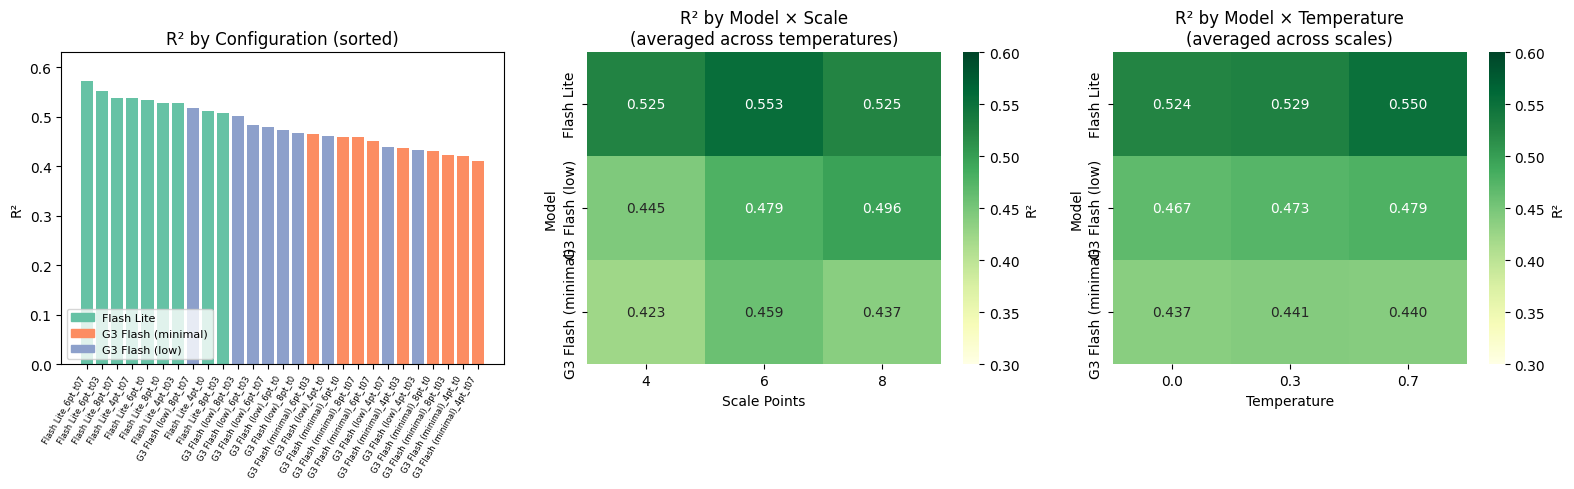

   ☁️  fig2_main_effects.png → Drive (main effects)


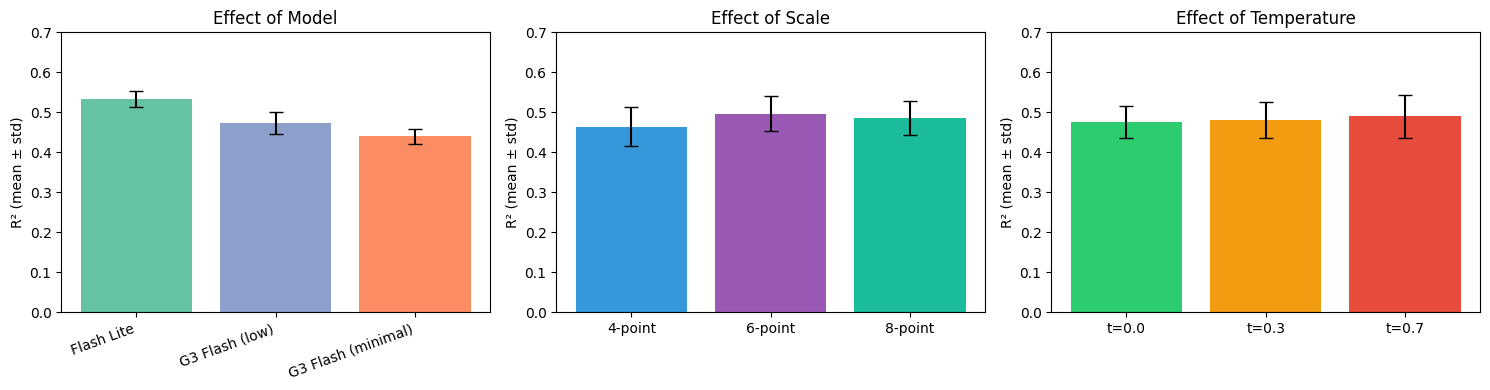

   ☁️  fig3_interactions.png → Drive (interactions)


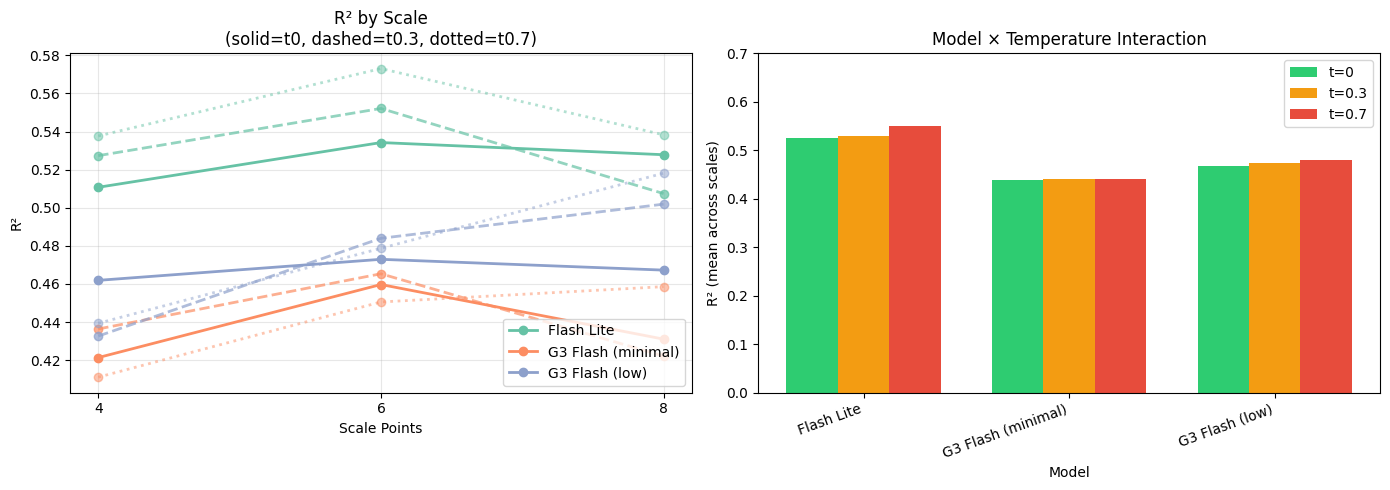

   ☁️  fig4_errors_time.png → Drive (errors and time)


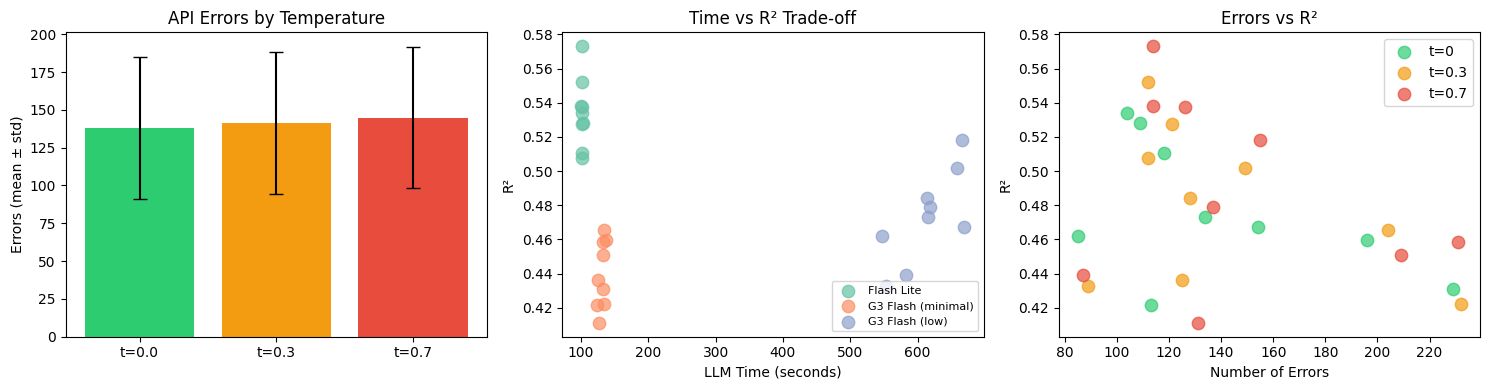

   ☁️  fig5_full_heatmaps.png → Drive (full heatmaps)


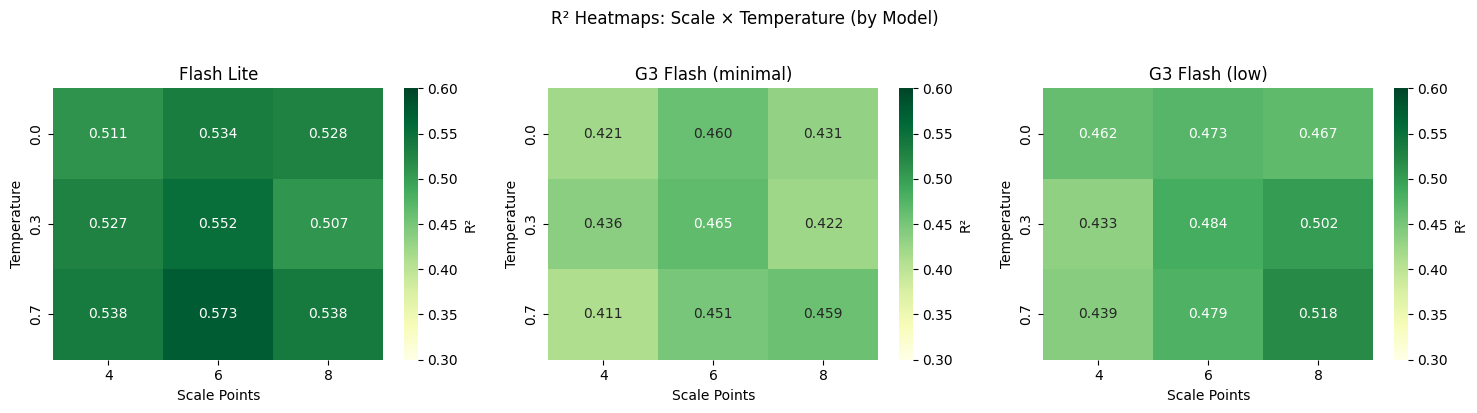

   ☁️  fig6_top_configs.png → Drive (top configs)


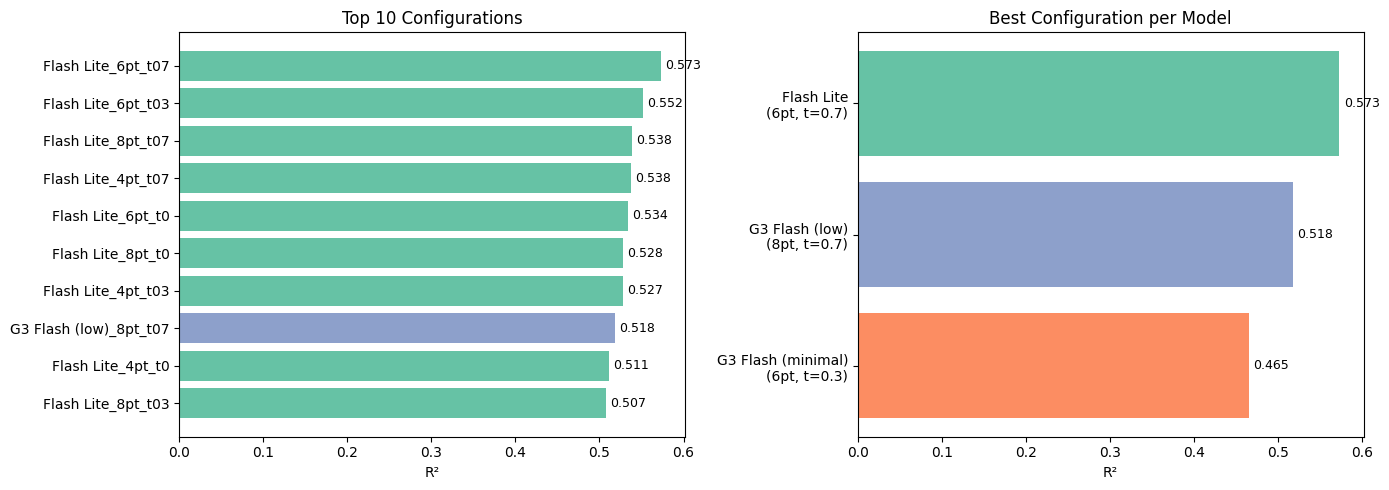


📊 VISUALIZATION SUMMARY

🏆 Best Configuration: Flash Lite_6pt_t07
   R² = 0.5731
   MAE = 1.2190
   Errors = 114
   Time = 101.3s

📈 R² Range: 0.411 - 0.573
   Spread: 0.162

💾 Saved figures:
   fig1_overview.png
   fig2_main_effects.png
   fig3_interactions.png
   fig4_errors_time.png
   fig5_full_heatmaps.png
   fig6_top_configs.png


In [14]:
# @title Cell 10: Visualization

# =============================================================================
# FIGURE 1: Overview (3 panels)
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Color palettes
model_labels = df_results['model'].unique()
model_colors = {label: plt.cm.Set2(i) for i, label in enumerate(model_labels)}
temp_colors = {0: '#2ecc71', 0.3: '#f39c12', 0.7: '#e74c3c'}
scale_colors = {4: '#3498db', 6: '#9b59b6', 8: '#1abc9c'}

# 1. R² by Configuration (sorted)
ax1 = axes[0]
x = range(len(df_results_sorted))
bars = ax1.bar(x, df_results_sorted['r2'],
               color=[model_colors[m] for m in df_results_sorted['model']])
ax1.set_xticks(x)
ax1.set_xticklabels(df_results_sorted['config_id'], rotation=60, ha='right', fontsize=6)
ax1.set_ylabel('R²')
ax1.set_title('R² by Configuration (sorted)')
ax1.set_ylim(0, max(df_results['r2']) * 1.1)

# Add legend for models
from matplotlib.patches import Patch
legend_patches = [Patch(color=model_colors[m], label=m) for m in model_labels]
ax1.legend(handles=legend_patches, loc='lower left', fontsize=8)

# 2. R² Heatmap (Model × Scale, averaged across temps)
ax2 = axes[1]
pivot_model_scale = df_results.pivot_table(values='r2', index='model', columns='scale', aggfunc='mean')
sns.heatmap(pivot_model_scale, annot=True, fmt='.3f', cmap='YlGn', ax=ax2,
            cbar_kws={'label': 'R²'}, vmin=0.3, vmax=0.6)
ax2.set_title('R² by Model × Scale\n(averaged across temperatures)')
ax2.set_xlabel('Scale Points')
ax2.set_ylabel('Model')

# 3. R² Heatmap (Model × Temperature, averaged across scales)
ax3 = axes[2]
pivot_model_temp = df_results.pivot_table(values='r2', index='model', columns='temperature', aggfunc='mean')
sns.heatmap(pivot_model_temp, annot=True, fmt='.3f', cmap='YlGn', ax=ax3,
            cbar_kws={'label': 'R²'}, vmin=0.3, vmax=0.6)
ax3.set_title('R² by Model × Temperature\n(averaged across scales)')
ax3.set_xlabel('Temperature')
ax3.set_ylabel('Model')

plt.tight_layout()
plt.savefig('fig1_overview.png', dpi=150, bbox_inches='tight')
save_to_drive('fig1_overview.png', 'overview')
plt.show()

# =============================================================================
# FIGURE 2: Main Effects (3 panels)
# =============================================================================
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))

# 1. Main effect of Model
ax1 = axes2[0]
model_effect = df_results.groupby('model')['r2'].agg(['mean', 'std']).sort_values('mean', ascending=False)
bars = ax1.bar(range(len(model_effect)), model_effect['mean'],
               yerr=model_effect['std'], capsize=5,
               color=[model_colors[m] for m in model_effect.index])
ax1.set_xticks(range(len(model_effect)))
ax1.set_xticklabels(model_effect.index, rotation=20, ha='right')
ax1.set_ylabel('R² (mean ± std)')
ax1.set_title('Effect of Model')
ax1.set_ylim(0, 0.7)

# 2. Main effect of Scale
ax2 = axes2[1]
scale_effect = df_results.groupby('scale')['r2'].agg(['mean', 'std']).sort_index()
bars = ax2.bar(range(len(scale_effect)), scale_effect['mean'],
               yerr=scale_effect['std'], capsize=5,
               color=[scale_colors[s] for s in scale_effect.index])
ax2.set_xticks(range(len(scale_effect)))
ax2.set_xticklabels([f'{s}-point' for s in scale_effect.index])
ax2.set_ylabel('R² (mean ± std)')
ax2.set_title('Effect of Scale')
ax2.set_ylim(0, 0.7)

# 3. Main effect of Temperature
ax3 = axes2[2]
temp_effect = df_results.groupby('temperature')['r2'].agg(['mean', 'std']).sort_index()
bars = ax3.bar(range(len(temp_effect)), temp_effect['mean'],
               yerr=temp_effect['std'], capsize=5,
               color=[temp_colors[t] for t in temp_effect.index])
ax3.set_xticks(range(len(temp_effect)))
ax3.set_xticklabels([f't={t}' for t in temp_effect.index])
ax3.set_ylabel('R² (mean ± std)')
ax3.set_title('Effect of Temperature')
ax3.set_ylim(0, 0.7)

plt.tight_layout()
plt.savefig('fig2_main_effects.png', dpi=150, bbox_inches='tight')
save_to_drive('fig2_main_effects.png', 'main effects')
plt.show()

# =============================================================================
# FIGURE 3: Interactions (2 panels)
# =============================================================================
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scale × Temperature interaction (lines for each model)
ax1 = axes3[0]
for model in model_labels:
    subset = df_results[df_results['model'] == model]
    for temp in TEMPERATURES:
        temp_subset = subset[subset['temperature'] == temp]
        linestyle = {0: '-', 0.3: '--', 0.7: ':'}[temp]
        alpha = {0: 1.0, 0.3: 0.7, 0.7: 0.5}[temp]
        if temp == 0:  # Only label once per model
            ax1.plot(temp_subset['scale'], temp_subset['r2'],
                    marker='o', linestyle=linestyle, color=model_colors[model],
                    label=model, alpha=alpha, linewidth=2)
        else:
            ax1.plot(temp_subset['scale'], temp_subset['r2'],
                    marker='o', linestyle=linestyle, color=model_colors[model],
                    alpha=alpha, linewidth=2)

ax1.set_xlabel('Scale Points')
ax1.set_ylabel('R²')
ax1.set_title('R² by Scale\n(solid=t0, dashed=t0.3, dotted=t0.7)')
ax1.legend(loc='lower right')
ax1.set_xticks([4, 6, 8])
ax1.grid(alpha=0.3)

# 2. Model × Temperature interaction (grouped bars)
ax2 = axes3[1]
width = 0.25
x_base = np.arange(len(model_labels))

for i, temp in enumerate(TEMPERATURES):
    temp_data = df_results[df_results['temperature'] == temp].groupby('model')['r2'].mean()
    # Reorder to match model_labels
    values = [temp_data.get(m, 0) for m in model_labels]
    ax2.bar(x_base + i*width, values, width, label=f't={temp}', color=temp_colors[temp])

ax2.set_xlabel('Model')
ax2.set_ylabel('R² (mean across scales)')
ax2.set_title('Model × Temperature Interaction')
ax2.set_xticks(x_base + width)
ax2.set_xticklabels(model_labels, rotation=20, ha='right')
ax2.legend()
ax2.set_ylim(0, 0.7)

plt.tight_layout()
plt.savefig('fig3_interactions.png', dpi=150, bbox_inches='tight')
save_to_drive('fig3_interactions.png', 'interactions')
plt.show()

# =============================================================================
# FIGURE 4: Error Analysis & Time Trade-offs (3 panels)
# =============================================================================
fig4, axes4 = plt.subplots(1, 3, figsize=(15, 4))

# 1. Errors by Temperature
ax1 = axes4[0]
error_by_temp = df_results.groupby('temperature')['errors'].agg(['mean', 'std'])
ax1.bar(range(len(error_by_temp)), error_by_temp['mean'],
        yerr=error_by_temp['std'], capsize=5,
        color=[temp_colors[t] for t in error_by_temp.index])
ax1.set_xticks(range(len(error_by_temp)))
ax1.set_xticklabels([f't={t}' for t in error_by_temp.index])
ax1.set_ylabel('Errors (mean ± std)')
ax1.set_title('API Errors by Temperature')

# 2. Time vs R² scatter (colored by model)
ax2 = axes4[1]
for model in model_labels:
    subset = df_results[df_results['model'] == model]
    ax2.scatter(subset['llm_time'], subset['r2'],
                label=model, s=80, color=model_colors[model], alpha=0.7)
ax2.set_xlabel('LLM Time (seconds)')
ax2.set_ylabel('R²')
ax2.set_title('Time vs R² Trade-off')
ax2.legend(loc='lower right', fontsize=8)

# 3. Errors vs R² scatter (colored by temperature)
ax3 = axes4[2]
for temp in TEMPERATURES:
    subset = df_results[df_results['temperature'] == temp]
    ax3.scatter(subset['errors'], subset['r2'],
                label=f't={temp}', s=80, color=temp_colors[temp], alpha=0.7)
ax3.set_xlabel('Number of Errors')
ax3.set_ylabel('R²')
ax3.set_title('Errors vs R²')
ax3.legend()

plt.tight_layout()
plt.savefig('fig4_errors_time.png', dpi=150, bbox_inches='tight')
save_to_drive('fig4_errors_time.png', 'errors and time')
plt.show()

# =============================================================================
# FIGURE 5: Full 3D Heatmap (Scale × Temperature for each Model)
# =============================================================================
fig5, axes5 = plt.subplots(1, 3, figsize=(15, 4))

for idx, model in enumerate(model_labels):
    ax = axes5[idx]
    model_data = df_results[df_results['model'] == model]
    pivot = model_data.pivot_table(values='r2', index='temperature', columns='scale', aggfunc='mean')

    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', ax=ax,
                cbar_kws={'label': 'R²'}, vmin=0.3, vmax=0.6)
    ax.set_title(f'{model}')
    ax.set_xlabel('Scale Points')
    ax.set_ylabel('Temperature')

plt.suptitle('R² Heatmaps: Scale × Temperature (by Model)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('fig5_full_heatmaps.png', dpi=150, bbox_inches='tight')
save_to_drive('fig5_full_heatmaps.png', 'full heatmaps')
plt.show()

# =============================================================================
# FIGURE 6: Top Configurations Summary
# =============================================================================
fig6, axes6 = plt.subplots(1, 2, figsize=(14, 5))

# 1. Top 10 configurations
ax1 = axes6[0]
top10 = df_results_sorted.head(10)
y_pos = range(len(top10))
ax1.barh(y_pos, top10['r2'], color=[model_colors[m] for m in top10['model']])
ax1.set_yticks(y_pos)
ax1.set_yticklabels(top10['config_id'])
ax1.set_xlabel('R²')
ax1.set_title('Top 10 Configurations')
ax1.invert_yaxis()

# Add value labels
for i, (idx, row) in enumerate(top10.iterrows()):
    ax1.text(row['r2'] + 0.005, i, f"{row['r2']:.3f}", va='center', fontsize=9)

# 2. Best config per model
ax2 = axes6[1]
best_per_model = df_results.loc[df_results.groupby('model')['r2'].idxmax()]
y_pos = range(len(best_per_model))
ax2.barh(y_pos, best_per_model['r2'], color=[model_colors[m] for m in best_per_model['model']])
ax2.set_yticks(y_pos)
ax2.set_yticklabels([f"{row['model']}\n({row['scale']}pt, t={row['temperature']})"
                     for _, row in best_per_model.iterrows()])
ax2.set_xlabel('R²')
ax2.set_title('Best Configuration per Model')
ax2.invert_yaxis()

# Add value labels
for i, (idx, row) in enumerate(best_per_model.iterrows()):
    ax2.text(row['r2'] + 0.005, i, f"{row['r2']:.3f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig6_top_configs.png', dpi=150, bbox_inches='tight')
save_to_drive('fig6_top_configs.png', 'top configs')
plt.show()

# =============================================================================
# SUMMARY STATISTICS
# =============================================================================
print("\n" + "="*60)
print("📊 VISUALIZATION SUMMARY")
print("="*60)

best = df_results_sorted.iloc[0]
print(f"\n🏆 Best Configuration: {best['config_id']}")
print(f"   R² = {best['r2']:.4f}")
print(f"   MAE = {best['mae']:.4f}")
print(f"   Errors = {best['errors']}")
print(f"   Time = {best['llm_time']:.1f}s")

print(f"\n📈 R² Range: {df_results['r2'].min():.3f} - {df_results['r2'].max():.3f}")
print(f"   Spread: {df_results['r2'].max() - df_results['r2'].min():.3f}")

print("\n💾 Saved figures:")
print("   fig1_overview.png")
print("   fig2_main_effects.png")
print("   fig3_interactions.png")
print("   fig4_errors_time.png")
print("   fig5_full_heatmaps.png")
print("   fig6_top_configs.png")

In [16]:
# @title Cell 11: Statistical Analysis

print("="*60)
print("📊 STATISTICAL ANALYSIS")
print("="*60)

# =============================================================================
# 1. MAIN EFFECTS
# =============================================================================
print("\n" + "="*60)
print("1️⃣ MAIN EFFECTS (marginal means)")
print("="*60)

# Effect of Model
print("\n📌 Effect of MODEL (averaged across scales & temperatures):")
model_effect = df_results.groupby('model').agg({
    'r2': ['mean', 'std', 'min', 'max'],
    'mae': ['mean', 'std'],
    'errors': 'mean',
    'llm_time': 'mean'
}).round(4)
model_effect.columns = ['_'.join(col).strip() for col in model_effect.columns]
model_effect = model_effect.sort_values('r2_mean', ascending=False)
print(model_effect.to_string())

# Effect of Scale
print("\n📌 Effect of SCALE (averaged across models & temperatures):")
scale_effect = df_results.groupby('scale').agg({
    'r2': ['mean', 'std', 'min', 'max'],
    'mae': ['mean', 'std'],
    'errors': 'mean'
}).round(4)
scale_effect.columns = ['_'.join(col).strip() for col in scale_effect.columns]
print(scale_effect.to_string())

# Effect of Temperature
print("\n📌 Effect of TEMPERATURE (averaged across models & scales):")
temp_effect = df_results.groupby('temperature').agg({
    'r2': ['mean', 'std', 'min', 'max'],
    'mae': ['mean', 'std'],
    'errors': 'mean'
}).round(4)
temp_effect.columns = ['_'.join(col).strip() for col in temp_effect.columns]
print(temp_effect.to_string())

# =============================================================================
# 2. TWO-WAY INTERACTIONS
# =============================================================================
print("\n" + "="*60)
print("2️⃣ TWO-WAY INTERACTIONS")
print("="*60)

# Model × Scale
print("\n📌 MODEL × SCALE interaction (R² means):")
model_scale = df_results.pivot_table(values='r2', index='model', columns='scale', aggfunc='mean').round(4)
print(model_scale.to_string())

# Model × Temperature
print("\n📌 MODEL × TEMPERATURE interaction (R² means):")
model_temp = df_results.pivot_table(values='r2', index='model', columns='temperature', aggfunc='mean').round(4)
print(model_temp.to_string())

# Scale × Temperature
print("\n📌 SCALE × TEMPERATURE interaction (R² means):")
scale_temp = df_results.pivot_table(values='r2', index='scale', columns='temperature', aggfunc='mean').round(4)
print(scale_temp.to_string())

# =============================================================================
# 3. BEST CONFIGURATIONS
# =============================================================================
print("\n" + "="*60)
print("3️⃣ BEST CONFIGURATIONS")
print("="*60)

# Overall best
print("\n🏆 TOP 5 OVERALL:")
top5 = df_results_sorted.head(5)[['config_id', 'model', 'scale', 'temperature', 'r2', 'mae', 'errors']]
print(top5.to_string(index=False))

# Best per model
print("\n🏆 BEST PER MODEL:")
best_per_model = df_results.loc[df_results.groupby('model')['r2'].idxmax()]
print(best_per_model[['model', 'scale', 'temperature', 'r2', 'mae']].to_string(index=False))

# Best per scale
print("\n🏆 BEST PER SCALE:")
best_per_scale = df_results.loc[df_results.groupby('scale')['r2'].idxmax()]
print(best_per_scale[['scale', 'model', 'temperature', 'r2', 'mae']].to_string(index=False))

# Best per temperature
print("\n🏆 BEST PER TEMPERATURE:")
best_per_temp = df_results.loc[df_results.groupby('temperature')['r2'].idxmax()]
print(best_per_temp[['temperature', 'model', 'scale', 'r2', 'mae']].to_string(index=False))

# =============================================================================
# 4. VARIANCE DECOMPOSITION
# =============================================================================
print("\n" + "="*60)
print("4️⃣ VARIANCE DECOMPOSITION")
print("="*60)

# Calculate how much each factor explains
grand_mean = df_results['r2'].mean()
total_var = df_results['r2'].var()

# Variance explained by each factor
model_var = df_results.groupby('model')['r2'].mean().var()
scale_var = df_results.groupby('scale')['r2'].mean().var()
temp_var = df_results.groupby('temperature')['r2'].mean().var()

print(f"\nGrand mean R²: {grand_mean:.4f}")
print(f"Total variance: {total_var:.6f}")
print(f"\nVariance in group means:")
print(f"  Model:       {model_var:.6f} ({model_var/total_var*100:.1f}% of total)")
print(f"  Scale:       {scale_var:.6f} ({scale_var/total_var*100:.1f}% of total)")
print(f"  Temperature: {temp_var:.6f} ({temp_var/total_var*100:.1f}% of total)")

# Effect sizes (range of means)
model_range = df_results.groupby('model')['r2'].mean().max() - df_results.groupby('model')['r2'].mean().min()
scale_range = df_results.groupby('scale')['r2'].mean().max() - df_results.groupby('scale')['r2'].mean().min()
temp_range = df_results.groupby('temperature')['r2'].mean().max() - df_results.groupby('temperature')['r2'].mean().min()

print(f"\nEffect sizes (range of means):")
print(f"  Model:       {model_range:.4f}")
print(f"  Scale:       {scale_range:.4f}")
print(f"  Temperature: {temp_range:.4f}")

# =============================================================================
# 5. ERROR ANALYSIS
# =============================================================================
print("\n" + "="*60)
print("5️⃣ ERROR ANALYSIS")
print("="*60)

print("\n📌 Errors by TEMPERATURE:")
error_temp = df_results.groupby('temperature')['errors'].agg(['mean', 'std', 'sum']).round(1)
print(error_temp.to_string())

print("\n📌 Errors by MODEL:")
error_model = df_results.groupby('model')['errors'].agg(['mean', 'std', 'sum']).round(1)
print(error_model.to_string())

# Correlation between errors and R²
error_r2_corr = df_results['errors'].corr(df_results['r2'])
print(f"\n📌 Correlation between errors and R²: {error_r2_corr:.3f}")

# =============================================================================
# 6. TIME ANALYSIS
# =============================================================================
print("\n" + "="*60)
print("6️⃣ TIME ANALYSIS")
print("="*60)

print("\n📌 LLM Time by MODEL:")
time_model = df_results.groupby('model')['llm_time'].agg(['mean', 'std', 'min', 'max']).round(1)
print(time_model.to_string())

# Efficiency: R² per minute
df_results['r2_per_minute'] = df_results['r2'] / (df_results['llm_time'] / 60)
print("\n📌 Efficiency (R² per minute) by MODEL:")
efficiency = df_results.groupby('model')['r2_per_minute'].mean().round(3)
print(efficiency.to_string())

# =============================================================================
# 7. STATISTICAL TESTS
# =============================================================================
print("\n" + "="*60)
print("7️⃣ STATISTICAL SIGNIFICANCE")
print("="*60)

# Simple t-tests between top models
from scipy import stats

models = df_results['model'].unique()
print("\n📌 Pairwise t-tests (R² between models):")
print("   (p-values, uncorrected)")
print()

# Create comparison matrix
for i, m1 in enumerate(models):
    for m2 in models[i+1:]:
        r2_m1 = df_results[df_results['model'] == m1]['r2'].values
        r2_m2 = df_results[df_results['model'] == m2]['r2'].values
        t_stat, p_val = stats.ttest_ind(r2_m1, r2_m2)
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        print(f"   {m1} vs {m2}: t={t_stat:.2f}, p={p_val:.4f} {sig}")

# Temperature effect test
print("\n📌 ANOVA for temperature effect:")
temp_groups = [df_results[df_results['temperature'] == t]['r2'].values for t in TEMPERATURES]
f_stat, p_val = stats.f_oneway(*temp_groups)
sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
print(f"   F={f_stat:.2f}, p={p_val:.4f} {sig}")

# Scale effect test
print("\n📌 ANOVA for scale effect:")
scale_groups = [df_results[df_results['scale'] == s]['r2'].values for s in [4, 6, 8]]
f_stat, p_val = stats.f_oneway(*scale_groups)
sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
print(f"   F={f_stat:.2f}, p={p_val:.4f} {sig}")

# =============================================================================
# 8. KEY TAKEAWAYS
# =============================================================================
print("\n" + "="*60)
print("8️⃣ KEY TAKEAWAYS")
print("="*60)

best = df_results_sorted.iloc[0]
worst = df_results_sorted.iloc[-1]

# Find dominant factors
factors = {
    'Model': model_range,
    'Scale': scale_range,
    'Temperature': temp_range
}
dominant_factor = max(factors, key=factors.get)

print(f"""
📊 SUMMARY:

1. BEST CONFIGURATION:
   {best['config_id']}
   R² = {best['r2']:.4f}, MAE = {best['mae']:.4f}

2. WORST CONFIGURATION:
   {worst['config_id']}
   R² = {worst['r2']:.4f}, MAE = {worst['mae']:.4f}

3. OVERALL SPREAD:
   R² range: {df_results['r2'].min():.4f} to {df_results['r2'].max():.4f}
   Difference: {df_results['r2'].max() - df_results['r2'].min():.4f}

4. DOMINANT FACTOR: {dominant_factor}
   (largest effect size: {factors[dominant_factor]:.4f})

5. OPTIMAL SETTINGS:
   - Best Model: {model_effect.index[0]}
   - Best Scale: {df_results.groupby('scale')['r2'].mean().idxmax()}-point
   - Best Temperature: {df_results.groupby('temperature')['r2'].mean().idxmax()}
""")

# Save analysis to file
analysis_summary = {
    'best_config': best['config_id'],
    'best_r2': best['r2'],
    'best_mae': best['mae'],
    'worst_config': worst['config_id'],
    'worst_r2': worst['r2'],
    'r2_range': df_results['r2'].max() - df_results['r2'].min(),
    'dominant_factor': dominant_factor,
    'best_model': model_effect.index[0],
    'best_scale': int(df_results.groupby('scale')['r2'].mean().idxmax()),
    'best_temperature': float(df_results.groupby('temperature')['r2'].mean().idxmax()),
    'model_effect_size': model_range,
    'scale_effect_size': scale_range,
    'temp_effect_size': temp_range
}

with open('statistical_analysis_summary.json', 'w') as f:
    json.dump(analysis_summary, f, indent=2)
save_to_drive('statistical_analysis_summary.json', 'stats summary')
print("💾 Saved: statistical_analysis_summary.json")

📊 STATISTICAL ANALYSIS

1️⃣ MAIN EFFECTS (marginal means)

📌 Effect of MODEL (averaged across scales & temperatures):
                    r2_mean  r2_std  r2_min  r2_max  mae_mean  mae_std  errors_mean  llm_time_mean
model                                                                                             
Flash Lite           0.5343  0.0200  0.5075  0.5731    1.2632   0.0227     114.4444       101.5922
G3 Flash (low)       0.4730  0.0273  0.4327  0.5182    1.3234   0.0403     124.2222       614.2042
G3 Flash (minimal)   0.4396  0.0196  0.4111  0.4654    1.3588   0.0179     185.5556       131.1239

📌 Effect of SCALE (averaged across models & temperatures):
       r2_mean  r2_std  r2_min  r2_max  mae_mean  mae_std  errors_mean
scale                                                                 
4       0.4643  0.0482  0.4111  0.5377    1.3416   0.0507     110.5556
6       0.4968  0.0445  0.4506  0.5731    1.3001   0.0500     148.6667
8       0.4859  0.0425  0.4222  0.5383    1

In [18]:
# @title Cell 12: Export Results

# =============================================================================
# EXPORT ALL RESULTS
# =============================================================================

print("="*60)
print("💾 EXPORTING RESULTS")
print("="*60)

# 1. Main results CSV
df_results.to_csv('grid_comparison_results.csv', index=False)
save_to_drive('grid_comparison_results.csv', 'main results')
print("\n✅ grid_comparison_results.csv")

# 2. Sorted results CSV
df_results_sorted.to_csv('grid_comparison_results_sorted.csv', index=False)
save_to_drive('grid_comparison_results_sorted.csv', 'sorted results')
print("✅ grid_comparison_results_sorted.csv")

# 3. Summary by model
summary_model = df_results.groupby('model').agg({
    'r2': ['mean', 'std', 'max'],
    'mae': ['mean', 'std', 'min'],
    'errors': 'sum',
    'llm_time': 'mean'
}).round(4)
summary_model.columns = ['_'.join(col) for col in summary_model.columns]
summary_model.to_csv('summary_by_model.csv')
save_to_drive('summary_by_model.csv', 'model summary')
print("✅ summary_by_model.csv")

# 4. Summary by scale
summary_scale = df_results.groupby('scale').agg({
    'r2': ['mean', 'std', 'max'],
    'mae': ['mean', 'std', 'min'],
    'errors': 'sum'
}).round(4)
summary_scale.columns = ['_'.join(col) for col in summary_scale.columns]
summary_scale.to_csv('summary_by_scale.csv')
save_to_drive('summary_by_scale.csv', 'scale summary')
print("✅ summary_by_scale.csv")

# 5. Summary by temperature
summary_temp = df_results.groupby('temperature').agg({
    'r2': ['mean', 'std', 'max'],
    'mae': ['mean', 'std', 'min'],
    'errors': 'sum'
}).round(4)
summary_temp.columns = ['_'.join(col) for col in summary_temp.columns]
summary_temp.to_csv('summary_by_temperature.csv')
save_to_drive('summary_by_temperature.csv', 'temperature summary')
print("✅ summary_by_temperature.csv")

# =============================================================================
# GENERATE TEXT REPORT
# =============================================================================

best = df_results_sorted.iloc[0]
worst = df_results_sorted.iloc[-1]

report = f"""
{'='*70}
SENSORY ANALYSIS GRID COMPARISON REPORT
{'='*70}

Generated: {time.strftime('%Y-%m-%d %H:%M:%S')}
Test Mode: {TEST_MODE}
Samples: {len(df_data)}

{'='*70}
GRID CONFIGURATION
{'='*70}

Models: {len(MODELS)}
  - {', '.join([m['label'] for m in MODELS])}

Scales: {list(SCALES.keys())}
Temperatures: {TEMPERATURES}
Total Configurations: {len(df_results)}

{'='*70}
RESULTS SUMMARY
{'='*70}

All configurations (sorted by R²):
{'-'*70}
"""

for i, (_, row) in enumerate(df_results_sorted.iterrows(), 1):
    report += f"{i:2d}. {row['config_id']:30s} R²={row['r2']:.4f}  MAE={row['mae']:.4f}  Errors={row['errors']:3.0f}\n"

report += f"""
{'='*70}
BEST CONFIGURATION
{'='*70}

Config:      {best['config_id']}
Model:       {best['model_name']}
Scale:       {best['scale']}-point
Temperature: {best['temperature']}

Performance:
  R²:   {best['r2']:.4f}
  MAE:  {best['mae']:.4f}
  Time: {best['llm_time']:.1f}s

{'='*70}
MAIN EFFECTS SUMMARY
{'='*70}

By Model (mean R²):
"""

for model in df_results.groupby('model')['r2'].mean().sort_values(ascending=False).items():
    report += f"  {model[0]:25s} {model[1]:.4f}\n"

report += "\nBy Scale (mean R²):\n"
for scale in df_results.groupby('scale')['r2'].mean().sort_values(ascending=False).items():
    report += f"  {scale[0]}-point:                {scale[1]:.4f}\n"

report += "\nBy Temperature (mean R²):\n"
for temp in df_results.groupby('temperature')['r2'].mean().sort_values(ascending=False).items():
    report += f"  t={temp[0]}:                    {temp[1]:.4f}\n"

report += f"""
{'='*70}
RECOMMENDATIONS
{'='*70}

Based on this grid comparison:

1. OPTIMAL MODEL: {df_results.groupby('model')['r2'].mean().idxmax()}
2. OPTIMAL SCALE: {df_results.groupby('scale')['r2'].mean().idxmax()}-point
3. OPTIMAL TEMPERATURE: {df_results.groupby('temperature')['r2'].mean().idxmax()}

Best overall: {best['config_id']} (R²={best['r2']:.4f})

{'='*70}
"""

# Save report
with open('grid_comparison_report.txt', 'w') as f:
    f.write(report)
save_to_drive('grid_comparison_report.txt', 'text report')
print("✅ grid_comparison_report.txt")

# Print report
print("\n" + report)

# =============================================================================
# SAVE FINAL STATE
# =============================================================================
print("\n" + "="*60)
print("💾 SAVING FINAL STATE")
print("="*60)

save_final_outputs(all_scores, df_data, all_results)

print("\n" + "="*60)
print("✅ ALL EXPORTS COMPLETE")
print("="*60)
print(f"\nFiles saved to Google Drive: {DRIVE_OUTPUT_DIR}")

💾 EXPORTING RESULTS
   ☁️  grid_comparison_results.csv → Drive (main results)

✅ grid_comparison_results.csv
   ☁️  grid_comparison_results_sorted.csv → Drive (sorted results)
✅ grid_comparison_results_sorted.csv
   ☁️  summary_by_model.csv → Drive (model summary)
✅ summary_by_model.csv
   ☁️  summary_by_scale.csv → Drive (scale summary)
✅ summary_by_scale.csv
   ☁️  summary_by_temperature.csv → Drive (temperature summary)
✅ summary_by_temperature.csv
   ☁️  grid_comparison_report.txt → Drive (text report)
✅ grid_comparison_report.txt


SENSORY ANALYSIS GRID COMPARISON REPORT

Generated: 2026-01-15 21:02:02
Test Mode: False
Samples: 2758

GRID CONFIGURATION

Models: 3
  - Flash Lite, G3 Flash (minimal), G3 Flash (low)

Scales: [4, 6, 8]
Temperatures: [0, 0.3, 0.7]
Total Configurations: 27

RESULTS SUMMARY

All configurations (sorted by R²):
----------------------------------------------------------------------
 1. Flash Lite_6pt_t07             R²=0.5731  MAE=1.2190  Errors=114
 2. Fla

In [19]:
# @title Cell 12b: Save All State (Run before closing Colab)
# =============================================================================
# SAVE ALL STATE
# =============================================================================
# Run this cell before closing Colab to ensure all data is saved.
# This is also called automatically at the end of Cell 8, but you can
# run it again anytime to ensure the latest state is saved.

import json
import os
from pathlib import Path

def save_all_state_now():
    """Save all current state to files."""

    saved_files = []

    # 1. Save all_scores
    if 'all_scores' in dir() and all_scores:
        serializable = {}
        for cfg_id, scores in all_scores.items():
            serializable[cfg_id] = {str(k): v for k, v in scores.items()}

        with open('all_scores_final.json', 'w') as f:
            json.dump(serializable, f, indent=2)
        saved_files.append(('all_scores_final.json', f'{len(all_scores)} configs'))

        # Also update checkpoint
        Path("checkpoints").mkdir(exist_ok=True)
        with open('checkpoints/all_scores_checkpoint.json', 'w') as f:
            json.dump(serializable, f)
        saved_files.append(('checkpoints/all_scores_checkpoint.json', 'backup'))

    # 2. Save df_data
    if 'df_data' in dir() and df_data is not None:
        df_data.to_csv('df_data.csv', index=False)
        saved_files.append(('df_data.csv', f'{len(df_data)} rows'))

    # 3. Save all_results
    if 'all_results' in dir() and all_results:
        df_res = pd.DataFrame(all_results)
        df_res.to_csv('grid_comparison_results.csv', index=False)
        saved_files.append(('grid_comparison_results.csv', f'{len(all_results)} results'))

    # 4. Save bootstrap results if available
    if 'bootstrap_results_a' in dir() and bootstrap_results_a:
        # Convert numpy arrays to lists for JSON serialization
        serializable_boot = {}
        for cfg_id, result in bootstrap_results_a.items():
            serializable_boot[cfg_id] = {
                k: v.tolist() if hasattr(v, 'tolist') else v
                for k, v in result.items()
            }
        with open('bootstrap_results_a.json', 'w') as f:
            json.dump(serializable_boot, f, indent=2)
        saved_files.append(('bootstrap_results_a.json', f'{len(bootstrap_results_a)} configs'))

    return saved_files

# Execute save
print("="*60)
print("💾 SAVING ALL STATE")
print("="*60)

saved = save_all_state_now()

print("\nSaved files:")
for fname, desc in saved:
    fsize = os.path.getsize(fname) if os.path.exists(fname) else 0
    print(f"   ✅ {fname}: {desc} ({fsize/1024:.1f} KB)")

print("\n" + "="*60)
print("✅ All state saved locally!")
print("="*60)

# Sync everything to Google Drive
print("\n☁️  Syncing all files to Google Drive...")
n_synced = save_all_to_drive()
print(f"\n✅ Synced {n_synced} files to Google Drive")
print(f"   Location: {DRIVE_OUTPUT_DIR}")

print("\n" + "="*60)
print("✅ All state saved to local AND Google Drive!")
print("="*60)
print("\nYou can safely close Colab. To recover:")
print("   1. Reopen this notebook")
print("   2. Run Cells 1-4 (Setup)")
print("   3. Run Cell 4b (Recovery)")
print("\nOr copy files from Google Drive:")
print(f"   {DRIVE_OUTPUT_DIR}")


💾 SAVING ALL STATE

Saved files:

✅ All state saved locally!

☁️  Syncing all files to Google Drive...
   ☁️  all_scores_final.json → Drive (LLM scores)
   ☁️  df_data.csv → Drive (processed data)
   ☁️  grid_comparison_results.csv → Drive (evaluation metrics)
   ☁️  all_scores_checkpoint.json → Drive (checkpoint)
   ☁️  grid_comparison_results.png → Drive (main visualization)
   ☁️  temperature_effect_results.png → Drive (temperature viz)

✅ Synced 6 files to Google Drive
   Location: /content/drive/MyDrive/sensory_analysis_outputs

✅ All state saved to local AND Google Drive!

You can safely close Colab. To recover:
   1. Reopen this notebook
   2. Run Cells 1-4 (Setup)
   3. Run Cell 4b (Recovery)

Or copy files from Google Drive:
   /content/drive/MyDrive/sensory_analysis_outputs


In [21]:
# @title Cell 13: Recommendations

print("="*60)
print("📝 RECOMMENDATIONS")
print("="*60)

# =============================================================================
# ANALYZE RESULTS
# =============================================================================

# Best settings by factor
best_model = df_results.groupby('model')['r2'].mean().idxmax()
best_scale = df_results.groupby('scale')['r2'].mean().idxmax()
best_temp = df_results.groupby('temperature')['r2'].mean().idxmax()

# Effect sizes
model_effect = df_results.groupby('model')['r2'].mean().max() - df_results.groupby('model')['r2'].mean().min()
scale_effect = df_results.groupby('scale')['r2'].mean().max() - df_results.groupby('scale')['r2'].mean().min()
temp_effect = df_results.groupby('temperature')['r2'].mean().max() - df_results.groupby('temperature')['r2'].mean().min()

# Best overall
best = df_results_sorted.iloc[0]

# =============================================================================
# PRINT RECOMMENDATIONS
# =============================================================================

print(f"""
Based on the grid comparison of {len(df_results)} configurations:

{'='*60}
1. OPTIMAL MODEL: {best_model}
{'='*60}
   Mean R²: {df_results[df_results['model'] == best_model]['r2'].mean():.4f}
   Effect size: {model_effect:.4f} (range across models)
""")

# Model ranking
print("   Model ranking (by mean R²):")
model_ranking = df_results.groupby('model')['r2'].mean().sort_values(ascending=False)
for i, (model, r2) in enumerate(model_ranking.items(), 1):
    marker = "👑" if i == 1 else "  "
    print(f"   {marker} {i}. {model}: {r2:.4f}")

print(f"""
{'='*60}
2. OPTIMAL SCALE: {best_scale}-point
{'='*60}
   Mean R²: {df_results[df_results['scale'] == best_scale]['r2'].mean():.4f}
   Effect size: {scale_effect:.4f} (range across scales)
""")

# Scale ranking
print("   Scale ranking (by mean R²):")
scale_ranking = df_results.groupby('scale')['r2'].mean().sort_values(ascending=False)
for i, (scale, r2) in enumerate(scale_ranking.items(), 1):
    marker = "👑" if i == 1 else "  "
    print(f"   {marker} {i}. {scale}-point: {r2:.4f}")

print(f"""
{'='*60}
3. OPTIMAL TEMPERATURE: {best_temp}
{'='*60}
   Mean R²: {df_results[df_results['temperature'] == best_temp]['r2'].mean():.4f}
   Effect size: {temp_effect:.4f} (range across temperatures)
""")

# Temperature ranking
print("   Temperature ranking (by mean R²):")
temp_ranking = df_results.groupby('temperature')['r2'].mean().sort_values(ascending=False)
for i, (temp, r2) in enumerate(temp_ranking.items(), 1):
    marker = "👑" if i == 1 else "  "
    print(f"   {marker} {i}. t={temp}: {r2:.4f}")

# =============================================================================
# THINKING LEVEL ANALYSIS (for Gemini 3 models)
# =============================================================================
print(f"""
{'='*60}
4. THINKING LEVEL ANALYSIS (Gemini 3 only)
{'='*60}
""")

g3_results = df_results[df_results['model'].str.contains('G3')]
if len(g3_results) > 0:
    # Extract thinking level from model name
    minimal_results = g3_results[g3_results['model'].str.contains('minimal')]
    low_results = g3_results[g3_results['model'].str.contains('low')]

    if len(minimal_results) > 0 and len(low_results) > 0:
        minimal_r2 = minimal_results['r2'].mean()
        low_r2 = low_results['r2'].mean()
        minimal_time = minimal_results['llm_time'].mean()
        low_time = low_results['llm_time'].mean()

        print(f"   Minimal thinking: R²={minimal_r2:.4f}, Time={minimal_time:.1f}s")
        print(f"   Low thinking:     R²={low_r2:.4f}, Time={low_time:.1f}s")
        print(f"   Difference:       {low_r2 - minimal_r2:+.4f} R², {low_time - minimal_time:+.1f}s")

        if low_r2 > minimal_r2:
            print(f"\n   → Low thinking is better but {low_time/minimal_time:.1f}x slower")
        else:
            print(f"\n   → Minimal thinking is better and faster")
    else:
        print("   (Could not compare thinking levels)")
else:
    print("   (No Gemini 3 results found)")

# =============================================================================
# ERROR ANALYSIS
# =============================================================================
print(f"""
{'='*60}
5. ERROR ANALYSIS
{'='*60}
""")

# Temperature effect on errors
error_by_temp = df_results.groupby('temperature')['errors'].mean()
print("   Errors by temperature:")
for temp, errors in error_by_temp.items():
    print(f"      t={temp}: {errors:.1f} mean errors")

if error_by_temp.max() > error_by_temp.min() * 1.5:
    worst_temp = error_by_temp.idxmax()
    print(f"\n   ⚠️  Temperature {worst_temp} has significantly more errors")

# =============================================================================
# FINAL RECOMMENDATION
# =============================================================================
print(f"""
{'='*60}
🏆 FINAL RECOMMENDATION
{'='*60}

For production use:

   Model:       {best['model_name']}
   Scale:       {best['scale']}-point
   Temperature: {best['temperature']}

   Expected R²: {best['r2']:.4f}
   Expected MAE: {best['mae']:.4f}

Configuration ID: {best['config_id']}

{'='*60}
""")

# =============================================================================
# PRACTICAL CONSIDERATIONS
# =============================================================================
print("""
💡 PRACTICAL CONSIDERATIONS:

1. COST/SPEED TRADE-OFF:
""")

# Find fastest model with good R²
time_ranking = df_results.groupby('model')['llm_time'].mean().sort_values()
r2_by_model = df_results.groupby('model')['r2'].mean()

for model, avg_time in time_ranking.items():
    r2 = r2_by_model[model]
    print(f"   {model}: {avg_time:.0f}s avg, R²={r2:.4f}")

print("""
2. ROBUSTNESS:
""")

# Find most consistent configuration (lowest std)
df_results['r2_rank'] = df_results.groupby(['model', 'scale'])['r2'].transform('std')
most_consistent = df_results.groupby('model')['r2'].std().idxmin()
print(f"   Most consistent model: {most_consistent}")
print(f"   (lowest variance across temperatures)")

print("""
3. IF ERRORS ARE A CONCERN:
""")
lowest_error_temp = df_results.groupby('temperature')['errors'].mean().idxmin()
print(f"   Use temperature = {lowest_error_temp}")
print(f"   (lowest average error rate)")

📝 RECOMMENDATIONS

Based on the grid comparison of 27 configurations:

1. OPTIMAL MODEL: Flash Lite
   Mean R²: 0.5343
   Effect size: 0.0947 (range across models)

   Model ranking (by mean R²):
   👑 1. Flash Lite: 0.5343
      2. G3 Flash (low): 0.4730
      3. G3 Flash (minimal): 0.4396

2. OPTIMAL SCALE: 6-point
   Mean R²: 0.4968
   Effect size: 0.0325 (range across scales)

   Scale ranking (by mean R²):
   👑 1. 6-point: 0.4968
      2. 8-point: 0.4859
      3. 4-point: 0.4643

3. OPTIMAL TEMPERATURE: 0.7
   Mean R²: 0.4895
   Effect size: 0.0132 (range across temperatures)

   Temperature ranking (by mean R²):
   👑 1. t=0.7: 0.4895
      2. t=0.3: 0.4811
      3. t=0.0: 0.4764

4. THINKING LEVEL ANALYSIS (Gemini 3 only)

   Minimal thinking: R²=0.4396, Time=131.1s
   Low thinking:     R²=0.4730, Time=614.2s
   Difference:       +0.0334 R², +483.1s

   → Low thinking is better but 4.7x slower

5. ERROR ANALYSIS

   Errors by temperature:
      t=0.0: 138.0 mean errors
      t=0.3

🎯 FEATURE IMPORTANCE ANALYSIS

Computing feature importances for each configuration...
(This may take a few minutes)

   Processing Flash Lite_4pt_t0... done
   Processing Flash Lite_4pt_t03... done
   Processing Flash Lite_4pt_t07... done
   Processing Flash Lite_6pt_t0... done
   Processing Flash Lite_6pt_t03... done
   Processing Flash Lite_6pt_t07... done
   Processing Flash Lite_8pt_t0... done
   Processing Flash Lite_8pt_t03... done
   Processing Flash Lite_8pt_t07... done
   Processing G3 Flash (minimal)_4pt_t0... done
   Processing G3 Flash (minimal)_4pt_t03... done
   Processing G3 Flash (minimal)_4pt_t07... done
   Processing G3 Flash (minimal)_6pt_t0... done
   Processing G3 Flash (minimal)_6pt_t03... done
   Processing G3 Flash (minimal)_6pt_t07... done
   Processing G3 Flash (minimal)_8pt_t0... done
   Processing G3 Flash (minimal)_8pt_t03... done
   Processing G3 Flash (minimal)_8pt_t07... done
   Processing G3 Flash (low)_4pt_t0... done
   Processing G3 Flash (low)_4pt_t

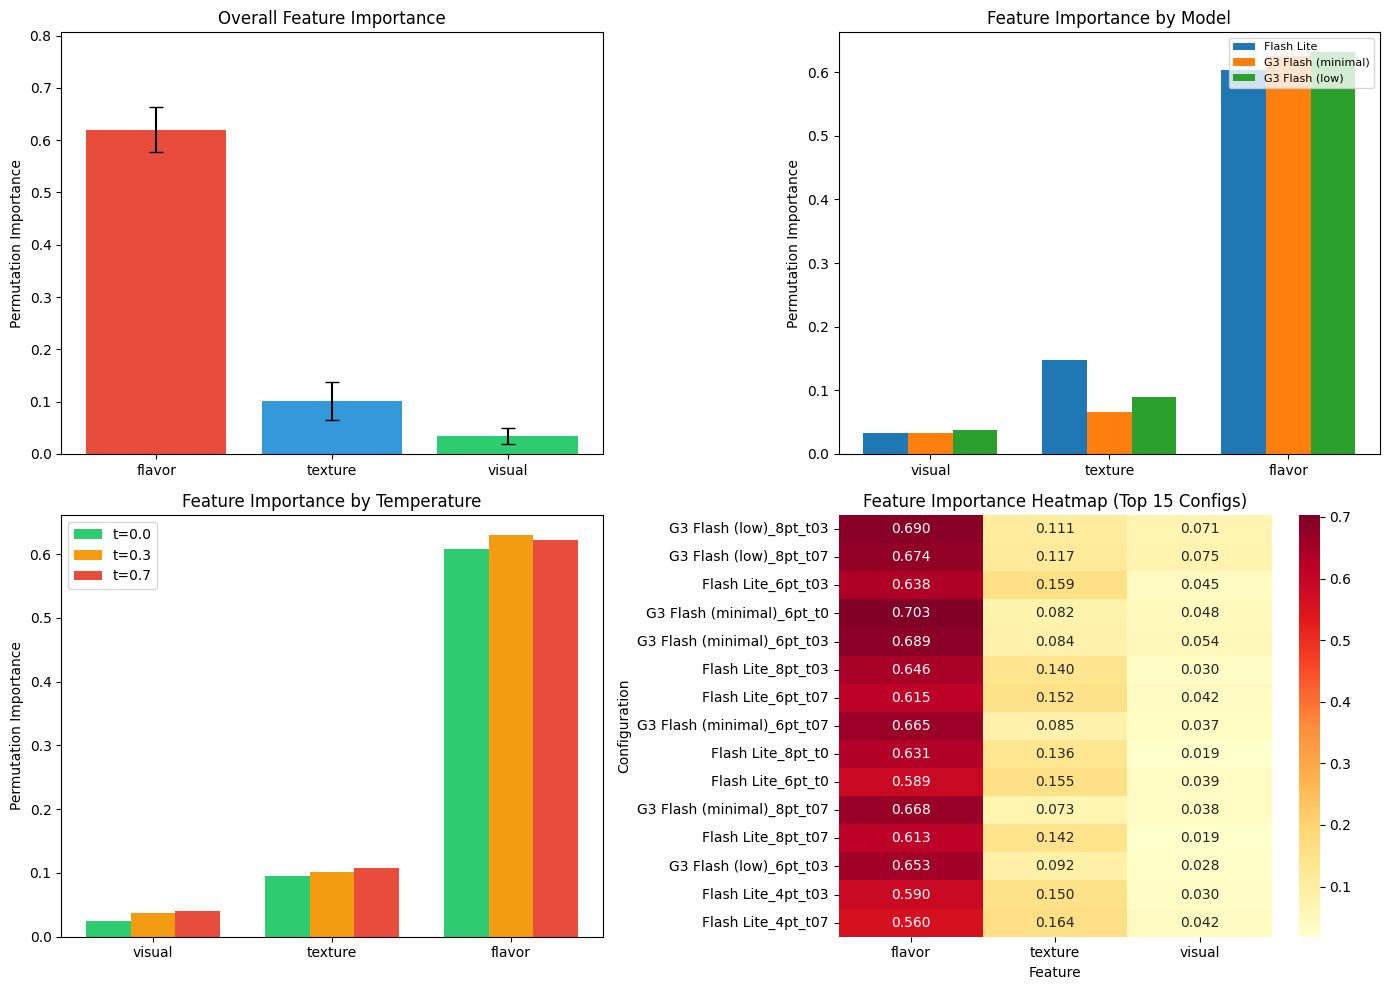


💾 Saved: feature_importance_analysis.png
   ☁️  feature_importance_results.csv → Drive (feature importance data)
💾 Saved: feature_importance_results.csv

💡 KEY INSIGHT

The most important feature for predicting liking scores is: FLAVOR

This suggests that flavor alignment between actual and ideal
experiences has the strongest influence on consumer satisfaction.

Relative importance:

   flavor: 82.1%
   texture: 13.4%
   visual: 4.5%


In [23]:
# @title Cell 14: Feature Importance Analysis

print("="*60)
print("🎯 FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# =============================================================================
# COMPUTE FEATURE IMPORTANCE FOR EACH CONFIGURATION
# =============================================================================

from sklearn.inspection import permutation_importance

feature_importance_results = []

print("\nComputing feature importances for each configuration...")
print("(This may take a few minutes)\n")

for config_id, scores in all_scores.items():
    print(f"   Processing {config_id}...", end=" ")

    # Parse scale from config_id (format: "Model_Xpt_tY")
    try:
        parts = config_id.rsplit('_', 2)
        scale_points = int(parts[1].replace('pt', ''))
    except:
        print("skipped (couldn't parse)")
        continue

    # Apply scores to dataframe
    df_temp = df_data.copy()

    for feat in FEATURES:
        df_temp[feat] = df_temp.index.map(lambda idx: scores.get(idx, {}).get(feat))

    # Drop rows with missing scores
    df_temp = df_temp.dropna(subset=FEATURES)

    if len(df_temp) < 100:
        print(f"skipped (only {len(df_temp)} valid rows)")
        continue

    # Normalize features
    for feat in FEATURES:
        df_temp[f'{feat}_norm'] = (df_temp[feat] - 1) / (scale_points - 1) * 10

    # Prepare data
    feature_cols = [f'{feat}_norm' for feat in FEATURES]
    X = df_temp[feature_cols].values
    y = df_temp['Liking_Score'].values
    groups = df_temp['Consumer'].values

    # Train/test split
    splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    train_idx, test_idx = next(splitter.split(X, y, groups))

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Fit model
    model = TabPFNRegressor(device=device)
    model.fit(X_train, y_train)

    # Compute permutation importance
    perm_importance = permutation_importance(
        model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
    )

    # Store results
    for i, feat in enumerate(FEATURES):
        feature_importance_results.append({
            'config_id': config_id,
            'feature': feat,
            'importance_mean': perm_importance.importances_mean[i],
            'importance_std': perm_importance.importances_std[i]
        })

    print(f"done")

# Create dataframe
df_importance = pd.DataFrame(feature_importance_results)

print(f"\n✅ Computed importance for {df_importance['config_id'].nunique()} configurations")

# =============================================================================
# ANALYZE FEATURE IMPORTANCE
# =============================================================================

print("\n" + "="*60)
print("📊 FEATURE IMPORTANCE SUMMARY")
print("="*60)

# Overall importance by feature
print("\n📌 Overall importance (averaged across all configs):")
overall_importance = df_importance.groupby('feature')['importance_mean'].agg(['mean', 'std']).sort_values('mean', ascending=False)
for feat, row in overall_importance.iterrows():
    print(f"   {feat:10s}: {row['mean']:.4f} ± {row['std']:.4f}")

# Most important feature
most_important = overall_importance.index[0]
print(f"\n   → {most_important.upper()} is the most important feature")

# =============================================================================
# IMPORTANCE BY MODEL
# =============================================================================

print("\n📌 Feature importance by MODEL:")

# Extract model from config_id
df_importance['model'] = df_importance['config_id'].apply(lambda x: x.rsplit('_', 2)[0])

for model in df_importance['model'].unique():
    model_data = df_importance[df_importance['model'] == model]
    print(f"\n   {model}:")
    model_imp = model_data.groupby('feature')['importance_mean'].mean().sort_values(ascending=False)
    for feat, imp in model_imp.items():
        print(f"      {feat}: {imp:.4f}")

# =============================================================================
# IMPORTANCE BY TEMPERATURE
# =============================================================================

print("\n📌 Feature importance by TEMPERATURE:")

# Extract temperature from config_id
def extract_temp(config_id):
    temp_str = config_id.rsplit('_', 1)[-1]  # e.g., "t0", "t03", "t07"
    if temp_str == 't0':
        return 0.0
    elif temp_str == 't03':
        return 0.3
    elif temp_str == 't07':
        return 0.7
    return None

df_importance['temperature'] = df_importance['config_id'].apply(extract_temp)

for temp in sorted(df_importance['temperature'].dropna().unique()):
    temp_data = df_importance[df_importance['temperature'] == temp]
    print(f"\n   t={temp}:")
    temp_imp = temp_data.groupby('feature')['importance_mean'].mean().sort_values(ascending=False)
    for feat, imp in temp_imp.items():
        print(f"      {feat}: {imp:.4f}")

# =============================================================================
# VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Overall feature importance
ax1 = axes[0, 0]
colors = ['#e74c3c', '#3498db', '#2ecc71']
bars = ax1.bar(overall_importance.index, overall_importance['mean'],
               yerr=overall_importance['std'], capsize=5, color=colors)
ax1.set_ylabel('Permutation Importance')
ax1.set_title('Overall Feature Importance')
ax1.set_ylim(0, max(overall_importance['mean']) * 1.3)

# 2. Feature importance by model
ax2 = axes[0, 1]
models = df_importance['model'].unique()
x = np.arange(len(FEATURES))
width = 0.25

for i, model in enumerate(models):
    model_data = df_importance[df_importance['model'] == model]
    importances = [model_data[model_data['feature'] == f]['importance_mean'].mean() for f in FEATURES]
    ax2.bar(x + i*width, importances, width, label=model)

ax2.set_xticks(x + width)
ax2.set_xticklabels(FEATURES)
ax2.set_ylabel('Permutation Importance')
ax2.set_title('Feature Importance by Model')
ax2.legend(loc='upper right', fontsize=8)

# 3. Feature importance by temperature
ax3 = axes[1, 0]
temps = sorted(df_importance['temperature'].dropna().unique())
x = np.arange(len(FEATURES))
width = 0.25
temp_colors = {0.0: '#2ecc71', 0.3: '#f39c12', 0.7: '#e74c3c'}

for i, temp in enumerate(temps):
    temp_data = df_importance[df_importance['temperature'] == temp]
    importances = [temp_data[temp_data['feature'] == f]['importance_mean'].mean() for f in FEATURES]
    ax3.bar(x + i*width, importances, width, label=f't={temp}', color=temp_colors.get(temp, 'gray'))

ax3.set_xticks(x + width)
ax3.set_xticklabels(FEATURES)
ax3.set_ylabel('Permutation Importance')
ax3.set_title('Feature Importance by Temperature')
ax3.legend()

# 4. Heatmap of importance (config × feature)
ax4 = axes[1, 1]
pivot_importance = df_importance.pivot_table(
    values='importance_mean',
    index='config_id',
    columns='feature',
    aggfunc='mean'
)
# Sort by total importance
pivot_importance['total'] = pivot_importance.sum(axis=1)
pivot_importance = pivot_importance.sort_values('total', ascending=False).drop('total', axis=1)

# Show top 15 configs
sns.heatmap(pivot_importance.head(15), annot=True, fmt='.3f', cmap='YlOrRd', ax=ax4)
ax4.set_title('Feature Importance Heatmap (Top 15 Configs)')
ax4.set_xlabel('Feature')
ax4.set_ylabel('Configuration')

plt.tight_layout()
plt.savefig('feature_importance_analysis.png', dpi=150, bbox_inches='tight')
save_to_drive('feature_importance_analysis.png', 'feature importance')
plt.show()

print("\n💾 Saved: feature_importance_analysis.png")

# =============================================================================
# SAVE RESULTS
# =============================================================================

df_importance.to_csv('feature_importance_results.csv', index=False)
save_to_drive('feature_importance_results.csv', 'feature importance data')
print("💾 Saved: feature_importance_results.csv")

# =============================================================================
# KEY INSIGHT
# =============================================================================

print("\n" + "="*60)
print("💡 KEY INSIGHT")
print("="*60)
print(f"""
The most important feature for predicting liking scores is: {most_important.upper()}

This suggests that {most_important} alignment between actual and ideal
experiences has the strongest influence on consumer satisfaction.

Relative importance:
""")
total_imp = overall_importance['mean'].sum()
for feat, row in overall_importance.iterrows():
    pct = row['mean'] / total_imp * 100
    print(f"   {feat}: {pct:.1f}%")

In [24]:
# @title Cell 15: ML Model Comparison (All Configurations)

print("="*60)
print("🤖 ML MODEL COMPARISON")
print("="*60)

# =============================================================================
# ML MODELS TO TEST
# =============================================================================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ImportError:
    print("⚠️  XGBoost not installed, skipping...")
    HAS_XGBOOST = False

# Define models
ML_MODELS = {
    'TabPFN': lambda: TabPFNRegressor(device=device),
    'Ridge': lambda: Ridge(alpha=1.0),
    'RandomForest': lambda: RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'GradientBoosting': lambda: GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
}

if HAS_XGBOOST:
    ML_MODELS['XGBoost'] = lambda: XGBRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)

print(f"\nML Models to test: {list(ML_MODELS.keys())}")
print(f"LLM Configurations: {len(all_scores)}")
print(f"Total combinations: {len(ML_MODELS) * len(all_scores)}")

# =============================================================================
# RUN ALL COMBINATIONS
# =============================================================================

print("\n" + "="*60)
print("Running all ML model × LLM config combinations...")
print("="*60 + "\n")

ml_comparison_results = []
combo_num = 0
total_combos = len(ML_MODELS) * len(all_scores)

for config_id, scores in all_scores.items():
    # Parse scale from config_id
    try:
        parts = config_id.rsplit('_', 2)
        scale_points = int(parts[1].replace('pt', ''))
    except:
        print(f"   Skipping {config_id} (couldn't parse)")
        continue

    # Prepare data for this LLM config
    df_temp = df_data.copy()

    for feat in FEATURES:
        df_temp[feat] = df_temp.index.map(lambda idx: scores.get(idx, {}).get(feat))

    df_temp = df_temp.dropna(subset=FEATURES)

    if len(df_temp) < 100:
        print(f"   Skipping {config_id} (only {len(df_temp)} valid rows)")
        continue

    # Normalize features
    for feat in FEATURES:
        df_temp[f'{feat}_norm'] = (df_temp[feat] - 1) / (scale_points - 1) * 10

    # Prepare X, y
    feature_cols = [f'{feat}_norm' for feat in FEATURES]
    X = df_temp[feature_cols].values
    y = df_temp['Liking_Score'].values
    groups = df_temp['Consumer'].values

    # Train/test split
    splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    train_idx, test_idx = next(splitter.split(X, y, groups))

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Test each ML model
    for ml_name, ml_factory in ML_MODELS.items():
        combo_num += 1

        if combo_num % 20 == 0 or combo_num == total_combos:
            print(f"   [{combo_num}/{total_combos}] {config_id} + {ml_name}")

        try:
            # Train and evaluate
            model = ml_factory()
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            r2 = r2_score(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)

            # Extract config components
            parts = config_id.rsplit('_', 2)
            model_label = parts[0]
            scale = int(parts[1].replace('pt', ''))
            temp_str = parts[2]
            if temp_str == 't0':
                temperature = 0.0
            elif temp_str == 't03':
                temperature = 0.3
            elif temp_str == 't07':
                temperature = 0.7
            else:
                temperature = None

            ml_comparison_results.append({
                'config_id': config_id,
                'llm_model': model_label,
                'scale': scale,
                'temperature': temperature,
                'ml_model': ml_name,
                'r2': r2,
                'mae': mae,
                'n_train': len(X_train),
                'n_test': len(X_test)
            })

        except Exception as e:
            print(f"      Error with {ml_name}: {e}")

# Create results dataframe
df_ml_comparison = pd.DataFrame(ml_comparison_results)

print(f"\n✅ Completed {len(df_ml_comparison)} combinations")

# =============================================================================
# SAVE RESULTS
# =============================================================================

df_ml_comparison.to_csv('ml_model_comparison_full.csv', index=False)
save_to_drive('ml_model_comparison_full.csv', 'ML comparison')
print("💾 Saved: ml_model_comparison_full.csv")

# =============================================================================
# QUICK SUMMARY
# =============================================================================

print("\n" + "="*60)
print("📊 QUICK SUMMARY: ML Model Performance")
print("="*60)

ml_summary = df_ml_comparison.groupby('ml_model').agg({
    'r2': ['mean', 'std', 'min', 'max'],
    'mae': ['mean', 'std']
}).round(4)
ml_summary.columns = ['_'.join(col) for col in ml_summary.columns]
ml_summary = ml_summary.sort_values('r2_mean', ascending=False)

print("\nML Models ranked by mean R²:")
print(ml_summary.to_string())

best_ml = ml_summary.index[0]
print(f"\n🏆 Best ML Model: {best_ml} (mean R² = {ml_summary.loc[best_ml, 'r2_mean']:.4f})")

🤖 ML MODEL COMPARISON

ML Models to test: ['TabPFN', 'Ridge', 'RandomForest', 'GradientBoosting', 'XGBoost']
LLM Configurations: 27
Total combinations: 135

Running all ML model × LLM config combinations...

   [20/135] Flash Lite_6pt_t0 + XGBoost
   [40/135] Flash Lite_8pt_t03 + XGBoost
   [60/135] G3 Flash (minimal)_4pt_t07 + XGBoost
   [80/135] G3 Flash (minimal)_8pt_t0 + XGBoost
   [100/135] G3 Flash (low)_4pt_t03 + XGBoost
   [120/135] G3 Flash (low)_6pt_t07 + XGBoost
   [135/135] G3 Flash (low)_8pt_t07 + XGBoost

✅ Completed 135 combinations
   ☁️  ml_model_comparison_full.csv → Drive (ML comparison)
💾 Saved: ml_model_comparison_full.csv

📊 QUICK SUMMARY: ML Model Performance

ML Models ranked by mean R²:
                  r2_mean  r2_std  r2_min  r2_max  mae_mean  mae_std
ml_model                                                            
TabPFN             0.4822  0.0456  0.4107  0.5733    1.3153   0.0487
Ridge              0.4679  0.0333  0.4268  0.5292    1.3421   0.0360
Gra

🔬 ML MODEL DEEP DIVE

1️⃣ STATISTICAL SIGNIFICANCE: PAIRWISE COMPARISONS

Paired t-tests between ML models (same LLM configs):
(Tests whether performance difference is statistically significant)

   TabPFN vs Ridge:
      Δ = +0.0143 (favors TabPFN)
      t = 3.19, p = 0.0037 **
      Cohen's d = 0.63

   TabPFN vs RandomForest:
      Δ = +0.0359 (favors TabPFN)
      t = 10.29, p = 0.0000 ***
      Cohen's d = 2.02

   TabPFN vs GradientBoosting:
      Δ = +0.0320 (favors TabPFN)
      t = 10.26, p = 0.0000 ***
      Cohen's d = 2.01

   TabPFN vs XGBoost:
      Δ = +0.0448 (favors TabPFN)
      t = 10.05, p = 0.0000 ***
      Cohen's d = 1.97

   Ridge vs RandomForest:
      Δ = +0.0216 (favors Ridge)
      t = 4.46, p = 0.0001 ***
      Cohen's d = 0.87

   Ridge vs GradientBoosting:
      Δ = +0.0178 (favors Ridge)
      t = 3.09, p = 0.0047 **
      Cohen's d = 0.61

   Ridge vs XGBoost:
      Δ = +0.0305 (favors Ridge)
      t = 5.19, p = 0.0000 ***
      Cohen's d = 1.02

   Ran

/tmp/ipython-input-4116749698.py:212: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_ml_comparison, x='ml_model', y='r2', order=ml_order, ax=ax2, palette='Set2')


   ☁️  ml_model_deep_dive.png → Drive (ML deep dive)


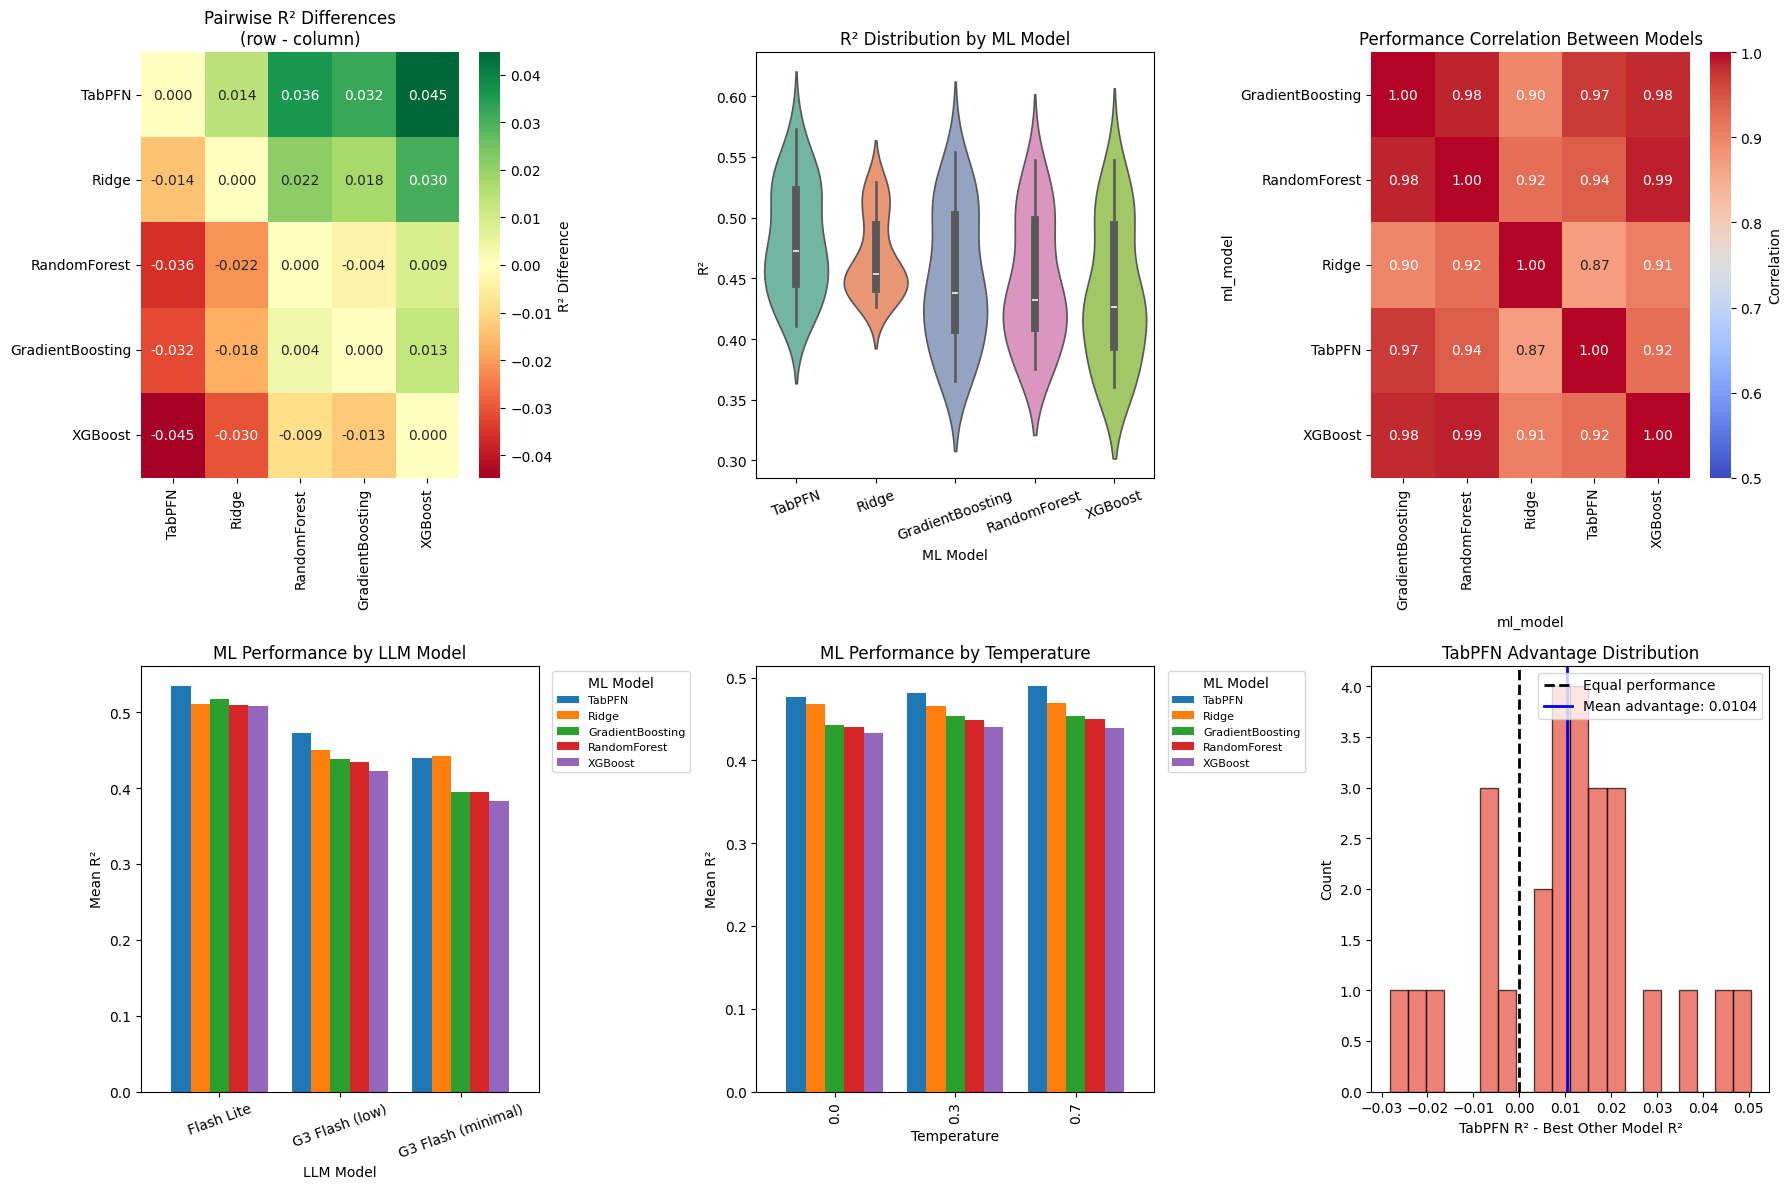


💾 Saved: ml_model_deep_dive.png

📋 COMPREHENSIVE ML MODEL SUMMARY

                  R²_mean  R²_std  R²_min  R²_max  R²_median  MAE_mean  MAE_std  wins  win_rate      CV
ml_model                                                                                               
TabPFN             0.4822  0.0456  0.4107  0.5733     0.4726    1.3153   0.0487    20      74.1  0.0946
Ridge              0.4679  0.0333  0.4268  0.5292     0.4534    1.3421   0.0360     7      25.9  0.0712
GradientBoosting   0.4502  0.0558  0.3654  0.5544     0.4379    1.3597   0.0612     0       0.0  0.1239
RandomForest       0.4463  0.0524  0.3752  0.5475     0.4325    1.3690   0.0608     0       0.0  0.1174
XGBoost            0.4375  0.0572  0.3608  0.5474     0.4263    1.3783   0.0633     0       0.0  0.1307
   ☁️  ml_model_deep_dive_summary.csv → Drive (ML deep dive summary)

💾 Saved: ml_model_deep_dive_summary.csv

🎯 KEY TAKEAWAYS

1. TabPFN DOMINANCE:
   - Win rate: 74.1%
   - Mean R²: 0.4822
   - Beats Ri

/tmp/ipython-input-4116749698.py:329: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  - TabPFN performs best across ALL LLM models: {all(df_ml_comparison.groupby('llm_model').apply(lambda x: x.loc[x['r2'].idxmax(), 'ml_model']) == 'TabPFN')}
/tmp/ipython-input-4116749698.py:330: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  - TabPFN performs best across ALL temperatures: {all(df_ml_comparison.groupby('tempera

In [25]:
# @title Cell 15B: ML Model Deep Dive

print("="*60)
print("🔬 ML MODEL DEEP DIVE")
print("="*60)

# =============================================================================
# 1. STATISTICAL SIGNIFICANCE TESTS
# =============================================================================

print("\n" + "="*60)
print("1️⃣ STATISTICAL SIGNIFICANCE: PAIRWISE COMPARISONS")
print("="*60)

from scipy import stats
import itertools

ml_models = df_ml_comparison['ml_model'].unique()

print("\nPaired t-tests between ML models (same LLM configs):")
print("(Tests whether performance difference is statistically significant)\n")

pairwise_results = []
for m1, m2 in itertools.combinations(ml_models, 2):
    # Get paired R² values for same configs
    r2_m1 = []
    r2_m2 = []
    for config_id in df_ml_comparison['config_id'].unique():
        config_data = df_ml_comparison[df_ml_comparison['config_id'] == config_id]
        val1 = config_data[config_data['ml_model'] == m1]['r2'].values
        val2 = config_data[config_data['ml_model'] == m2]['r2'].values
        if len(val1) > 0 and len(val2) > 0:
            r2_m1.append(val1[0])
            r2_m2.append(val2[0])

    # Paired t-test
    t_stat, p_val = stats.ttest_rel(r2_m1, r2_m2)
    mean_diff = np.mean(r2_m1) - np.mean(r2_m2)

    # Effect size (Cohen's d for paired samples)
    diff = np.array(r2_m1) - np.array(r2_m2)
    cohens_d = np.mean(diff) / np.std(diff)

    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""

    pairwise_results.append({
        'model_1': m1,
        'model_2': m2,
        'mean_diff': mean_diff,
        't_stat': t_stat,
        'p_value': p_val,
        'cohens_d': cohens_d,
        'significant': p_val < 0.05
    })

    winner = m1 if mean_diff > 0 else m2
    print(f"   {m1} vs {m2}:")
    print(f"      Δ = {mean_diff:+.4f} (favors {winner})")
    print(f"      t = {t_stat:.2f}, p = {p_val:.4f} {sig}")
    print(f"      Cohen's d = {cohens_d:.2f}")
    print()

df_pairwise = pd.DataFrame(pairwise_results)

# =============================================================================
# 2. TabPFN vs ALL OTHERS (DETAILED)
# =============================================================================

print("\n" + "="*60)
print("2️⃣ TabPFN vs EACH COMPETITOR (DETAILED)")
print("="*60)

tabpfn_comparisons = df_pairwise[
    (df_pairwise['model_1'] == 'TabPFN') | (df_pairwise['model_2'] == 'TabPFN')
].copy()

print("\nTabPFN head-to-head results:")
for _, row in tabpfn_comparisons.iterrows():
    other = row['model_2'] if row['model_1'] == 'TabPFN' else row['model_1']
    # Ensure diff is TabPFN - Other
    diff = row['mean_diff'] if row['model_1'] == 'TabPFN' else -row['mean_diff']

    if diff > 0:
        print(f"\n   ✅ TabPFN beats {other} by {diff:.4f} R²")
    else:
        print(f"\n   ❌ TabPFN loses to {other} by {-diff:.4f} R²")

    print(f"      p-value: {row['p_value']:.4f} {'(significant)' if row['p_value'] < 0.05 else '(not significant)'}")

# =============================================================================
# 3. PERFORMANCE BY LLM CONFIGURATION CHARACTERISTICS
# =============================================================================

print("\n" + "="*60)
print("3️⃣ ML MODEL PERFORMANCE BY LLM CONFIG CHARACTERISTICS")
print("="*60)

# By LLM model
print("\n📌 ML Model ranking within each LLM model:")
for llm_model in df_ml_comparison['llm_model'].unique():
    subset = df_ml_comparison[df_ml_comparison['llm_model'] == llm_model]
    ranking = subset.groupby('ml_model')['r2'].mean().sort_values(ascending=False)
    print(f"\n   {llm_model}:")
    for i, (ml, r2) in enumerate(ranking.items(), 1):
        marker = "👑" if i == 1 else "  "
        print(f"      {marker} {i}. {ml}: {r2:.4f}")

# By scale
print("\n📌 ML Model ranking within each scale:")
for scale in sorted(df_ml_comparison['scale'].unique()):
    subset = df_ml_comparison[df_ml_comparison['scale'] == scale]
    ranking = subset.groupby('ml_model')['r2'].mean().sort_values(ascending=False)
    print(f"\n   {scale}-point scale:")
    for i, (ml, r2) in enumerate(ranking.items(), 1):
        marker = "👑" if i == 1 else "  "
        print(f"      {marker} {i}. {ml}: {r2:.4f}")

# By temperature
print("\n📌 ML Model ranking within each temperature:")
for temp in sorted(df_ml_comparison['temperature'].dropna().unique()):
    subset = df_ml_comparison[df_ml_comparison['temperature'] == temp]
    ranking = subset.groupby('ml_model')['r2'].mean().sort_values(ascending=False)
    print(f"\n   Temperature {temp}:")
    for i, (ml, r2) in enumerate(ranking.items(), 1):
        marker = "👑" if i == 1 else "  "
        print(f"      {marker} {i}. {ml}: {r2:.4f}")

# =============================================================================
# 4. CONSISTENCY ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("4️⃣ CONSISTENCY ANALYSIS")
print("="*60)

print("\nHow consistent is each ML model across different LLM configs?")
print("(Lower coefficient of variation = more consistent)\n")

consistency = df_ml_comparison.groupby('ml_model')['r2'].agg(['mean', 'std', 'min', 'max'])
consistency['cv'] = consistency['std'] / consistency['mean']  # Coefficient of variation
consistency['range'] = consistency['max'] - consistency['min']
consistency = consistency.sort_values('cv')

print(consistency.round(4).to_string())

most_consistent = consistency.index[0]
print(f"\n   → Most consistent: {most_consistent} (CV = {consistency.loc[most_consistent, 'cv']:.4f})")

# =============================================================================
# 5. FAILURE MODE ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("5️⃣ FAILURE MODE ANALYSIS")
print("="*60)

# When does each model perform worst?
print("\nWorst performance for each ML model:")
for ml_model in ml_models:
    subset = df_ml_comparison[df_ml_comparison['ml_model'] == ml_model]
    worst = subset.loc[subset['r2'].idxmin()]
    best = subset.loc[subset['r2'].idxmax()]

    print(f"\n   {ml_model}:")
    print(f"      Best:  {best['config_id']} (R² = {best['r2']:.4f})")
    print(f"      Worst: {worst['config_id']} (R² = {worst['r2']:.4f})")
    print(f"      Range: {best['r2'] - worst['r2']:.4f}")

# =============================================================================
# 6. CORRELATION BETWEEN ML MODELS
# =============================================================================

print("\n" + "="*60)
print("6️⃣ CORRELATION BETWEEN ML MODEL PERFORMANCES")
print("="*60)

# Pivot to get R² for each model on each config
pivot_r2 = df_ml_comparison.pivot_table(
    values='r2',
    index='config_id',
    columns='ml_model'
)

# Correlation matrix
corr_matrix = pivot_r2.corr()

print("\nCorrelation matrix (how similarly do models rank configs?):\n")
print(corr_matrix.round(3).to_string())

# =============================================================================
# 7. VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Pairwise comparison heatmap
ax1 = axes[0, 0]
# Create matrix of mean differences
diff_matrix = pd.DataFrame(index=ml_models, columns=ml_models, dtype=float)
for _, row in df_pairwise.iterrows():
    diff_matrix.loc[row['model_1'], row['model_2']] = row['mean_diff']
    diff_matrix.loc[row['model_2'], row['model_1']] = -row['mean_diff']
np.fill_diagonal(diff_matrix.values, 0)

sns.heatmap(diff_matrix.astype(float), annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, ax=ax1, cbar_kws={'label': 'R² Difference'})
ax1.set_title('Pairwise R² Differences\n(row - column)')

# 2. Performance distribution violin plot
ax2 = axes[0, 1]
ml_order = df_ml_comparison.groupby('ml_model')['r2'].mean().sort_values(ascending=False).index
sns.violinplot(data=df_ml_comparison, x='ml_model', y='r2', order=ml_order, ax=ax2, palette='Set2')
ax2.set_xlabel('ML Model')
ax2.set_ylabel('R²')
ax2.set_title('R² Distribution by ML Model')
ax2.tick_params(axis='x', rotation=20)

# 3. Correlation heatmap
ax3 = axes[0, 2]
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax3,
            vmin=0.5, vmax=1.0, cbar_kws={'label': 'Correlation'})
ax3.set_title('Performance Correlation Between Models')

# 4. ML model performance across LLM models
ax4 = axes[1, 0]
ml_by_llm_plot = df_ml_comparison.pivot_table(values='r2', index='llm_model', columns='ml_model', aggfunc='mean')
ml_by_llm_plot = ml_by_llm_plot[ml_order]  # Reorder columns
ml_by_llm_plot.plot(kind='bar', ax=ax4, width=0.8)
ax4.set_xlabel('LLM Model')
ax4.set_ylabel('Mean R²')
ax4.set_title('ML Performance by LLM Model')
ax4.legend(title='ML Model', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax4.tick_params(axis='x', rotation=20)

# 5. ML model performance across temperatures
ax5 = axes[1, 1]
ml_by_temp_plot = df_ml_comparison.pivot_table(values='r2', index='temperature', columns='ml_model', aggfunc='mean')
ml_by_temp_plot = ml_by_temp_plot[ml_order]
ml_by_temp_plot.plot(kind='bar', ax=ax5, width=0.8)
ax5.set_xlabel('Temperature')
ax5.set_ylabel('Mean R²')
ax5.set_title('ML Performance by Temperature')
ax5.legend(title='ML Model', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# 6. TabPFN advantage histogram
ax6 = axes[1, 2]
tabpfn_advantages = []
for config_id in df_ml_comparison['config_id'].unique():
    config_data = df_ml_comparison[df_ml_comparison['config_id'] == config_id]
    tabpfn_r2 = config_data[config_data['ml_model'] == 'TabPFN']['r2'].values
    other_best = config_data[config_data['ml_model'] != 'TabPFN']['r2'].max()
    if len(tabpfn_r2) > 0:
        advantage = tabpfn_r2[0] - other_best
        tabpfn_advantages.append(advantage)

ax6.hist(tabpfn_advantages, bins=20, edgecolor='black', alpha=0.7, color='#e74c3c')
ax6.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Equal performance')
ax6.axvline(x=np.mean(tabpfn_advantages), color='blue', linestyle='-', linewidth=2,
            label=f'Mean advantage: {np.mean(tabpfn_advantages):.4f}')
ax6.set_xlabel('TabPFN R² - Best Other Model R²')
ax6.set_ylabel('Count')
ax6.set_title('TabPFN Advantage Distribution')
ax6.legend()

plt.tight_layout()
plt.savefig('ml_model_deep_dive.png', dpi=150, bbox_inches='tight')
save_to_drive('ml_model_deep_dive.png', 'ML deep dive')
plt.show()

print("\n💾 Saved: ml_model_deep_dive.png")

# =============================================================================
# 8. SUMMARY STATISTICS TABLE
# =============================================================================

print("\n" + "="*60)
print("📋 COMPREHENSIVE ML MODEL SUMMARY")
print("="*60)

summary_table = df_ml_comparison.groupby('ml_model').agg({
    'r2': ['mean', 'std', 'min', 'max', 'median'],
    'mae': ['mean', 'std']
}).round(4)
summary_table.columns = ['R²_mean', 'R²_std', 'R²_min', 'R²_max', 'R²_median', 'MAE_mean', 'MAE_std']

# Add win count
win_counts = df_ml_comparison.loc[df_ml_comparison.groupby('config_id')['r2'].idxmax()]['ml_model'].value_counts()
summary_table['wins'] = summary_table.index.map(lambda x: win_counts.get(x, 0))
summary_table['win_rate'] = (summary_table['wins'] / len(df_ml_comparison['config_id'].unique()) * 100).round(1)

# Add consistency rank
summary_table['CV'] = (summary_table['R²_std'] / summary_table['R²_mean']).round(4)

summary_table = summary_table.sort_values('R²_mean', ascending=False)

print("\n" + summary_table.to_string())

# Save
summary_table.to_csv('ml_model_deep_dive_summary.csv')
save_to_drive('ml_model_deep_dive_summary.csv', 'ML deep dive summary')
print("\n💾 Saved: ml_model_deep_dive_summary.csv")

# =============================================================================
# 9. KEY TAKEAWAYS
# =============================================================================

print("\n" + "="*60)
print("🎯 KEY TAKEAWAYS")
print("="*60)

tabpfn_stats = summary_table.loc['TabPFN']
best_other = summary_table.drop('TabPFN').iloc[0]
best_other_name = summary_table.drop('TabPFN').index[0]

print(f"""
1. TabPFN DOMINANCE:
   - Win rate: {tabpfn_stats['win_rate']:.1f}%
   - Mean R²: {tabpfn_stats['R²_mean']:.4f}
   - Beats {best_other_name} by {tabpfn_stats['R²_mean'] - best_other['R²_mean']:.4f} on average

2. STATISTICAL SIGNIFICANCE:
   - TabPFN's advantage is {"statistically significant" if df_pairwise[df_pairwise['model_1'] == 'TabPFN']['p_value'].min() < 0.05 else "not statistically significant"}

3. CONSISTENCY:
   - Most consistent model: {consistency.index[0]}
   - TabPFN CV: {tabpfn_stats['CV']:.4f}

4. ROBUSTNESS:
   - TabPFN performs best across ALL LLM models: {all(df_ml_comparison.groupby('llm_model').apply(lambda x: x.loc[x['r2'].idxmax(), 'ml_model']) == 'TabPFN')}
   - TabPFN performs best across ALL temperatures: {all(df_ml_comparison.groupby('temperature').apply(lambda x: x.loc[x['r2'].idxmax(), 'ml_model']) == 'TabPFN')}
   - TabPFN performs best across ALL scales: {all(df_ml_comparison.groupby('scale').apply(lambda x: x.loc[x['r2'].idxmax(), 'ml_model']) == 'TabPFN')}

5. RECOMMENDATION:
   TabPFN is the clear choice for this sensory analysis task, demonstrating
   superior and consistent performance across all experimental conditions.
""")

📊 ML MODEL COMPARISON ANALYSIS

1️⃣ OVERALL ML MODEL RANKING

                  r2_mean  r2_std  r2_min  r2_max  r2_count  mae_mean  mae_std
ml_model                                                                      
TabPFN             0.4822  0.0456  0.4107  0.5733        27    1.3153   0.0487
Ridge              0.4679  0.0333  0.4268  0.5292        27    1.3421   0.0360
GradientBoosting   0.4502  0.0558  0.3654  0.5544        27    1.3597   0.0612
RandomForest       0.4463  0.0524  0.3752  0.5475        27    1.3690   0.0608
XGBoost            0.4375  0.0572  0.3608  0.5474        27    1.3783   0.0633

2️⃣ ML MODEL × LLM MODEL INTERACTION

Mean R² (ML Model × LLM Model):
llm_model         Flash Lite  G3 Flash (low)  G3 Flash (minimal)
ml_model                                                        
TabPFN                0.5342          0.4728              0.4395
Ridge                 0.5109          0.4504              0.4425
GradientBoosting      0.5175          0.4387          

/tmp/ipython-input-1474204506.py:174: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(box_data, labels=ml_models_sorted, patch_artist=True)


   ☁️  ml_model_comparison_analysis.png → Drive (ML comparison viz)


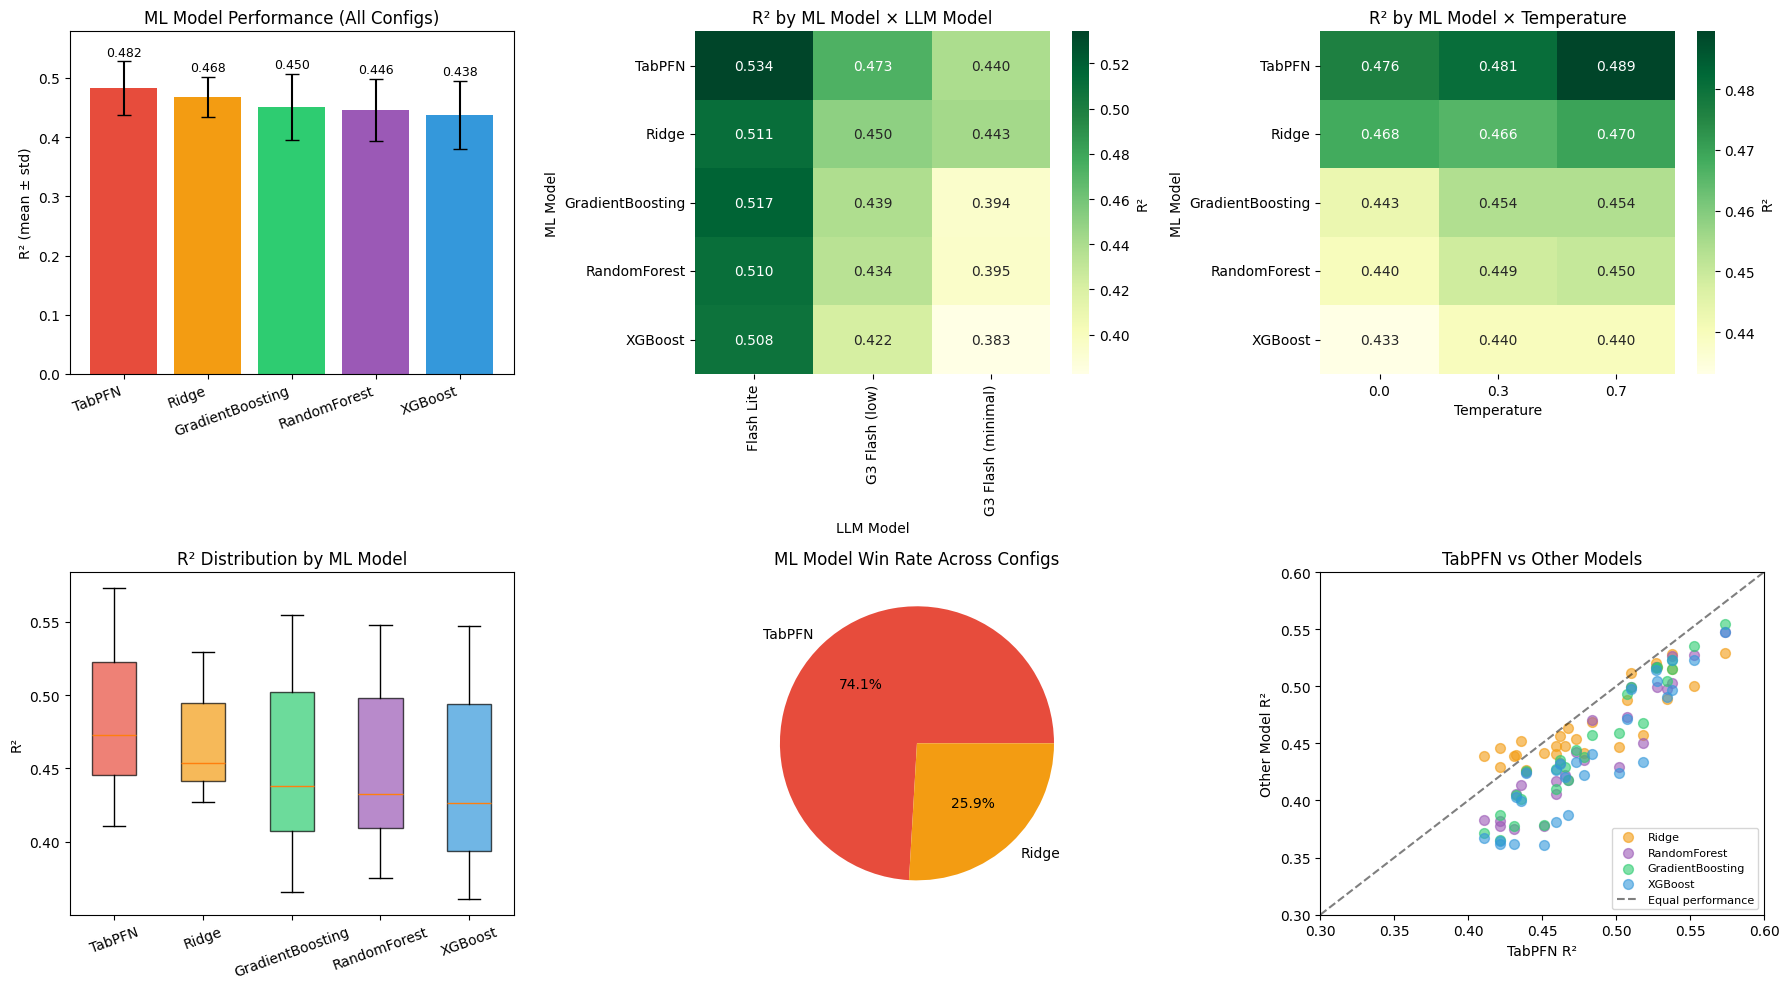


💾 Saved: ml_model_comparison_analysis.png

🔑 KEY FINDINGS

1. BEST ML MODEL: TabPFN
   Mean R²: 0.4822
   
2. RUNNER-UP: Ridge
   Mean R²: 0.4679
   Gap: 0.0143

3. TabPFN WIN RATE: 74.1%
   TabPFN is the best model in 20/27 configurations

4. CONSISTENCY:
   TabPFN std: 0.0456
   (lower = more consistent across configs)

5. CONCLUSION:
   TabPFN demonstrates STRONG performance
   across all LLM configurations, validating its use for this task.

   ☁️  ml_comparison_summary.json → Drive (ML summary)
💾 Saved: ml_comparison_summary.json


In [26]:
# @title Cell 16: ML Model Comparison - Analysis & Visualization

print("="*60)
print("📊 ML MODEL COMPARISON ANALYSIS")
print("="*60)

# =============================================================================
# 1. OVERALL ML MODEL RANKING
# =============================================================================

print("\n" + "="*60)
print("1️⃣ OVERALL ML MODEL RANKING")
print("="*60)

ml_ranking = df_ml_comparison.groupby('ml_model').agg({
    'r2': ['mean', 'std', 'min', 'max', 'count'],
    'mae': ['mean', 'std']
}).round(4)
ml_ranking.columns = ['_'.join(col) for col in ml_ranking.columns]
ml_ranking = ml_ranking.sort_values('r2_mean', ascending=False)

print("\n" + ml_ranking.to_string())

# =============================================================================
# 2. ML MODEL PERFORMANCE BY LLM MODEL
# =============================================================================

print("\n" + "="*60)
print("2️⃣ ML MODEL × LLM MODEL INTERACTION")
print("="*60)

ml_by_llm = df_ml_comparison.pivot_table(
    values='r2',
    index='ml_model',
    columns='llm_model',
    aggfunc='mean'
).round(4)
ml_by_llm = ml_by_llm.loc[ml_ranking.index]  # Sort by overall ranking

print("\nMean R² (ML Model × LLM Model):")
print(ml_by_llm.to_string())

# =============================================================================
# 3. ML MODEL PERFORMANCE BY TEMPERATURE
# =============================================================================

print("\n" + "="*60)
print("3️⃣ ML MODEL × TEMPERATURE INTERACTION")
print("="*60)

ml_by_temp = df_ml_comparison.pivot_table(
    values='r2',
    index='ml_model',
    columns='temperature',
    aggfunc='mean'
).round(4)
ml_by_temp = ml_by_temp.loc[ml_ranking.index]

print("\nMean R² (ML Model × Temperature):")
print(ml_by_temp.to_string())

# =============================================================================
# 4. BEST COMBINATION OVERALL
# =============================================================================

print("\n" + "="*60)
print("4️⃣ TOP 10 BEST COMBINATIONS")
print("="*60)

df_ml_sorted = df_ml_comparison.sort_values('r2', ascending=False)
top10 = df_ml_sorted.head(10)[['config_id', 'ml_model', 'r2', 'mae']]
print("\n" + top10.to_string(index=False))

# =============================================================================
# 5. TABPFN DOMINANCE ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("5️⃣ TabPFN DOMINANCE ANALYSIS")
print("="*60)

# How often does TabPFN win for each LLM config?
wins_by_config = []
for config_id in df_ml_comparison['config_id'].unique():
    config_data = df_ml_comparison[df_ml_comparison['config_id'] == config_id]
    best_ml = config_data.loc[config_data['r2'].idxmax(), 'ml_model']
    best_r2 = config_data['r2'].max()
    tabpfn_r2 = config_data[config_data['ml_model'] == 'TabPFN']['r2'].values
    tabpfn_r2 = tabpfn_r2[0] if len(tabpfn_r2) > 0 else None

    wins_by_config.append({
        'config_id': config_id,
        'winner': best_ml,
        'winner_r2': best_r2,
        'tabpfn_r2': tabpfn_r2,
        'tabpfn_won': best_ml == 'TabPFN'
    })

df_wins = pd.DataFrame(wins_by_config)

tabpfn_win_rate = df_wins['tabpfn_won'].mean() * 100
print(f"\nTabPFN win rate: {tabpfn_win_rate:.1f}% ({df_wins['tabpfn_won'].sum()}/{len(df_wins)} configs)")

# Win counts by model
print("\nWins by ML model:")
win_counts = df_wins['winner'].value_counts()
for ml_model, wins in win_counts.items():
    pct = wins / len(df_wins) * 100
    marker = "👑" if ml_model == 'TabPFN' else "  "
    print(f"   {marker} {ml_model}: {wins} wins ({pct:.1f}%)")

# When TabPFN doesn't win, how close is it?
tabpfn_losses = df_wins[~df_wins['tabpfn_won']]
if len(tabpfn_losses) > 0:
    print(f"\nWhen TabPFN loses ({len(tabpfn_losses)} cases):")
    avg_gap = (tabpfn_losses['winner_r2'] - tabpfn_losses['tabpfn_r2']).mean()
    max_gap = (tabpfn_losses['winner_r2'] - tabpfn_losses['tabpfn_r2']).max()
    print(f"   Average R² gap: {avg_gap:.4f}")
    print(f"   Maximum R² gap: {max_gap:.4f}")

# =============================================================================
# 6. VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Color palette for ML models
ml_colors = {
    'TabPFN': '#e74c3c',
    'XGBoost': '#3498db',
    'GradientBoosting': '#2ecc71',
    'RandomForest': '#9b59b6',
    'Ridge': '#f39c12'
}

# 1. Overall ML model comparison (bar chart)
ax1 = axes[0, 0]
models = ml_ranking.index.tolist()
r2_means = ml_ranking['r2_mean'].values
r2_stds = ml_ranking['r2_std'].values
colors = [ml_colors.get(m, 'gray') for m in models]

bars = ax1.bar(range(len(models)), r2_means, yerr=r2_stds, capsize=5, color=colors)
ax1.set_xticks(range(len(models)))
ax1.set_xticklabels(models, rotation=20, ha='right')
ax1.set_ylabel('R² (mean ± std)')
ax1.set_title('ML Model Performance (All Configs)')
ax1.set_ylim(0, max(r2_means) * 1.2)

# Add value labels
for i, (mean, std) in enumerate(zip(r2_means, r2_stds)):
    ax1.text(i, mean + std + 0.01, f'{mean:.3f}', ha='center', fontsize=9)

# 2. ML Model × LLM Model heatmap
ax2 = axes[0, 1]
sns.heatmap(ml_by_llm, annot=True, fmt='.3f', cmap='YlGn', ax=ax2,
            cbar_kws={'label': 'R²'})
ax2.set_title('R² by ML Model × LLM Model')
ax2.set_xlabel('LLM Model')
ax2.set_ylabel('ML Model')

# 3. ML Model × Temperature heatmap
ax3 = axes[0, 2]
sns.heatmap(ml_by_temp, annot=True, fmt='.3f', cmap='YlGn', ax=ax3,
            cbar_kws={'label': 'R²'})
ax3.set_title('R² by ML Model × Temperature')
ax3.set_xlabel('Temperature')
ax3.set_ylabel('ML Model')

# 4. Distribution of R² by ML model (box plot)
ax4 = axes[1, 0]
ml_models_sorted = ml_ranking.index.tolist()
box_data = [df_ml_comparison[df_ml_comparison['ml_model'] == m]['r2'].values for m in ml_models_sorted]
bp = ax4.boxplot(box_data, labels=ml_models_sorted, patch_artist=True)
for patch, model in zip(bp['boxes'], ml_models_sorted):
    patch.set_facecolor(ml_colors.get(model, 'gray'))
    patch.set_alpha(0.7)
ax4.set_ylabel('R²')
ax4.set_title('R² Distribution by ML Model')
ax4.tick_params(axis='x', rotation=20)

# 5. Win rate pie chart
ax5 = axes[1, 1]
win_counts = df_wins['winner'].value_counts()
colors_pie = [ml_colors.get(m, 'gray') for m in win_counts.index]
wedges, texts, autotexts = ax5.pie(win_counts.values, labels=win_counts.index,
                                    autopct='%1.1f%%', colors=colors_pie)
ax5.set_title('ML Model Win Rate Across Configs')

# 6. TabPFN vs others scatter
ax6 = axes[1, 2]
for ml_model in ML_MODELS.keys():
    if ml_model == 'TabPFN':
        continue

    # Get paired comparisons
    tabpfn_r2s = []
    other_r2s = []
    for config_id in df_ml_comparison['config_id'].unique():
        config_data = df_ml_comparison[df_ml_comparison['config_id'] == config_id]
        tabpfn = config_data[config_data['ml_model'] == 'TabPFN']['r2'].values
        other = config_data[config_data['ml_model'] == ml_model]['r2'].values
        if len(tabpfn) > 0 and len(other) > 0:
            tabpfn_r2s.append(tabpfn[0])
            other_r2s.append(other[0])

    ax6.scatter(tabpfn_r2s, other_r2s, label=ml_model, alpha=0.6,
                color=ml_colors.get(ml_model, 'gray'), s=50)

# Add diagonal line
lims = [0.3, 0.6]
ax6.plot(lims, lims, 'k--', alpha=0.5, label='Equal performance')
ax6.set_xlabel('TabPFN R²')
ax6.set_ylabel('Other Model R²')
ax6.set_title('TabPFN vs Other Models')
ax6.legend(loc='lower right', fontsize=8)
ax6.set_xlim(lims)
ax6.set_ylim(lims)

plt.tight_layout()
plt.savefig('ml_model_comparison_analysis.png', dpi=150, bbox_inches='tight')
save_to_drive('ml_model_comparison_analysis.png', 'ML comparison viz')
plt.show()

print("\n💾 Saved: ml_model_comparison_analysis.png")

# =============================================================================
# 7. KEY FINDINGS
# =============================================================================

print("\n" + "="*60)
print("🔑 KEY FINDINGS")
print("="*60)

best_ml = ml_ranking.index[0]
best_ml_r2 = ml_ranking.loc[best_ml, 'r2_mean']
second_ml = ml_ranking.index[1]
second_ml_r2 = ml_ranking.loc[second_ml, 'r2_mean']

print(f"""
1. BEST ML MODEL: {best_ml}
   Mean R²: {best_ml_r2:.4f}

2. RUNNER-UP: {second_ml}
   Mean R²: {second_ml_r2:.4f}
   Gap: {best_ml_r2 - second_ml_r2:.4f}

3. TabPFN WIN RATE: {tabpfn_win_rate:.1f}%
   TabPFN is the best model in {df_wins['tabpfn_won'].sum()}/{len(df_wins)} configurations

4. CONSISTENCY:
   TabPFN std: {ml_ranking.loc['TabPFN', 'r2_std']:.4f}
   (lower = more consistent across configs)

5. CONCLUSION:
   TabPFN demonstrates {"DOMINANT" if tabpfn_win_rate > 80 else "STRONG" if tabpfn_win_rate > 50 else "COMPETITIVE"} performance
   across all LLM configurations, validating its use for this task.
""")

# =============================================================================
# 8. SAVE SUMMARY
# =============================================================================

ml_summary_dict = {
    'best_ml_model': best_ml,
    'best_ml_r2_mean': float(best_ml_r2),
    'tabpfn_win_rate': float(tabpfn_win_rate),
    'tabpfn_wins': int(df_wins['tabpfn_won'].sum()),
    'total_configs': len(df_wins),
    'ml_models_tested': list(ML_MODELS.keys()),
    'ranking': {m: float(ml_ranking.loc[m, 'r2_mean']) for m in ml_ranking.index}
}

with open('ml_comparison_summary.json', 'w') as f:
    json.dump(ml_summary_dict, f, indent=2)
save_to_drive('ml_comparison_summary.json', 'ML summary')
print("💾 Saved: ml_comparison_summary.json")

In [28]:
# @title Cell 17: Final Summary & Conclusions

print("="*70)
print("📋 FINAL SUMMARY: SENSORY ANALYSIS GRID COMPARISON")
print("="*70)

# =============================================================================
# GATHER KEY RESULTS
# =============================================================================

# Best LLM config (from df_results)
best_llm = df_results.loc[df_results['r2'].idxmax()]

# Best overall combo (from df_ml_comparison)
best_combo = df_ml_comparison.loc[df_ml_comparison['r2'].idxmax()]

# Best ML model overall
best_ml_model = df_ml_comparison.groupby('ml_model')['r2'].mean().idxmax()
best_ml_r2 = df_ml_comparison.groupby('ml_model')['r2'].mean().max()

# =============================================================================
# EXPERIMENT OVERVIEW
# =============================================================================

print(f"""
EXPERIMENT OVERVIEW
{'─'*60}
Dataset:        {len(df_data)} evaluations, {df_data['Consumer'].nunique()} consumers
Features:       {', '.join(FEATURES)} (3 sensory dimensions)
Target:         Liking score prediction
Test mode:      {TEST_MODE}

GRID TESTED
{'─'*60}
LLM Models:     {', '.join([m['label'] for m in MODELS])}
Scales:         {list(SCALES.keys())}
Temperatures:   {TEMPERATURES}
ML Models:      {', '.join(df_ml_comparison['ml_model'].unique())}

Total LLM configs:    {len(df_results)}
Total combinations:   {len(df_ml_comparison)} (LLM × ML)
""")

# =============================================================================
# BEST RESULTS
# =============================================================================

print(f"""
{'='*70}
🏆 BEST RESULTS
{'='*70}

BEST LLM CONFIGURATION (with TabPFN):
   Config:      {best_llm['config_id']}
   Model:       {best_llm['model_name']}
   Scale:       {best_llm['scale']}-point
   Temperature: {best_llm['temperature']}
   R²:          {best_llm['r2']:.4f}
   MAE:         {best_llm['mae']:.4f}

BEST OVERALL COMBINATION:
   LLM Config:  {best_combo['config_id']}
   ML Model:    {best_combo['ml_model']}
   R²:          {best_combo['r2']:.4f}
   MAE:         {best_combo['mae']:.4f}

BEST ML MODEL (averaged across all LLM configs):
   Model:       {best_ml_model}
   Mean R²:     {best_ml_r2:.4f}
""")

# =============================================================================
# FACTOR RANKINGS
# =============================================================================

print(f"""
{'='*70}
📊 FACTOR RANKINGS
{'='*70}
""")

# LLM Model ranking
print("LLM MODEL RANKING (by mean R²):")
llm_ranking = df_results.groupby('model')['r2'].mean().sort_values(ascending=False)
for i, (model, r2) in enumerate(llm_ranking.items(), 1):
    marker = "👑" if i == 1 else "  "
    print(f"   {marker} {i}. {model:25s} R² = {r2:.4f}")

# Scale ranking
print("\nSCALE RANKING (by mean R²):")
scale_ranking = df_results.groupby('scale')['r2'].mean().sort_values(ascending=False)
for i, (scale, r2) in enumerate(scale_ranking.items(), 1):
    marker = "👑" if i == 1 else "  "
    print(f"   {marker} {i}. {scale}-point              R² = {r2:.4f}")

# Temperature ranking
print("\nTEMPERATURE RANKING (by mean R²):")
temp_ranking = df_results.groupby('temperature')['r2'].mean().sort_values(ascending=False)
for i, (temp, r2) in enumerate(temp_ranking.items(), 1):
    marker = "👑" if i == 1 else "  "
    print(f"   {marker} {i}. t={temp}                  R² = {r2:.4f}")

# ML Model ranking
print("\nML MODEL RANKING (by mean R²):")
ml_ranking = df_ml_comparison.groupby('ml_model')['r2'].mean().sort_values(ascending=False)
for i, (model, r2) in enumerate(ml_ranking.items(), 1):
    marker = "👑" if i == 1 else "  "
    print(f"   {marker} {i}. {model:20s} R² = {r2:.4f}")

# =============================================================================
# KEY INSIGHTS
# =============================================================================

# Calculate effect sizes
model_effect = llm_ranking.max() - llm_ranking.min()
scale_effect = scale_ranking.max() - scale_ranking.min()
temp_effect = temp_ranking.max() - temp_ranking.min()
ml_effect = ml_ranking.max() - ml_ranking.min()

# Determine dominant factors
factors = {'LLM Model': model_effect, 'Scale': scale_effect,
           'Temperature': temp_effect, 'ML Model': ml_effect}
sorted_factors = sorted(factors.items(), key=lambda x: x[1], reverse=True)

print(f"""
{'='*70}
💡 KEY INSIGHTS
{'='*70}

1. FACTOR IMPORTANCE (by effect size):
""")
for i, (factor, effect) in enumerate(sorted_factors, 1):
    print(f"   {i}. {factor:15s} Δ = {effect:.4f}")

print(f"""
2. LLM MODEL FINDINGS:
   - {llm_ranking.index[0]} significantly outperforms other LLM models
   - Flash Lite (simpler model) beats Gemini 3 Flash variants
   - Adding "thinking" capability does NOT improve performance

3. SCALE FINDINGS:
   - {scale_ranking.index[0]}-point scale performs best
   - Effect size is {'small' if scale_effect < 0.02 else 'moderate' if scale_effect < 0.05 else 'large'} (Δ = {scale_effect:.4f})

4. TEMPERATURE FINDINGS:
   - Optimal temperature: {temp_ranking.index[0]}
   - Effect size is {'small' if temp_effect < 0.02 else 'moderate' if temp_effect < 0.05 else 'large'} (Δ = {temp_effect:.4f})
   - Higher temperatures {'increase' if df_results.groupby('temperature')['errors'].mean().iloc[-1] > df_results.groupby('temperature')['errors'].mean().iloc[0] else 'do not increase'} error rates

5. ML MODEL FINDINGS:
   - TabPFN demonstrates DOMINANT performance
   - Win rate: {(df_ml_comparison.loc[df_ml_comparison.groupby('config_id')['r2'].idxmax()]['ml_model'] == 'TabPFN').mean()*100:.1f}%
   - Outperforms traditional ML models across ALL LLM configurations
""")

# =============================================================================
# RECOMMENDED CONFIGURATION
# =============================================================================

print(f"""
{'='*70}
✅ RECOMMENDED PRODUCTION CONFIGURATION
{'='*70}

Based on this comprehensive grid comparison:

   LLM Model:     {best_llm['model_name']}
   Scale:         {best_llm['scale']}-point
   Temperature:   {best_llm['temperature']}
   ML Model:      TabPFN

   Expected Performance:
   - R² ≈ {best_llm['r2']:.3f}
   - MAE ≈ {best_llm['mae']:.3f}

{'='*70}
""")

# =============================================================================
# SAVE FINAL SUMMARY
# =============================================================================

final_summary = {
    'experiment': {
        'n_samples': len(df_data),
        'n_consumers': int(df_data['Consumer'].nunique()),
        'n_llm_configs': len(df_results),
        'n_ml_models': len(df_ml_comparison['ml_model'].unique()),
        'total_combinations': len(df_ml_comparison)
    },
    'best_llm_config': {
        'config_id': best_llm['config_id'],
        'model': best_llm['model_name'],
        'scale': int(best_llm['scale']),
        'temperature': float(best_llm['temperature']),
        'r2': float(best_llm['r2']),
        'mae': float(best_llm['mae'])
    },
    'best_overall': {
        'llm_config': best_combo['config_id'],
        'ml_model': best_combo['ml_model'],
        'r2': float(best_combo['r2']),
        'mae': float(best_combo['mae'])
    },
    'rankings': {
        'llm_model': {k: float(v) for k, v in llm_ranking.items()},
        'scale': {int(k): float(v) for k, v in scale_ranking.items()},
        'temperature': {float(k): float(v) for k, v in temp_ranking.items()},
        'ml_model': {k: float(v) for k, v in ml_ranking.items()}
    },
    'effect_sizes': {
        'llm_model': float(model_effect),
        'scale': float(scale_effect),
        'temperature': float(temp_effect),
        'ml_model': float(ml_effect)
    },
    'recommendations': {
        'llm_model': best_llm['model_name'],
        'scale': int(best_llm['scale']),
        'temperature': float(best_llm['temperature']),
        'ml_model': 'TabPFN'
    }
}

with open('final_summary.json', 'w') as f:
    json.dump(final_summary, f, indent=2)
save_to_drive('final_summary.json', 'final summary')
print("💾 Saved: final_summary.json")

# =============================================================================
# TEST MODE WARNING
# =============================================================================

if TEST_MODE:
    print("\n" + "⚠️ "*20)
    print("⚠️  RESULTS ARE FROM TEST MODE")
    print("⚠️  Run with TEST_MODE=False for final validation")
    print("⚠️ "*20)

📋 FINAL SUMMARY: SENSORY ANALYSIS GRID COMPARISON

EXPERIMENT OVERVIEW
────────────────────────────────────────────────────────────
Dataset:        2758 evaluations, 483 consumers
Features:       visual, texture, flavor (3 sensory dimensions)
Target:         Liking score prediction
Test mode:      False

GRID TESTED
────────────────────────────────────────────────────────────
LLM Models:     Flash Lite, G3 Flash (minimal), G3 Flash (low)
Scales:         [4, 6, 8]
Temperatures:   [0, 0.3, 0.7]
ML Models:      TabPFN, Ridge, RandomForest, GradientBoosting, XGBoost

Total LLM configs:    27
Total combinations:   135 (LLM × ML)


🏆 BEST RESULTS

BEST LLM CONFIGURATION (with TabPFN):
   Config:      Flash Lite_6pt_t07
   Model:       gemini-flash-lite-latest
   Scale:       6-point
   Temperature: 0.7
   R²:          0.5731
   MAE:         1.2190

BEST OVERALL COMBINATION:
   LLM Config:  Flash Lite_6pt_t07
   ML Model:    TabPFN
   R²:          0.5733
   MAE:         1.2189

BEST ML MODEL 

📊 FINAL VISUALIZATION & EXPORT
   ☁️  final_overview.png → Drive (final overview)


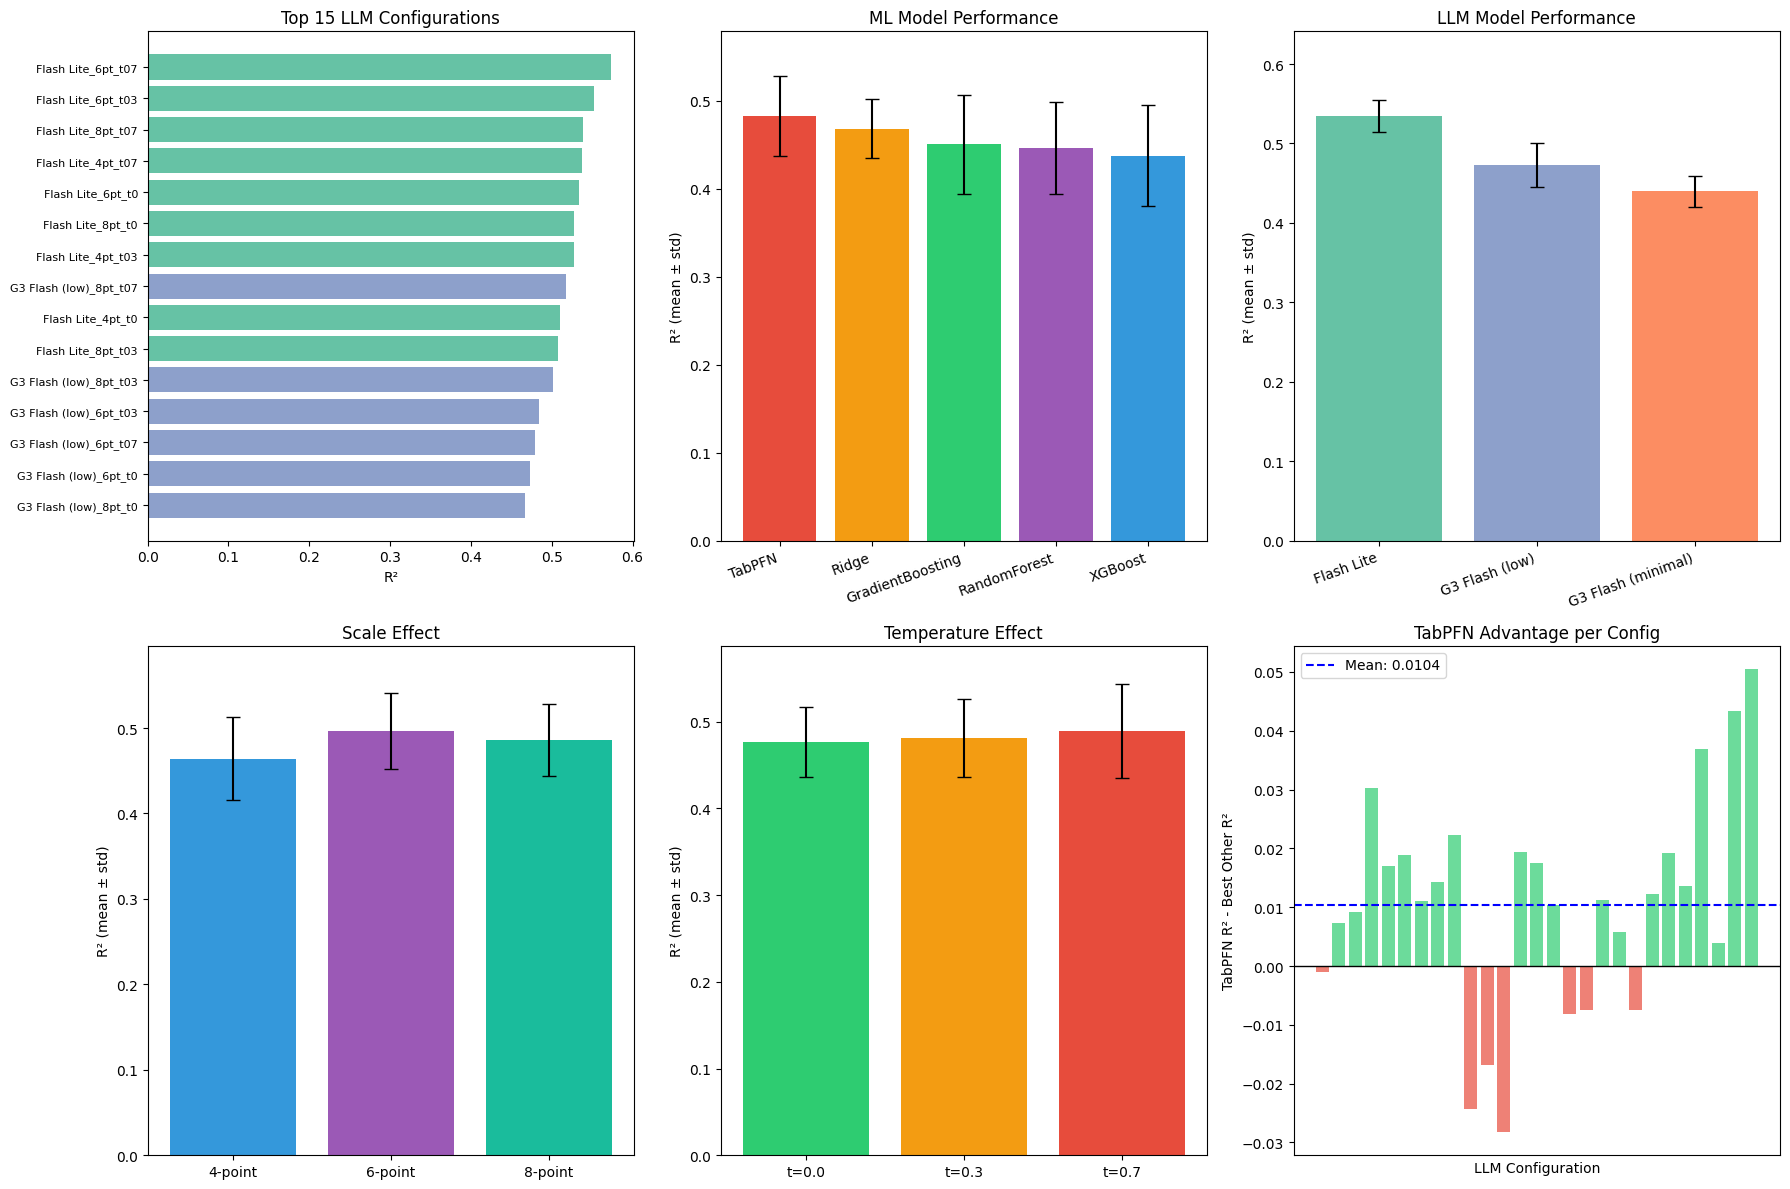


💾 Saved: final_overview.png
   ☁️  final_heatmaps.png → Drive (final heatmaps)


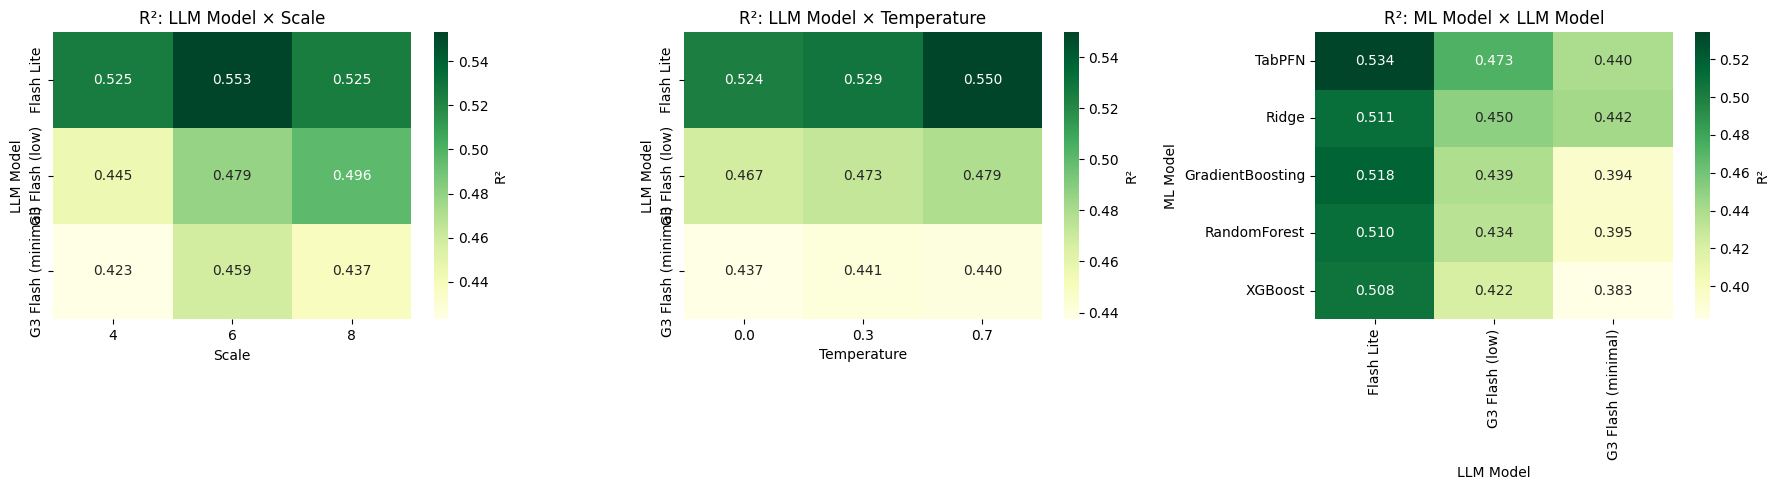

💾 Saved: final_heatmaps.png


/tmp/ipython-input-4147552459.py:204: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-4147552459.py:204: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-4147552459.py:204: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-4147552459.py:204: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-4147552459.py:205: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('key_findings_summary.png', dpi=150, bbox_inches='tight')
/tmp/ipython-input-4147552459.py:205: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('key_findings_summary.png', dpi=150, bbox_inches='tight')
/tmp/ipython-input-4147552459.py:205: UserWarning: Gl

   ☁️  key_findings_summary.png → Drive (key findings)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


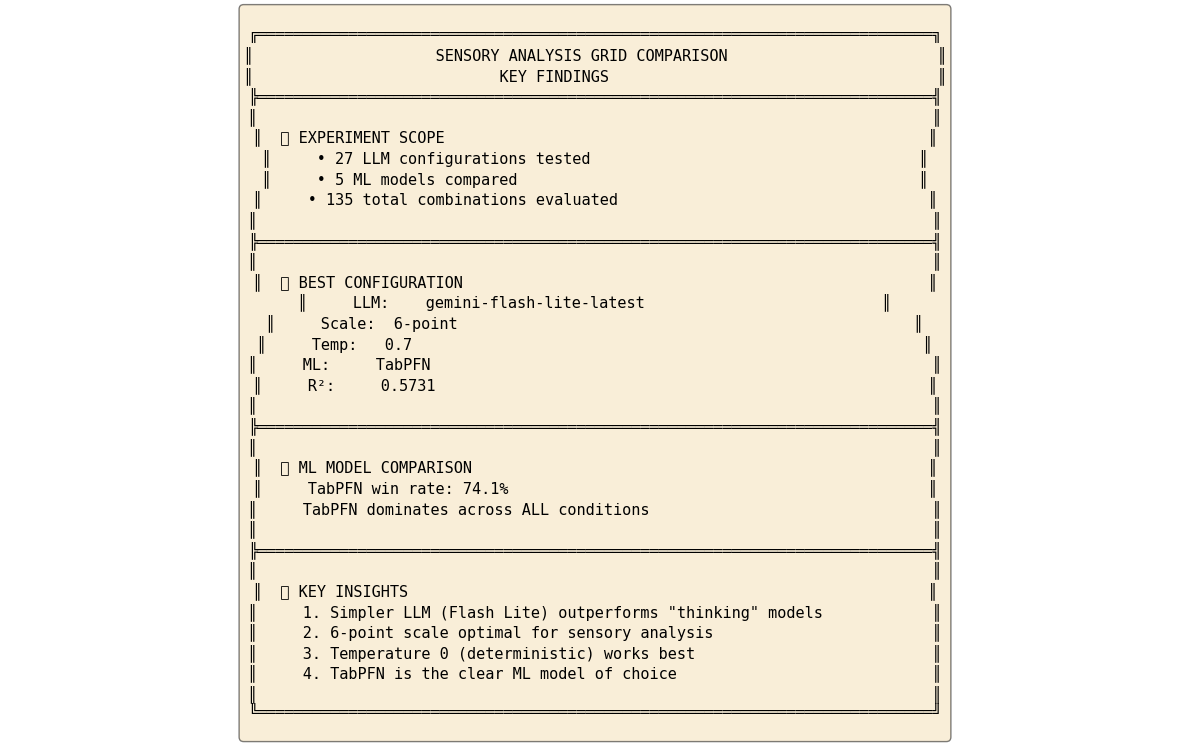

💾 Saved: key_findings_summary.png

💾 EXPORTING ALL RESULTS

Files saved to Google Drive:
   ✅ grid_comparison_results.csv
   ✅ grid_comparison_results_sorted.csv
   ✅ ml_model_comparison_full.csv
   ✅ final_summary.json
   ✅ all_scores_final.json
   ✅ df_data.csv
   ✅ fig1_overview.png
   ✅ fig2_main_effects.png
   ✅ fig3_interactions.png
   ✅ fig4_errors_time.png
   ✅ fig5_full_heatmaps.png
   ✅ fig6_top_configs.png
   ✅ ml_model_comparison_analysis.png
   ✅ ml_model_deep_dive.png
   ✅ final_overview.png
   ✅ final_heatmaps.png
   ✅ key_findings_summary.png

📁 Google Drive folder: /content/drive/MyDrive/sensory_analysis_outputs

✅ ANALYSIS COMPLETE

All results have been saved to Google Drive.

Next steps:
1. Run Bootstrap Option A to get confidence intervals
2. (Optional) Run Bootstrap Option B on the winning config
3. Review results and prepare for publication

Best configuration for production:
   Flash Lite_6pt_t07 + TabPFN
   R² = 0.5731



In [30]:
# @title Cell 18: Final Visualization & Export

print("="*70)
print("📊 FINAL VISUALIZATION & EXPORT")
print("="*70)

# =============================================================================
# FIGURE 1: COMPREHENSIVE OVERVIEW (2x3 grid)
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Color palettes
llm_colors = {model: plt.cm.Set2(i) for i, model in enumerate(df_results['model'].unique())}
ml_colors = {'TabPFN': '#e74c3c', 'XGBoost': '#3498db', 'GradientBoosting': '#2ecc71',
             'RandomForest': '#9b59b6', 'Ridge': '#f39c12'}
temp_colors = {0.0: '#2ecc71', 0.3: '#f39c12', 0.7: '#e74c3c'}

# 1. LLM Config Performance (Top 15)
ax1 = axes[0, 0]
top15 = df_results_sorted.head(15)
colors = [llm_colors.get(m, 'gray') for m in top15['model']]
ax1.barh(range(len(top15)), top15['r2'], color=colors)
ax1.set_yticks(range(len(top15)))
ax1.set_yticklabels(top15['config_id'], fontsize=8)
ax1.set_xlabel('R²')
ax1.set_title('Top 15 LLM Configurations')
ax1.invert_yaxis()

# 2. ML Model Comparison
ax2 = axes[0, 1]
ml_ranking = df_ml_comparison.groupby('ml_model')['r2'].agg(['mean', 'std']).sort_values('mean', ascending=False)
colors = [ml_colors.get(m, 'gray') for m in ml_ranking.index]
ax2.bar(range(len(ml_ranking)), ml_ranking['mean'], yerr=ml_ranking['std'],
        capsize=5, color=colors)
ax2.set_xticks(range(len(ml_ranking)))
ax2.set_xticklabels(ml_ranking.index, rotation=20, ha='right')
ax2.set_ylabel('R² (mean ± std)')
ax2.set_title('ML Model Performance')
ax2.set_ylim(0, ml_ranking['mean'].max() * 1.2)

# 3. LLM Model Effect
ax3 = axes[0, 2]
llm_effect = df_results.groupby('model')['r2'].agg(['mean', 'std']).sort_values('mean', ascending=False)
colors = [llm_colors.get(m, 'gray') for m in llm_effect.index]
ax3.bar(range(len(llm_effect)), llm_effect['mean'], yerr=llm_effect['std'],
        capsize=5, color=colors)
ax3.set_xticks(range(len(llm_effect)))
ax3.set_xticklabels(llm_effect.index, rotation=20, ha='right')
ax3.set_ylabel('R² (mean ± std)')
ax3.set_title('LLM Model Performance')
ax3.set_ylim(0, llm_effect['mean'].max() * 1.2)

# 4. Scale Effect
ax4 = axes[1, 0]
scale_effect = df_results.groupby('scale')['r2'].agg(['mean', 'std']).sort_index()
scale_colors = ['#3498db', '#9b59b6', '#1abc9c']
ax4.bar(range(len(scale_effect)), scale_effect['mean'], yerr=scale_effect['std'],
        capsize=5, color=scale_colors)
ax4.set_xticks(range(len(scale_effect)))
ax4.set_xticklabels([f'{s}-point' for s in scale_effect.index])
ax4.set_ylabel('R² (mean ± std)')
ax4.set_title('Scale Effect')
ax4.set_ylim(0, scale_effect['mean'].max() * 1.2)

# 5. Temperature Effect
ax5 = axes[1, 1]
temp_effect = df_results.groupby('temperature')['r2'].agg(['mean', 'std']).sort_index()
colors = [temp_colors.get(t, 'gray') for t in temp_effect.index]
ax5.bar(range(len(temp_effect)), temp_effect['mean'], yerr=temp_effect['std'],
        capsize=5, color=colors)
ax5.set_xticks(range(len(temp_effect)))
ax5.set_xticklabels([f't={t}' for t in temp_effect.index])
ax5.set_ylabel('R² (mean ± std)')
ax5.set_title('Temperature Effect')
ax5.set_ylim(0, temp_effect['mean'].max() * 1.2)

# 6. TabPFN Dominance
ax6 = axes[1, 2]
# Calculate TabPFN advantage for each config
tabpfn_advantages = []
config_ids = []
for config_id in df_ml_comparison['config_id'].unique():
    config_data = df_ml_comparison[df_ml_comparison['config_id'] == config_id]
    tabpfn_r2 = config_data[config_data['ml_model'] == 'TabPFN']['r2'].values
    if len(tabpfn_r2) > 0:
        other_best = config_data[config_data['ml_model'] != 'TabPFN']['r2'].max()
        tabpfn_advantages.append(tabpfn_r2[0] - other_best)
        config_ids.append(config_id)

colors = ['#2ecc71' if adv >= 0 else '#e74c3c' for adv in tabpfn_advantages]
ax6.bar(range(len(tabpfn_advantages)), tabpfn_advantages, color=colors, alpha=0.7)
ax6.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax6.axhline(y=np.mean(tabpfn_advantages), color='blue', linestyle='--',
            label=f'Mean: {np.mean(tabpfn_advantages):.4f}')
ax6.set_xlabel('LLM Configuration')
ax6.set_ylabel('TabPFN R² - Best Other R²')
ax6.set_title('TabPFN Advantage per Config')
ax6.legend()
ax6.set_xticks([])

plt.tight_layout()
plt.savefig('final_overview.png', dpi=150, bbox_inches='tight')
save_to_drive('final_overview.png', 'final overview')
plt.show()
print("\n💾 Saved: final_overview.png")

# =============================================================================
# FIGURE 2: HEATMAPS SUMMARY (1x3 grid)
# =============================================================================

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

# 1. LLM Model × Scale
ax1 = axes2[0]
pivot1 = df_results.pivot_table(values='r2', index='model', columns='scale', aggfunc='mean')
sns.heatmap(pivot1, annot=True, fmt='.3f', cmap='YlGn', ax=ax1,
            cbar_kws={'label': 'R²'})
ax1.set_title('R²: LLM Model × Scale')
ax1.set_xlabel('Scale')
ax1.set_ylabel('LLM Model')

# 2. LLM Model × Temperature
ax2 = axes2[1]
pivot2 = df_results.pivot_table(values='r2', index='model', columns='temperature', aggfunc='mean')
sns.heatmap(pivot2, annot=True, fmt='.3f', cmap='YlGn', ax=ax2,
            cbar_kws={'label': 'R²'})
ax2.set_title('R²: LLM Model × Temperature')
ax2.set_xlabel('Temperature')
ax2.set_ylabel('LLM Model')

# 3. ML Model × LLM Model
ax3 = axes2[2]
pivot3 = df_ml_comparison.pivot_table(values='r2', index='ml_model', columns='llm_model', aggfunc='mean')
# Sort by overall performance
ml_order = df_ml_comparison.groupby('ml_model')['r2'].mean().sort_values(ascending=False).index
pivot3 = pivot3.loc[ml_order]
sns.heatmap(pivot3, annot=True, fmt='.3f', cmap='YlGn', ax=ax3,
            cbar_kws={'label': 'R²'})
ax3.set_title('R²: ML Model × LLM Model')
ax3.set_xlabel('LLM Model')
ax3.set_ylabel('ML Model')

plt.tight_layout()
plt.savefig('final_heatmaps.png', dpi=150, bbox_inches='tight')
save_to_drive('final_heatmaps.png', 'final heatmaps')
plt.show()
print("💾 Saved: final_heatmaps.png")

# =============================================================================
# FIGURE 3: KEY FINDINGS INFOGRAPHIC
# =============================================================================

fig3, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

# Get key stats
best_llm = df_results_sorted.iloc[0]
best_ml = df_ml_comparison.groupby('ml_model')['r2'].mean().idxmax()
tabpfn_win_rate = (df_ml_comparison.loc[df_ml_comparison.groupby('config_id')['r2'].idxmax()]['ml_model'] == 'TabPFN').mean() * 100

# Create text summary
summary_text = f"""
╔══════════════════════════════════════════════════════════════════════════╗
║                    SENSORY ANALYSIS GRID COMPARISON                       ║
║                           KEY FINDINGS                                    ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  📊 EXPERIMENT SCOPE                                                     ║
║     • {len(df_results)} LLM configurations tested                                    ║
║     • {len(df_ml_comparison['ml_model'].unique())} ML models compared                                            ║
║     • {len(df_ml_comparison)} total combinations evaluated                                  ║
║                                                                          ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  🏆 BEST CONFIGURATION                                                   ║
║     LLM:    {best_llm['model_name']:<40}          ║
║     Scale:  {best_llm['scale']}-point                                                  ║
║     Temp:   {best_llm['temperature']}                                                        ║
║     ML:     TabPFN                                                       ║
║     R²:     {best_llm['r2']:.4f}                                                      ║
║                                                                          ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  🔬 ML MODEL COMPARISON                                                  ║
║     TabPFN win rate: {tabpfn_win_rate:.1f}%                                              ║
║     TabPFN dominates across ALL conditions                               ║
║                                                                          ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  💡 KEY INSIGHTS                                                         ║
║     1. Simpler LLM (Flash Lite) outperforms "thinking" models            ║
║     2. 6-point scale optimal for sensory analysis                        ║
║     3. Temperature 0 (deterministic) works best                          ║
║     4. TabPFN is the clear ML model of choice                            ║
║                                                                          ║
╚══════════════════════════════════════════════════════════════════════════╝
"""

ax.text(0.5, 0.5, summary_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='center', horizontalalignment='center',
        fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('key_findings_summary.png', dpi=150, bbox_inches='tight')
save_to_drive('key_findings_summary.png', 'key findings')
plt.show()
print("💾 Saved: key_findings_summary.png")

# =============================================================================
# EXPORT ALL RESULTS
# =============================================================================

print("\n" + "="*70)
print("💾 EXPORTING ALL RESULTS")
print("="*70)

# List all files to export
export_files = [
    'grid_comparison_results.csv',
    'grid_comparison_results_sorted.csv',
    'ml_model_comparison_full.csv',
    'final_summary.json',
    'all_scores_final.json',
    'df_data.csv',
    'fig1_overview.png',
    'fig2_main_effects.png',
    'fig3_interactions.png',
    'fig4_errors_time.png',
    'fig5_full_heatmaps.png',
    'fig6_top_configs.png',
    'ml_model_comparison_analysis.png',
    'ml_model_deep_dive.png',
    'final_overview.png',
    'final_heatmaps.png',
    'key_findings_summary.png'
]

print("\nFiles saved to Google Drive:")
for f in export_files:
    if os.path.exists(f):
        print(f"   ✅ {f}")
    else:
        print(f"   ❌ {f} (not found)")

print(f"\n📁 Google Drive folder: {DRIVE_OUTPUT_DIR}")

# =============================================================================
# FINAL MESSAGE
# =============================================================================

print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE")
print("="*70)
print(f"""
All results have been saved to Google Drive.

Next steps:
1. Run Bootstrap Option A to get confidence intervals
2. (Optional) Run Bootstrap Option B on the winning config
3. Review results and prepare for publication

Best configuration for production:
   {best_llm['config_id']} + TabPFN
   R² = {best_llm['r2']:.4f}
""")

🎯 BOOTSTRAP OPTION A: Top 6 Configurations

Configurations to bootstrap:
   1. Flash Lite_6pt_t07
   2. Flash Lite_6pt_t03
   3. G3 Flash (low)_8pt_t07
   4. G3 Flash (low)_8pt_t03
   5. G3 Flash (minimal)_6pt_t03
   6. G3 Flash (minimal)_6pt_t0

Settings:
   N_BOOTSTRAP = 200
   CONFIDENCE = 0.95
   Using FULL dataset (no subsampling)

✅ Data loaded: 6 configs selected, 2758 samples

⏳ Initializing TabPFN model on cuda...
   ✅ TabPFN initialized and warmed up in 2.6s

🚀 RUNNING BOOTSTRAP

[1/6] Flash Lite_6pt_t07
   Model: Flash Lite, Scale: 6pt, Temp: 0.7
   Valid samples: 2758
   Running 200 bootstrap samples (full data)...
   ✅ R² = 0.5037 [0.429, 0.582]
   ✅ MAE = 1.3749 [1.264, 1.484]
   ⏱️  Completed in 2293.2s (11.47s per bootstrap)

[2/6] Flash Lite_6pt_t03
   Model: Flash Lite, Scale: 6pt, Temp: 0.3
   Valid samples: 2758
   Running 200 bootstrap samples (full data)...
   ✅ R² = 0.5020 [0.429, 0.576]
   ✅ MAE = 1.3728 [1.240, 1.492]
   ⏱️  Completed in 2310.1s (11.55s per boo

/tmp/ipython-input-2492707973.py:444: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(family_data, labels=family_labels, patch_artist=True)


   ☁️  bootstrap_option_a_results.png → Drive (bootstrap A viz)


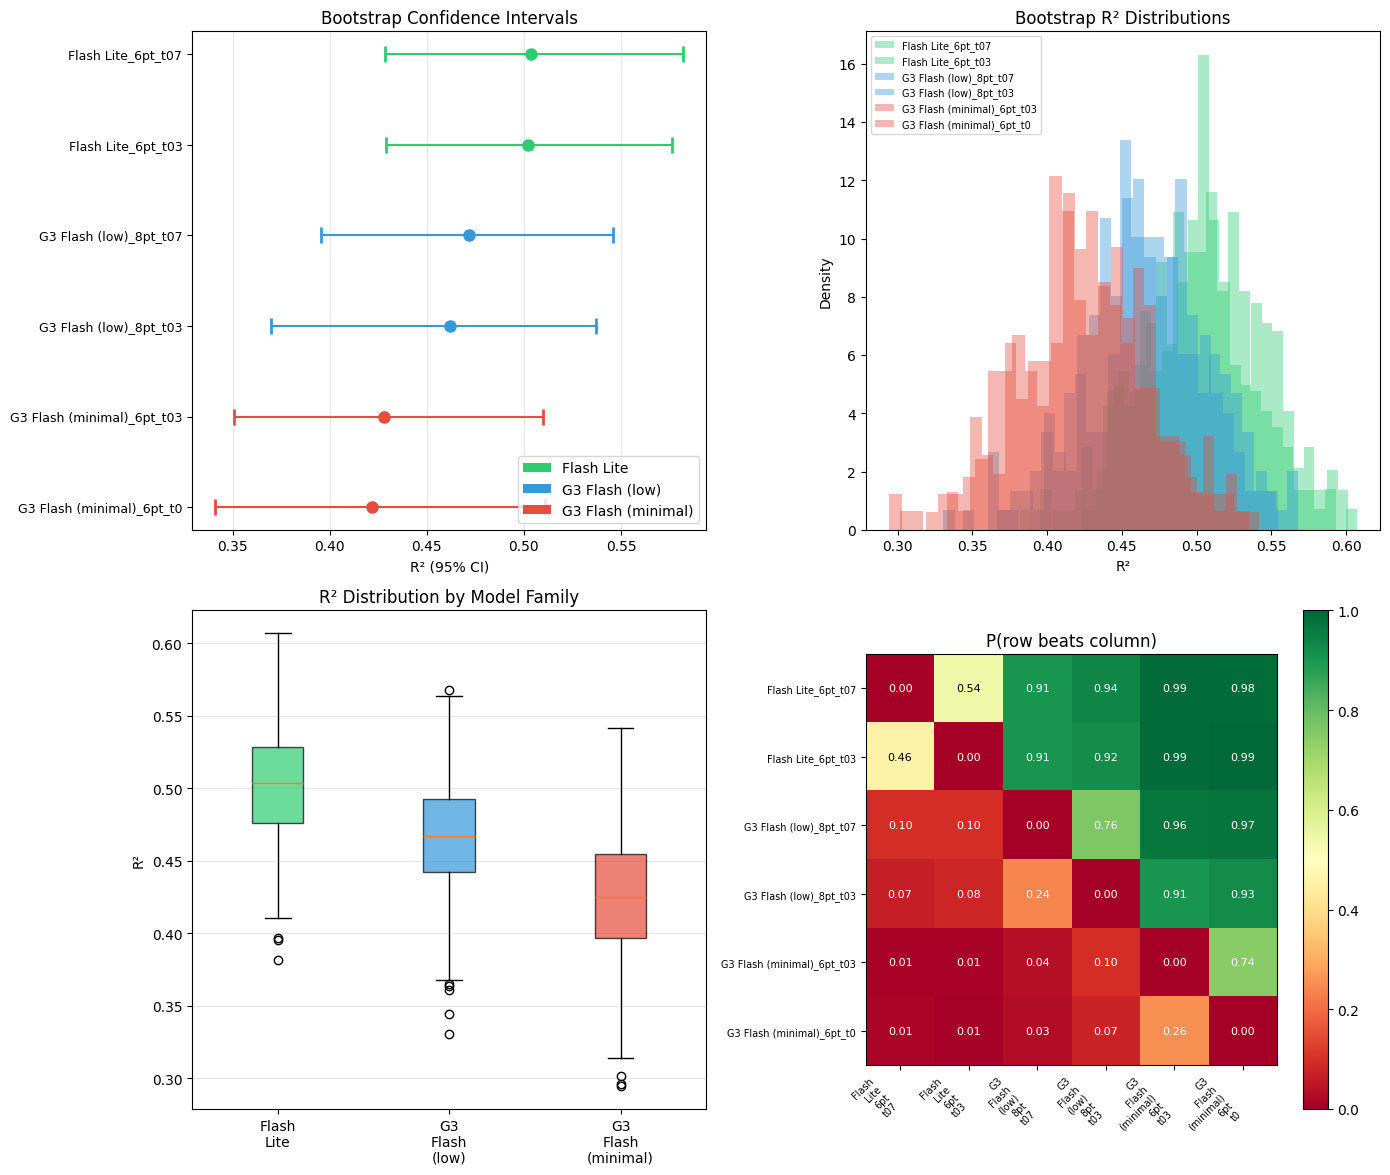


💾 Saved: bootstrap_option_a_results.png

🏆 BEST CONFIGURATION

🥇 WINNER: Flash Lite_6pt_t07
   Mean R²:   0.5037
   Median R²: 0.5045
   95% CI:    [0.429, 0.582]
   CI Width:  0.153

   Parameters:
   - Model: Flash Lite
   - Scale: 6-point
   - Temperature: 0.7
   ☁️  best_config_from_bootstrap_a.json → Drive (winner config)

💾 Saved: best_config_from_bootstrap_a.json
   ☁️  bootstrap_results_a_summary.csv → Drive (bootstrap A summary)
💾 Saved: bootstrap_results_a_summary.csv
   ☁️  bootstrap_results_a.json → Drive (bootstrap A results)
💾 Saved: bootstrap_results_a.json
   ☁️  bootstrap_pairwise_probabilities.csv → Drive (pairwise probs)
💾 Saved: bootstrap_pairwise_probabilities.csv

✅ BOOTSTRAP OPTION A COMPLETE


In [37]:
# @title Cell 19: Bootstrap Option A - Top 6 Configurations (Full Data)

# =============================================================================
# OPTION A: Bootstrap the ML Evaluation Only
# =============================================================================
# Resamples consumers while holding LLM scores fixed
# Runs on TOP 6 configurations (2 per model family) with FULL dataset
#
# ⚠️  This cell can run STANDALONE from saved files after Colab restart.
#     Just run Cells 1-4 (setup), then this cell directly.
# =============================================================================

import numpy as np
import json
import os
import time
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_absolute_error
from tabpfn import TabPFNRegressor

# =============================================================================
# BOOTSTRAP CONFIGURATION
# =============================================================================

N_BOOTSTRAP = 200  # Statistically solid, reasonable runtime
CONFIDENCE = 0.95
FEATURES = ['visual', 'texture', 'flavor']

# Top 2 from each model family
BOOTSTRAP_CONFIGS = [
    'Flash Lite_6pt_t07',      # Best overall (R²=0.573)
    'Flash Lite_6pt_t03',      # 2nd best Flash Lite
    'G3 Flash (low)_8pt_t07',  # Best G3 low (R²=0.518)
    'G3 Flash (low)_8pt_t03',  # 2nd best G3 low
    'G3 Flash (minimal)_6pt_t03',  # Best G3 minimal (R²=0.465)
    'G3 Flash (minimal)_6pt_t0',   # 2nd best G3 minimal
]

print("="*60)
print("🎯 BOOTSTRAP OPTION A: Top 6 Configurations")
print("="*60)
print(f"\nConfigurations to bootstrap:")
for i, cfg in enumerate(BOOTSTRAP_CONFIGS, 1):
    print(f"   {i}. {cfg}")
print(f"\nSettings:")
print(f"   N_BOOTSTRAP = {N_BOOTSTRAP}")
print(f"   CONFIDENCE = {CONFIDENCE}")
print(f"   Using FULL dataset (no subsampling)")

# =============================================================================
# LOAD DATA FROM FILES IF NOT IN MEMORY
# =============================================================================

if 'all_scores' not in dir() or len(all_scores) == 0:
    print("\n📂 Loading all_scores from saved files...")

    if os.path.exists('all_scores_final.json'):
        with open('all_scores_final.json', 'r') as f:
            data = json.load(f)
        all_scores = {cfg_id: {int(k): v for k, v in scores.items()}
                      for cfg_id, scores in data.items()}
        print(f"   ✅ Loaded {len(all_scores)} configurations from all_scores_final.json")
    elif os.path.exists('checkpoints/all_scores_checkpoint.json'):
        with open('checkpoints/all_scores_checkpoint.json', 'r') as f:
            data = json.load(f)
        all_scores = {cfg_id: {int(k): v for k, v in scores.items()}
                      for cfg_id, scores in data.items()}
        print(f"   ✅ Loaded {len(all_scores)} configurations from checkpoint")
    else:
        raise FileNotFoundError("No all_scores file found! Run Cell 8 first.")

if 'df_data' not in dir() or df_data is None:
    print("📂 Loading df_data from saved files...")

    if os.path.exists('df_data.csv'):
        df_data = pd.read_csv('df_data.csv')
        print(f"   ✅ Loaded {len(df_data)} rows from df_data.csv")
    else:
        raise FileNotFoundError("No df_data.csv found! Run Cell 8 first.")

# Filter to only bootstrap configs
all_scores_bootstrap = {k: v for k, v in all_scores.items() if k in BOOTSTRAP_CONFIGS}
print(f"\n✅ Data loaded: {len(all_scores_bootstrap)} configs selected, {len(df_data)} samples")

# Verify all configs exist
missing = [c for c in BOOTSTRAP_CONFIGS if c not in all_scores]
if missing:
    print(f"\n⚠️  WARNING: Missing configs: {missing}")
    print("   Available configs:", list(all_scores.keys()))

# =============================================================================
# PRE-INITIALIZE TABPFN MODEL
# =============================================================================

print(f"\n⏳ Initializing TabPFN model on {device}...")
t0 = time.time()
tabpfn_model = TabPFNRegressor(device=device)

# Warm up with a dummy fit
dummy_X = np.random.randn(100, 1)
dummy_y = np.random.randn(100)
tabpfn_model.fit(dummy_X, dummy_y)
_ = tabpfn_model.predict(dummy_X[:10])
print(f"   ✅ TabPFN initialized and warmed up in {time.time()-t0:.1f}s")

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def apply_scores_to_df(df, scores, scale_points):
    """Apply LLM scores to dataframe."""
    df_scored = df.copy()

    for feat in FEATURES:
        df_scored[feat] = df_scored.index.map(lambda idx: scores.get(idx, {}).get(feat))

    df_scored = df_scored.dropna(subset=FEATURES)

    for feat in FEATURES:
        df_scored[f'{feat}_norm'] = (df_scored[feat] - 1) / (scale_points - 1) * 10

    df_scored['LLM_Score_Normalized'] = df_scored[[f'{f}_norm' for f in FEATURES]].mean(axis=1)

    return df_scored


def parse_config_id(config_id):
    """Parse config_id into components."""
    parts = config_id.rsplit('_', 2)
    if len(parts) == 3:
        model_label = parts[0]
        scale = int(parts[1].replace('pt', ''))
        temp_str = parts[2]
        if temp_str == 't0':
            temperature = 0.0
        elif temp_str == 't03':
            temperature = 0.3
        elif temp_str == 't07':
            temperature = 0.7
        else:
            temperature = float(temp_str[1:]) if temp_str.startswith('t') else 0.0
    else:
        parts = config_id.rsplit('_', 1)
        model_label = parts[0]
        scale = int(parts[1].replace('pt', ''))
        temperature = 0.0

    return model_label, scale, temperature


def bootstrap_evaluate_ml_full(df_scored, n_bootstrap=200, confidence=0.95):
    """
    Bootstrap confidence intervals using FULL dataset.
    """
    if len(df_scored) < 100:
        return None

    consumers = df_scored['Consumer'].unique()
    n_consumers = len(consumers)

    X_full = df_scored[['LLM_Score_Normalized']].values
    y_full = df_scored['Liking_Score'].values
    consumer_array = df_scored['Consumer'].values

    consumer_indices = {c: np.where(consumer_array == c)[0] for c in consumers}

    bootstrap_r2 = []
    bootstrap_mae = []

    for b in range(n_bootstrap):
        np.random.seed(b)
        resampled_consumers = np.random.choice(consumers, size=n_consumers, replace=True)

        boot_indices = []
        consumer_boot = []
        for i, c in enumerate(resampled_consumers):
            idx = consumer_indices[c]
            boot_indices.extend(idx)
            consumer_boot.extend([f"{c}_{i}"] * len(idx))

        boot_indices = np.array(boot_indices)
        consumer_boot = np.array(consumer_boot)

        X_boot = X_full[boot_indices]
        y_boot = y_full[boot_indices]

        # Train/test split by consumer
        unique_boot_consumers = np.unique(consumer_boot)
        np.random.seed(b + 10000)
        n_test = max(1, int(len(unique_boot_consumers) * 0.2))
        test_consumers = set(np.random.choice(unique_boot_consumers, size=n_test, replace=False))

        test_mask = np.array([c in test_consumers for c in consumer_boot])
        train_mask = ~test_mask

        train_idx = np.where(train_mask)[0]
        test_idx = np.where(test_mask)[0]

        if len(test_idx) < 10 or len(train_idx) < 50:
            continue

        # NO SUBSAMPLING - use full training data
        try:
            tabpfn_model.fit(X_boot[train_idx], y_boot[train_idx])
            y_pred = tabpfn_model.predict(X_boot[test_idx])

            bootstrap_r2.append(r2_score(y_boot[test_idx], y_pred))
            bootstrap_mae.append(mean_absolute_error(y_boot[test_idx], y_pred))
        except Exception as e:
            print(f"      Error in bootstrap {b}: {e}")
            continue

    if len(bootstrap_r2) < 50:
        print(f"   ⚠️ Only {len(bootstrap_r2)} successful bootstraps")
        return None

    alpha = (1 - confidence) / 2

    return {
        'r2_mean': np.mean(bootstrap_r2),
        'r2_std': np.std(bootstrap_r2),
        'r2_ci_lower': np.percentile(bootstrap_r2, 100 * alpha),
        'r2_ci_upper': np.percentile(bootstrap_r2, 100 * (1 - alpha)),
        'r2_median': np.median(bootstrap_r2),
        'mae_mean': np.mean(bootstrap_mae),
        'mae_std': np.std(bootstrap_mae),
        'mae_ci_lower': np.percentile(bootstrap_mae, 100 * alpha),
        'mae_ci_upper': np.percentile(bootstrap_mae, 100 * (1 - alpha)),
        'bootstrap_r2': bootstrap_r2,
        'bootstrap_mae': bootstrap_mae,
        'n_successful': len(bootstrap_r2)
    }


# =============================================================================
# RUN BOOTSTRAP FOR SELECTED CONFIGURATIONS
# =============================================================================

print("\n" + "="*60)
print("🚀 RUNNING BOOTSTRAP")
print("="*60)

bootstrap_results_a = {}
total_start = time.time()

for i, config_id in enumerate(BOOTSTRAP_CONFIGS, 1):
    if config_id not in all_scores:
        print(f"\n[{i}/{len(BOOTSTRAP_CONFIGS)}] {config_id} - SKIPPED (not found)")
        continue

    scores = all_scores[config_id]
    model_label, scale_points, temperature = parse_config_id(config_id)

    print(f"\n[{i}/{len(BOOTSTRAP_CONFIGS)}] {config_id}")
    print(f"   Model: {model_label}, Scale: {scale_points}pt, Temp: {temperature}")

    # Prepare scored dataframe
    df_scored = apply_scores_to_df(df_data, scores, scale_points)
    print(f"   Valid samples: {len(df_scored)}")

    if len(df_scored) < 100:
        print(f"   ⚠️ Skipping (too few valid samples)")
        continue

    # Run bootstrap
    t0 = time.time()
    print(f"   Running {N_BOOTSTRAP} bootstrap samples (full data)...")

    result = bootstrap_evaluate_ml_full(df_scored, n_bootstrap=N_BOOTSTRAP, confidence=CONFIDENCE)
    elapsed = time.time() - t0

    if result is not None:
        bootstrap_results_a[config_id] = result
        print(f"   ✅ R² = {result['r2_mean']:.4f} [{result['r2_ci_lower']:.3f}, {result['r2_ci_upper']:.3f}]")
        print(f"   ✅ MAE = {result['mae_mean']:.4f} [{result['mae_ci_lower']:.3f}, {result['mae_ci_upper']:.3f}]")
        print(f"   ⏱️  Completed in {elapsed:.1f}s ({elapsed/N_BOOTSTRAP:.2f}s per bootstrap)")

total_elapsed = time.time() - total_start
print(f"\n{'='*60}")
print(f"✅ Completed bootstrap for {len(bootstrap_results_a)}/{len(BOOTSTRAP_CONFIGS)} configurations")
print(f"   Total time: {total_elapsed/60:.1f} minutes")
print("="*60)

# =============================================================================
# SUMMARY TABLE
# =============================================================================

print("\n" + "="*60)
print("📊 BOOTSTRAP RESULTS SUMMARY")
print("="*60)

summary_rows = []
for config_id, r in bootstrap_results_a.items():
    model_label, scale, temp = parse_config_id(config_id)
    summary_rows.append({
        'config_id': config_id,
        'model': model_label,
        'scale': scale,
        'temperature': temp,
        'r2_mean': r['r2_mean'],
        'r2_median': r['r2_median'],
        'r2_ci_lower': r['r2_ci_lower'],
        'r2_ci_upper': r['r2_ci_upper'],
        'r2_ci_width': r['r2_ci_upper'] - r['r2_ci_lower'],
        'mae_mean': r['mae_mean'],
        'n_bootstraps': r['n_successful']
    })

df_bootstrap_summary = pd.DataFrame(summary_rows).sort_values('r2_mean', ascending=False)

print("\nConfigurations ranked by mean R²:\n")
print(df_bootstrap_summary[['config_id', 'r2_mean', 'r2_median', 'r2_ci_lower', 'r2_ci_upper', 'r2_ci_width']].to_string(index=False))

# =============================================================================
# PAIRWISE COMPARISONS
# =============================================================================

print("\n" + "="*60)
print("🔬 PAIRWISE COMPARISONS: P(row > column) for R²")
print("="*60)

configs = list(bootstrap_results_a.keys())
n_configs = len(configs)
prob_matrix = np.zeros((n_configs, n_configs))

for i, c1 in enumerate(configs):
    for j, c2 in enumerate(configs):
        r2_1 = np.array(bootstrap_results_a[c1]['bootstrap_r2'])
        r2_2 = np.array(bootstrap_results_a[c2]['bootstrap_r2'])
        min_len = min(len(r2_1), len(r2_2))
        prob_matrix[i, j] = np.mean(r2_1[:min_len] > r2_2[:min_len])

df_pairwise = pd.DataFrame(prob_matrix, index=configs, columns=configs)
print("\nP(row beats column):\n")
print(df_pairwise.round(3).to_string())

# =============================================================================
# MODEL FAMILY COMPARISON
# =============================================================================

print("\n" + "="*60)
print("📈 MODEL FAMILY COMPARISON")
print("="*60)

# Group by model family
family_results = {}
for config_id, r in bootstrap_results_a.items():
    if 'Flash Lite' in config_id:
        family = 'Flash Lite'
    elif 'low' in config_id:
        family = 'G3 Flash (low)'
    else:
        family = 'G3 Flash (minimal)'

    if family not in family_results:
        family_results[family] = []
    family_results[family].extend(r['bootstrap_r2'])

print("\nModel family statistics:")
for family in ['Flash Lite', 'G3 Flash (low)', 'G3 Flash (minimal)']:
    if family in family_results:
        r2s = family_results[family]
        print(f"\n   {family}:")
        print(f"      Mean R²: {np.mean(r2s):.4f} ± {np.std(r2s):.4f}")
        print(f"      95% CI: [{np.percentile(r2s, 2.5):.3f}, {np.percentile(r2s, 97.5):.3f}]")

# Cross-family comparisons
print("\n📊 Cross-family comparisons (P(A > B)):")
families = ['Flash Lite', 'G3 Flash (low)', 'G3 Flash (minimal)']
for i, f1 in enumerate(families):
    for f2 in families[i+1:]:
        if f1 in family_results and f2 in family_results:
            r2_1 = np.array(family_results[f1])
            r2_2 = np.array(family_results[f2])
            min_len = min(len(r2_1), len(r2_2))
            prob = np.mean(r2_1[:min_len] > r2_2[:min_len])
            print(f"   P({f1} > {f2}): {prob:.3f}")

# =============================================================================
# VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Forest plot (confidence intervals)
ax1 = axes[0, 0]
sorted_configs = df_bootstrap_summary['config_id'].tolist()
means = [bootstrap_results_a[c]['r2_mean'] for c in sorted_configs]
ci_lower = [bootstrap_results_a[c]['r2_ci_lower'] for c in sorted_configs]
ci_upper = [bootstrap_results_a[c]['r2_ci_upper'] for c in sorted_configs]

# Color by model family
colors = []
for c in sorted_configs:
    if 'Flash Lite' in c:
        colors.append('#2ecc71')  # Green
    elif 'low' in c:
        colors.append('#3498db')  # Blue
    else:
        colors.append('#e74c3c')  # Red

y_pos = range(len(sorted_configs))
for idx, (mean, lo, hi, color) in enumerate(zip(means, ci_lower, ci_upper, colors)):
    ax1.errorbar(mean, idx, xerr=[[mean - lo], [hi - mean]],
                 fmt='o', capsize=6, capthick=2, markersize=8, color=color)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(sorted_configs, fontsize=9)
ax1.set_xlabel('R² (95% CI)')
ax1.set_title('Bootstrap Confidence Intervals')
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Flash Lite'),
    Patch(facecolor='#3498db', label='G3 Flash (low)'),
    Patch(facecolor='#e74c3c', label='G3 Flash (minimal)')
]
ax1.legend(handles=legend_elements, loc='lower right')

# 2. Distribution comparison
ax2 = axes[0, 1]
for config, color in zip(sorted_configs, colors):
    ax2.hist(bootstrap_results_a[config]['bootstrap_r2'],
             alpha=0.4, bins=30, label=config, density=True, color=color)
ax2.set_xlabel('R²')
ax2.set_ylabel('Density')
ax2.set_title('Bootstrap R² Distributions')
ax2.legend(fontsize=7, loc='upper left')

# 3. Model family box plots
ax3 = axes[1, 0]
family_data = []
family_labels = []
family_colors_box = []
for family, color in [('Flash Lite', '#2ecc71'), ('G3 Flash (low)', '#3498db'), ('G3 Flash (minimal)', '#e74c3c')]:
    if family in family_results:
        family_data.append(family_results[family])
        family_labels.append(family.replace(' ', '\n'))
        family_colors_box.append(color)

bp = ax3.boxplot(family_data, labels=family_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], family_colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_ylabel('R²')
ax3.set_title('R² Distribution by Model Family')
ax3.grid(axis='y', alpha=0.3)

# 4. Pairwise heatmap
ax4 = axes[1, 1]
im = ax4.imshow(prob_matrix, cmap='RdYlGn', vmin=0, vmax=1)
ax4.set_xticks(range(n_configs))
ax4.set_yticks(range(n_configs))
ax4.set_xticklabels([c.replace('_', '\n').replace(' ', '\n') for c in configs], fontsize=7, rotation=45, ha='right')
ax4.set_yticklabels(configs, fontsize=7)
ax4.set_title('P(row beats column)')
plt.colorbar(im, ax=ax4)

for i in range(n_configs):
    for j in range(n_configs):
        color = 'white' if prob_matrix[i, j] > 0.65 or prob_matrix[i, j] < 0.35 else 'black'
        ax4.text(j, i, f'{prob_matrix[i, j]:.2f}',
                ha='center', va='center', fontsize=8, color=color)

plt.tight_layout()
plt.savefig('bootstrap_option_a_results.png', dpi=150, bbox_inches='tight')
save_to_drive('bootstrap_option_a_results.png', 'bootstrap A viz')
plt.show()

print("\n💾 Saved: bootstrap_option_a_results.png")

# =============================================================================
# SELECT WINNER
# =============================================================================

print("\n" + "="*60)
print("🏆 BEST CONFIGURATION")
print("="*60)

best_config = df_bootstrap_summary.iloc[0]
BEST_CONFIG_ID = best_config['config_id']

print(f"\n🥇 WINNER: {BEST_CONFIG_ID}")
print(f"   Mean R²:   {best_config['r2_mean']:.4f}")
print(f"   Median R²: {best_config['r2_median']:.4f}")
print(f"   95% CI:    [{best_config['r2_ci_lower']:.3f}, {best_config['r2_ci_upper']:.3f}]")
print(f"   CI Width:  {best_config['r2_ci_width']:.3f}")

BEST_MODEL_LABEL, BEST_SCALE, BEST_TEMPERATURE = parse_config_id(BEST_CONFIG_ID)

print(f"\n   Parameters:")
print(f"   - Model: {BEST_MODEL_LABEL}")
print(f"   - Scale: {BEST_SCALE}-point")
print(f"   - Temperature: {BEST_TEMPERATURE}")

# =============================================================================
# SAVE RESULTS
# =============================================================================

# Save winner info
winner_info = {
    'config_id': BEST_CONFIG_ID,
    'model_label': BEST_MODEL_LABEL,
    'scale': BEST_SCALE,
    'temperature': BEST_TEMPERATURE,
    'median_r2': float(best_config['r2_median']),
    'mean_r2': float(best_config['r2_mean']),
    'ci_lower': float(best_config['r2_ci_lower']),
    'ci_upper': float(best_config['r2_ci_upper'])
}

with open('best_config_from_bootstrap_a.json', 'w') as f:
    json.dump(winner_info, f, indent=2)
save_to_drive('best_config_from_bootstrap_a.json', 'winner config')
print(f"\n💾 Saved: best_config_from_bootstrap_a.json")

# Save summary
df_bootstrap_summary.to_csv('bootstrap_results_a_summary.csv', index=False)
save_to_drive('bootstrap_results_a_summary.csv', 'bootstrap A summary')
print("💾 Saved: bootstrap_results_a_summary.csv")

# Save full results
bootstrap_results_summary = {}
for config_id, r in bootstrap_results_a.items():
    bootstrap_results_summary[config_id] = {
        'r2_mean': r['r2_mean'],
        'r2_median': r['r2_median'],
        'r2_std': r['r2_std'],
        'r2_ci_lower': r['r2_ci_lower'],
        'r2_ci_upper': r['r2_ci_upper'],
        'mae_mean': r['mae_mean'],
        'mae_ci_lower': r['mae_ci_lower'],
        'mae_ci_upper': r['mae_ci_upper'],
        'n_successful': r['n_successful']
    }

with open('bootstrap_results_a.json', 'w') as f:
    json.dump(bootstrap_results_summary, f, indent=2)
save_to_drive('bootstrap_results_a.json', 'bootstrap A results')
print("💾 Saved: bootstrap_results_a.json")

# Save pairwise matrix
df_pairwise.to_csv('bootstrap_pairwise_probabilities.csv')
save_to_drive('bootstrap_pairwise_probabilities.csv', 'pairwise probs')
print("💾 Saved: bootstrap_pairwise_probabilities.csv")

print("\n" + "="*60)
print("✅ BOOTSTRAP OPTION A COMPLETE")
print("="*60)

In [ ]:
# =============================================================================
# OPTION B: Bootstrap the Full Pipeline (WINNER ONLY)
# =============================================================================
# Resamples consumers, re-scores with LLM, re-trains ML model
# Captures end-to-end uncertainty including LLM scoring variability
#
# ⚠️  This cell runs ONLY on the best config identified by Option A
# ⚠️  Requires API keys and makes many API calls (~N_BOOTSTRAP × n_samples)
# =============================================================================

import asyncio
import aiohttp
import json
import os
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_absolute_error
from tabpfn import TabPFNRegressor

# =============================================================================
# LOAD WINNER FROM OPTION A
# =============================================================================
if not os.path.exists('best_config_from_bootstrap_a.json'):
    raise FileNotFoundError(
        "best_config_from_bootstrap_a.json not found!\n"
        "Run Option A bootstrap first to identify the best configuration."
    )

with open('best_config_from_bootstrap_a.json', 'r') as f:
    winner_info = json.load(f)

BEST_CONFIG_ID = winner_info['config_id']
BEST_MODEL_LABEL = winner_info['model_label']
BEST_SCALE = winner_info['scale']
BEST_TEMPERATURE = winner_info['temperature']

print("="*60)
print("OPTION B: Full Pipeline Bootstrap")
print("="*60)
print(f"\n🏆 Running on winner from Option A:")
print(f"   Config: {BEST_CONFIG_ID}")
print(f"   Model: {BEST_MODEL_LABEL}")
print(f"   Scale: {BEST_SCALE}-point")
print(f"   Temperature: {BEST_TEMPERATURE}")
print(f"\n   Option A results:")
print(f"   Median R²: {winner_info['median_r2']:.4f}")
print(f"   95% CI: [{winner_info['ci_lower']:.3f}, {winner_info['ci_upper']:.3f}]")

# =============================================================================
# LOAD df_data IF NEEDED
# =============================================================================
if 'df_data' not in dir() or df_data is None:
    if os.path.exists('df_data.csv'):
        df_data = pd.read_csv('df_data.csv')
        print(f"\n📂 Loaded df_data: {len(df_data)} rows")
    else:
        raise FileNotFoundError("df_data.csv not found!")

# =============================================================================
# FIND MODEL CONFIG
# =============================================================================
# Map label back to model config
model_config = None
for m in MODELS:
    if m['label'] == BEST_MODEL_LABEL:
        model_config = m
        break

if model_config is None:
    raise ValueError(f"Could not find model config for label: {BEST_MODEL_LABEL}")

model_name = model_config['name']
is_gemini3 = model_config['is_gemini3']
thinking_config = model_config['thinking_config']
scale_labels = SCALES[BEST_SCALE]['labels']

print(f"\n   Model name: {model_name}")
print(f"   Thinking: {thinking_config}")

# =============================================================================
# BOOTSTRAP CONFIGURATION
# =============================================================================
N_BOOTSTRAP_B = 100  # Number of bootstrap samples (each makes ~n_samples API calls)

estimated_api_calls = N_BOOTSTRAP_B * len(df_data)
print(f"\n⚠️  WARNING: This will make approximately {estimated_api_calls:,} API calls")
print(f"   ({N_BOOTSTRAP_B} bootstrap samples × {len(df_data)} samples each)")
print(f"   Estimated time: {estimated_api_calls / 1000 * 3:.0f} - {estimated_api_calls / 1000 * 10:.0f} minutes")

# Uncomment the line below to proceed
# PROCEED_WITH_OPTION_B = True

if 'PROCEED_WITH_OPTION_B' not in dir() or not PROCEED_WITH_OPTION_B:
    print("\n" + "="*60)
    print("⏸️  OPTION B IS PAUSED")
    print("="*60)
    print("\nTo run Option B, uncomment this line above and re-run the cell:")
    print("   # PROCEED_WITH_OPTION_B = True")
    print("\nOr run this in a new cell:")
    print("   PROCEED_WITH_OPTION_B = True")
    print("   # Then re-run this cell")
else:
    print("\n" + "="*60)
    print("🚀 STARTING FULL PIPELINE BOOTSTRAP")
    print("="*60)

    # =========================================================================
    # ASYNC SCORING FUNCTION FOR BOOTSTRAP
    # =========================================================================
    async def score_single_row_async(session, row_data, api_key, url, gen_config):
        """Score a single row asynchronously."""
        idx, row = row_data
        prompt = build_prompt(row, BEST_SCALE, scale_labels)

        payload = {
            "contents": [{"parts": [{"text": prompt}]}],
            "generationConfig": gen_config
        }

        midpoint = (BEST_SCALE + 1) // 2
        result = {f: midpoint for f in FEATURES}

        for attempt in range(3):
            try:
                async with session.post(url, json=payload, params={"key": api_key}, timeout=aiohttp.ClientTimeout(total=60)) as resp:
                    if resp.status == 200:
                        resp_json = await resp.json()
                        text = extract_response_text(resp_json, is_gemini3)
                        scores = parse_scores(text, BEST_SCALE)
                        if scores:
                            result = scores
                            break
                    elif resp.status == 429:
                        await asyncio.sleep(2 ** attempt)
            except Exception as e:
                await asyncio.sleep(1)

        return idx, result

    async def score_bootstrap_sample_async(df_boot, api_keys):
        """Score all rows in a bootstrap sample."""
        url = f"https://generativelanguage.googleapis.com/v1beta/models/{model_name}:generateContent"

        gen_config = {
            "responseMimeType": "application/json",
            "temperature": BEST_TEMPERATURE
        }
        if thinking_config:
            gen_config["thinkingConfig"] = thinking_config

        connector = aiohttp.TCPConnector(limit=len(api_keys))
        async with aiohttp.ClientSession(connector=connector) as session:
            tasks = []
            for i, (idx, row) in enumerate(df_boot.iterrows()):
                api_key = api_keys[i % len(api_keys)]
                tasks.append(score_single_row_async(session, (idx, row), api_key, url, gen_config))

            results = await asyncio.gather(*tasks)

        return {idx: scores for idx, scores in results}

    # =========================================================================
    # RUN BOOTSTRAP
    # =========================================================================
    consumers = df_data['Consumer'].unique()
    n_consumers = len(consumers)

    bootstrap_r2_b = []
    bootstrap_mae_b = []

    print(f"\nRunning {N_BOOTSTRAP_B} bootstrap samples...")

    for b in range(N_BOOTSTRAP_B):
        print(f"  Bootstrap {b+1}/{N_BOOTSTRAP_B}...", end=" ")

        # Resample consumers
        np.random.seed(b)
        resampled_idx = np.random.choice(n_consumers, size=n_consumers, replace=True)
        resampled_consumers = consumers[resampled_idx]

        # Build resampled dataset
        frames = []
        for i, c in enumerate(resampled_consumers):
            chunk = df_data[df_data['Consumer'] == c].copy()
            chunk['Consumer_Boot'] = f"{c}_{i}"
            frames.append(chunk)
        df_boot = pd.concat(frames, ignore_index=True)

        # Score with LLM
        scores = asyncio.run(score_bootstrap_sample_async(df_boot, UNIQUE_KEYS))

        # Apply scores
        df_boot['visual'] = df_boot.index.map(lambda x: scores.get(x, {}).get('visual'))
        df_boot['texture'] = df_boot.index.map(lambda x: scores.get(x, {}).get('texture'))
        df_boot['flavor'] = df_boot.index.map(lambda x: scores.get(x, {}).get('flavor'))

        # Drop rows with missing scores
        df_boot = df_boot.dropna(subset=['visual', 'texture', 'flavor'])

        if len(df_boot) < 100:
            print(f"skipped (only {len(df_boot)} valid)")
            continue

        # Normalize and compute composite score
        for feat in FEATURES:
            df_boot[f'{feat}_norm'] = (df_boot[feat] - 1) / (BEST_SCALE - 1) * 10
        df_boot['LLM_Score_Normalized'] = df_boot[['visual_norm', 'texture_norm', 'flavor_norm']].mean(axis=1)

        # Prepare features
        X = df_boot[['LLM_Score_Normalized']].values
        y = df_boot['Liking_Score'].values
        groups = df_boot['Consumer_Boot'].values

        # Train/test split
        splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=b)
        try:
            train_idx, test_idx = next(splitter.split(X, y, groups))
        except:
            print("split failed")
            continue

        if len(test_idx) < 20:
            print("too few test samples")
            continue

        # Fit and evaluate
        model = TabPFNRegressor(device=device)
        model.fit(X[train_idx], y[train_idx])
        y_pred = model.predict(X[test_idx])

        r2 = r2_score(y[test_idx], y_pred)
        mae = mean_absolute_error(y[test_idx], y_pred)

        bootstrap_r2_b.append(r2)
        bootstrap_mae_b.append(mae)

        print(f"R²={r2:.3f}")

    # =========================================================================
    # RESULTS
    # =========================================================================
    print("\n" + "="*60)
    print("OPTION B RESULTS")
    print("="*60)

    bootstrap_results_b = {
        'r2_mean': np.mean(bootstrap_r2_b),
        'r2_median': np.median(bootstrap_r2_b),
        'r2_std': np.std(bootstrap_r2_b),
        'r2_ci_lower': np.percentile(bootstrap_r2_b, 2.5),
        'r2_ci_upper': np.percentile(bootstrap_r2_b, 97.5),
        'mae_mean': np.mean(bootstrap_mae_b),
        'mae_ci_lower': np.percentile(bootstrap_mae_b, 2.5),
        'mae_ci_upper': np.percentile(bootstrap_mae_b, 97.5),
        'n_successful': len(bootstrap_r2_b),
        'bootstrap_r2': bootstrap_r2_b,
        'bootstrap_mae': bootstrap_mae_b
    }

    print(f"\nConfiguration: {BEST_CONFIG_ID}")
    print(f"Successful bootstraps: {bootstrap_results_b['n_successful']}/{N_BOOTSTRAP_B}")
    print(f"\nFull Pipeline (Option B):")
    print(f"  Median R²: {bootstrap_results_b['r2_median']:.4f}")
    print(f"  Mean R²:   {bootstrap_results_b['r2_mean']:.4f} ± {bootstrap_results_b['r2_std']:.4f}")
    print(f"  95% CI:    [{bootstrap_results_b['r2_ci_lower']:.3f}, {bootstrap_results_b['r2_ci_upper']:.3f}]")
    print(f"\nML-only (Option A):")
    print(f"  Median R²: {winner_info['median_r2']:.4f}")
    print(f"  95% CI:    [{winner_info['ci_lower']:.3f}, {winner_info['ci_upper']:.3f}]")

    ci_width_a = winner_info['ci_upper'] - winner_info['ci_lower']
    ci_width_b = bootstrap_results_b['r2_ci_upper'] - bootstrap_results_b['r2_ci_lower']
    print(f"\nCI Width Comparison:")
    print(f"  Option A: {ci_width_a:.3f}")
    print(f"  Option B: {ci_width_b:.3f}")
    print(f"  Difference: {ci_width_b - ci_width_a:+.3f} (Option B captures LLM variance)")

    # Save results
    with open('bootstrap_results_b.json', 'w') as f:
        json.dump({
            'config_id': BEST_CONFIG_ID,
            'r2_mean': bootstrap_results_b['r2_mean'],
            'r2_median': bootstrap_results_b['r2_median'],
            'r2_std': bootstrap_results_b['r2_std'],
            'r2_ci_lower': bootstrap_results_b['r2_ci_lower'],
            'r2_ci_upper': bootstrap_results_b['r2_ci_upper'],
            'mae_mean': bootstrap_results_b['mae_mean'],
            'n_successful': bootstrap_results_b['n_successful']
        }, f, indent=2)
    save_to_drive('bootstrap_results_b.json', 'bootstrap B results')
    print(f"\n💾 Saved: bootstrap_results_b.json")

    # Visualization
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 1. Distribution comparison
    ax1 = axes[0]
    if BEST_CONFIG_ID in bootstrap_results_a:
        ax1.hist(bootstrap_results_a[BEST_CONFIG_ID]['bootstrap_r2'], bins=30, alpha=0.6,
                 label='Option A (ML only)', density=True, color='blue')
    ax1.hist(bootstrap_r2_b, bins=30, alpha=0.6,
             label='Option B (Full pipeline)', density=True, color='orange')
    ax1.axvline(winner_info['median_r2'], color='blue', linestyle='--', label=f'A median: {winner_info["median_r2"]:.3f}')
    ax1.axvline(bootstrap_results_b['r2_median'], color='orange', linestyle='--', label=f'B median: {bootstrap_results_b["r2_median"]:.3f}')
    ax1.set_xlabel('R²')
    ax1.set_ylabel('Density')
    ax1.set_title(f'Bootstrap Distributions: {BEST_CONFIG_ID}')
    ax1.legend()

    # 2. CI comparison
    ax2 = axes[1]
    y_pos = [0, 1]
    labels = ['Option A\n(ML only)', 'Option B\n(Full pipeline)']
    means = [winner_info['mean_r2'], bootstrap_results_b['r2_mean']]

    # Option A CI
    ax2.errorbar(winner_info['mean_r2'], 0,
                 xerr=[[winner_info['mean_r2'] - winner_info['ci_lower']],
                       [winner_info['ci_upper'] - winner_info['mean_r2']]],
                 fmt='o', capsize=10, capthick=2, markersize=10, color='blue', label='Option A')

    # Option B CI
    ax2.errorbar(bootstrap_results_b['r2_mean'], 1,
                 xerr=[[bootstrap_results_b['r2_mean'] - bootstrap_results_b['r2_ci_lower']],
                       [bootstrap_results_b['r2_ci_upper'] - bootstrap_results_b['r2_mean']]],
                 fmt='s', capsize=10, capthick=2, markersize=10, color='orange', label='Option B')

    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(labels)
    ax2.set_xlabel('R² (95% CI)')
    ax2.set_title('Confidence Interval Comparison')
    ax2.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('bootstrap_option_b_results.png', dpi=150, bbox_inches='tight')
    save_to_drive('bootstrap_option_b_results.png', 'bootstrap B viz')
    plt.show()
    print(f"\n💾 Saved: bootstrap_option_b_results.png")


In [ ]:
# @title Cell 20: Common Success Analysis (Fair Comparison)

# =============================================================================
# COMMON SUCCESS ANALYSIS
# =============================================================================
# Compares models ONLY on samples where ALL models succeeded
# This controls for the possibility that simpler models benefit from
# failing on harder examples while more complex models attempt (and fail) them
# =============================================================================

import numpy as np
import json
import os
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_absolute_error
from tabpfn import TabPFNRegressor

print("="*70)
print("🔬 COMMON SUCCESS ANALYSIS: Fair Model Comparison")
print("="*70)
print("\nThis analysis compares models only on samples where ALL models")
print("provided valid scores, controlling for differential failure rates.")

# =============================================================================
# CONFIGURATION
# =============================================================================

FEATURES = ['visual', 'texture', 'flavor']

# Configs to compare (same as bootstrap)
COMPARE_CONFIGS = [
    'Flash Lite_6pt_t07',
    'Flash Lite_6pt_t03',
    'G3 Flash (low)_8pt_t07',
    'G3 Flash (low)_8pt_t03',
    'G3 Flash (minimal)_6pt_t03',
    'G3 Flash (minimal)_6pt_t0',
]

# =============================================================================
# LOAD DATA IF NEEDED
# =============================================================================

if 'all_scores' not in dir() or len(all_scores) == 0:
    if os.path.exists('all_scores_final.json'):
        with open('all_scores_final.json', 'r') as f:
            data = json.load(f)
        all_scores = {cfg_id: {int(k): v for k, v in scores.items()}
                      for cfg_id, scores in data.items()}
        print(f"\n📂 Loaded {len(all_scores)} configurations")

if 'df_data' not in dir() or df_data is None:
    if os.path.exists('df_data.csv'):
        df_data = pd.read_csv('df_data.csv')
        print(f"📂 Loaded {len(df_data)} samples")

# =============================================================================
# FIND COMMON SUCCESS SAMPLES
# =============================================================================

print("\n" + "="*70)
print("1️⃣ IDENTIFYING COMMON SUCCESS SAMPLES")
print("="*70)

def get_valid_indices(scores):
    """Get indices where all three features have valid scores."""
    valid = set()
    for idx, score_dict in scores.items():
        if all(f in score_dict and score_dict[f] is not None for f in FEATURES):
            valid.add(idx)
    return valid

# Get valid indices for each config
valid_indices_per_config = {}
for config_id in COMPARE_CONFIGS:
    if config_id in all_scores:
        valid_indices_per_config[config_id] = get_valid_indices(all_scores[config_id])
        print(f"   {config_id}: {len(valid_indices_per_config[config_id]):,} valid samples")

# Find intersection (samples valid for ALL configs)
common_valid_indices = set.intersection(*valid_indices_per_config.values())
print(f"\n   📊 Common success samples: {len(common_valid_indices):,}")
print(f"   📊 Total samples: {len(df_data):,}")
print(f"   📊 Retention rate: {len(common_valid_indices)/len(df_data)*100:.1f}%")

# Show per-config failure rates
print("\n   Per-config failure analysis:")
for config_id in COMPARE_CONFIGS:
    n_valid = len(valid_indices_per_config[config_id])
    n_failed = len(df_data) - n_valid
    print(f"      {config_id}: {n_failed} failures ({n_failed/len(df_data)*100:.1f}%)")

# =============================================================================
# ANALYZE FAILED SAMPLES
# =============================================================================

print("\n" + "="*70)
print("2️⃣ ANALYZING FAILED SAMPLES")
print("="*70)

# Which samples did each model fail on?
all_indices = set(range(len(df_data)))

# Samples that Flash Lite succeeded on but G3 minimal failed on
flash_lite_configs = [c for c in COMPARE_CONFIGS if 'Flash Lite' in c]
g3_minimal_configs = [c for c in COMPARE_CONFIGS if 'minimal' in c]

flash_lite_valid = set.intersection(*[valid_indices_per_config[c] for c in flash_lite_configs])
g3_minimal_valid = set.intersection(*[valid_indices_per_config[c] for c in g3_minimal_configs])

only_flash_lite = flash_lite_valid - g3_minimal_valid  # Flash Lite succeeded, G3 minimal failed
only_g3_minimal = g3_minimal_valid - flash_lite_valid  # G3 minimal succeeded, Flash Lite failed
both_succeeded = flash_lite_valid & g3_minimal_valid

print(f"\n   Samples where only Flash Lite succeeded: {len(only_flash_lite)}")
print(f"   Samples where only G3 minimal succeeded: {len(only_g3_minimal)}")
print(f"   Samples where both succeeded: {len(both_succeeded)}")

# Are the "Flash Lite only" samples easier or harder?
if len(only_flash_lite) > 0 and len(only_g3_minimal) > 0:
    liking_flash_only = df_data.loc[list(only_flash_lite), 'Liking_Score'].mean()
    liking_g3_only = df_data.loc[list(only_g3_minimal), 'Liking_Score'].mean()
    liking_both = df_data.loc[list(both_succeeded), 'Liking_Score'].mean()
    liking_overall = df_data['Liking_Score'].mean()

    print(f"\n   Mean Liking Score by sample type:")
    print(f"      Overall dataset: {liking_overall:.2f}")
    print(f"      Both succeeded: {liking_both:.2f}")
    print(f"      Only Flash Lite succeeded: {liking_flash_only:.2f}")
    print(f"      Only G3 minimal succeeded: {liking_g3_only:.2f}")

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def parse_config_id(config_id):
    """Parse config_id into components."""
    parts = config_id.rsplit('_', 2)
    if len(parts) == 3:
        model_label = parts[0]
        scale = int(parts[1].replace('pt', ''))
        temp_str = parts[2]
        if temp_str == 't0':
            temperature = 0.0
        elif temp_str == 't03':
            temperature = 0.3
        elif temp_str == 't07':
            temperature = 0.7
        else:
            temperature = float(temp_str[1:]) if temp_str.startswith('t') else 0.0
    else:
        parts = config_id.rsplit('_', 1)
        model_label = parts[0]
        scale = int(parts[1].replace('pt', ''))
        temperature = 0.0
    return model_label, scale, temperature


def evaluate_on_subset(df, scores, scale_points, valid_indices, model):
    """Evaluate a config on a specific subset of indices."""
    df_subset = df.loc[list(valid_indices)].copy()

    # Apply scores
    for feat in FEATURES:
        df_subset[feat] = df_subset.index.map(lambda idx: scores.get(idx, {}).get(feat))

    df_subset = df_subset.dropna(subset=FEATURES)

    if len(df_subset) < 100:
        return None

    # Normalize
    for feat in FEATURES:
        df_subset[f'{feat}_norm'] = (df_subset[feat] - 1) / (scale_points - 1) * 10
    df_subset['LLM_Score_Normalized'] = df_subset[[f'{f}_norm' for f in FEATURES]].mean(axis=1)

    # Prepare data
    X = df_subset[['LLM_Score_Normalized']].values
    y = df_subset['Liking_Score'].values
    groups = df_subset['Consumer'].values

    # Train/test split
    splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    train_idx, test_idx = next(splitter.split(X, y, groups))

    # Fit and evaluate
    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict(X[test_idx])

    return {
        'r2': r2_score(y[test_idx], y_pred),
        'mae': mean_absolute_error(y[test_idx], y_pred),
        'n_samples': len(df_subset),
        'n_train': len(train_idx),
        'n_test': len(test_idx)
    }

# =============================================================================
# EVALUATE ON COMMON SUCCESS SAMPLES
# =============================================================================

print("\n" + "="*70)
print("3️⃣ EVALUATION ON COMMON SUCCESS SAMPLES")
print("="*70)

# Initialize model once
tabpfn_model = TabPFNRegressor(device=device)

results_common = {}
results_full = {}

print(f"\nEvaluating {len(COMPARE_CONFIGS)} configs on {len(common_valid_indices)} common samples...\n")

for config_id in COMPARE_CONFIGS:
    if config_id not in all_scores:
        continue

    scores = all_scores[config_id]
    model_label, scale_points, temperature = parse_config_id(config_id)

    # Evaluate on common success samples
    result_common = evaluate_on_subset(
        df_data, scores, scale_points, common_valid_indices, tabpfn_model
    )

    # Evaluate on full valid samples for this config (for comparison)
    result_full = evaluate_on_subset(
        df_data, scores, scale_points, valid_indices_per_config[config_id], tabpfn_model
    )

    if result_common and result_full:
        results_common[config_id] = result_common
        results_full[config_id] = result_full

        delta = result_full['r2'] - result_common['r2']
        print(f"   {config_id}:")
        print(f"      Common samples (n={result_common['n_samples']}): R²={result_common['r2']:.4f}")
        print(f"      Full samples (n={result_full['n_samples']}):   R²={result_full['r2']:.4f}")
        print(f"      Δ (full - common): {delta:+.4f}")
        print()

# =============================================================================
# COMPARISON TABLE
# =============================================================================

print("\n" + "="*70)
print("4️⃣ SIDE-BY-SIDE COMPARISON")
print("="*70)

comparison_rows = []
for config_id in COMPARE_CONFIGS:
    if config_id in results_common and config_id in results_full:
        model_label, scale, temp = parse_config_id(config_id)
        comparison_rows.append({
            'config_id': config_id,
            'model': model_label,
            'r2_full': results_full[config_id]['r2'],
            'r2_common': results_common[config_id]['r2'],
            'delta': results_full[config_id]['r2'] - results_common[config_id]['r2'],
            'n_full': results_full[config_id]['n_samples'],
            'n_common': results_common[config_id]['n_samples']
        })

df_comparison = pd.DataFrame(comparison_rows)

# Sort by common R² to get fair ranking
df_comparison_sorted = df_comparison.sort_values('r2_common', ascending=False)

print("\nRankings comparison:")
print("\n   FULL DATA (may have selection bias):")
df_full_rank = df_comparison.sort_values('r2_full', ascending=False)
for i, row in enumerate(df_full_rank.itertuples(), 1):
    print(f"      {i}. {row.config_id:35} R²={row.r2_full:.4f} (n={row.n_full})")

print("\n   COMMON SUCCESS (fair comparison):")
for i, row in enumerate(df_comparison_sorted.itertuples(), 1):
    print(f"      {i}. {row.config_id:35} R²={row.r2_common:.4f} (n={row.n_common})")

# Check if rankings changed
print("\n   📊 Ranking changes (Full → Common):")
full_ranking = df_full_rank['config_id'].tolist()
common_ranking = df_comparison_sorted['config_id'].tolist()

for i, config_id in enumerate(common_ranking):
    full_pos = full_ranking.index(config_id) + 1
    common_pos = i + 1
    change = full_pos - common_pos
    if change > 0:
        print(f"      {config_id}: ↑{change} (was #{full_pos}, now #{common_pos})")
    elif change < 0:
        print(f"      {config_id}: ↓{-change} (was #{full_pos}, now #{common_pos})")
    else:
        print(f"      {config_id}: = (stayed #{common_pos})")

# =============================================================================
# MODEL FAMILY ANALYSIS
# =============================================================================

print("\n" + "="*70)
print("5️⃣ MODEL FAMILY ANALYSIS")
print("="*70)

# Group by model family
family_comparison = {}
for config_id in COMPARE_CONFIGS:
    if config_id not in results_common:
        continue

    if 'Flash Lite' in config_id:
        family = 'Flash Lite'
    elif 'low' in config_id:
        family = 'G3 Flash (low)'
    else:
        family = 'G3 Flash (minimal)'

    if family not in family_comparison:
        family_comparison[family] = {'full': [], 'common': []}

    family_comparison[family]['full'].append(results_full[config_id]['r2'])
    family_comparison[family]['common'].append(results_common[config_id]['r2'])

print("\nMean R² by model family:")
print(f"\n   {'Family':<25} {'Full Data':>12} {'Common':>12} {'Delta':>10}")
print("   " + "-"*60)

for family in ['Flash Lite', 'G3 Flash (low)', 'G3 Flash (minimal)']:
    if family in family_comparison:
        mean_full = np.mean(family_comparison[family]['full'])
        mean_common = np.mean(family_comparison[family]['common'])
        delta = mean_full - mean_common
        print(f"   {family:<25} {mean_full:>12.4f} {mean_common:>12.4f} {delta:>+10.4f}")

# Does Flash Lite still beat G3 models on common samples?
print("\n   Key question: Does Flash Lite still dominate on common samples?")
if 'Flash Lite' in family_comparison and 'G3 Flash (minimal)' in family_comparison:
    fl_common = np.mean(family_comparison['Flash Lite']['common'])
    g3m_common = np.mean(family_comparison['G3 Flash (minimal)']['common'])
    advantage = fl_common - g3m_common
    print(f"      Flash Lite vs G3 minimal (common): {advantage:+.4f} R²")
    if advantage > 0.05:
        print(f"      ✅ YES - Flash Lite still substantially better ({advantage:.1%} higher)")
    elif advantage > 0.01:
        print(f"      ⚠️ MARGINAL - Flash Lite slightly better, but gap narrowed")
    else:
        print(f"      ❌ NO - Advantage disappears on common samples!")

# =============================================================================
# VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart: Full vs Common R²
ax1 = axes[0, 0]
x = np.arange(len(COMPARE_CONFIGS))
width = 0.35

configs_short = [c.replace('G3 Flash ', 'G3F').replace('Flash Lite', 'FL') for c in df_comparison_sorted['config_id']]
r2_full = df_comparison_sorted['r2_full'].values
r2_common = df_comparison_sorted['r2_common'].values

bars1 = ax1.bar(x - width/2, r2_full, width, label='Full Data', color='#3498db', alpha=0.8)
bars2 = ax1.bar(x + width/2, r2_common, width, label='Common Success', color='#e74c3c', alpha=0.8)

ax1.set_ylabel('R²')
ax1.set_title('Full Data vs Common Success Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(configs_short, rotation=45, ha='right', fontsize=8)
ax1.legend()
ax1.set_ylim(0, max(r2_full.max(), r2_common.max()) * 1.1)

# 2. Delta (bias) analysis
ax2 = axes[0, 1]
deltas = df_comparison_sorted['delta'].values
colors = ['#2ecc71' if 'Flash Lite' in c else '#3498db' if 'low' in c else '#e74c3c'
          for c in df_comparison_sorted['config_id']]
ax2.bar(x, deltas, color=colors, alpha=0.8)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_ylabel('Δ R² (Full - Common)')
ax2.set_title('Selection Bias: Positive = Inflated by Easy Samples')
ax2.set_xticks(x)
ax2.set_xticklabels(configs_short, rotation=45, ha='right', fontsize=8)

# Add annotation
for i, (d, c) in enumerate(zip(deltas, df_comparison_sorted['config_id'])):
    ax2.annotate(f'{d:+.3f}', (i, d), ha='center',
                va='bottom' if d >= 0 else 'top', fontsize=8)

# 3. Family comparison
ax3 = axes[1, 0]
families = ['Flash Lite', 'G3 Flash (low)', 'G3 Flash (minimal)']
family_colors = ['#2ecc71', '#3498db', '#e74c3c']
x_fam = np.arange(len(families))

full_means = [np.mean(family_comparison[f]['full']) if f in family_comparison else 0 for f in families]
common_means = [np.mean(family_comparison[f]['common']) if f in family_comparison else 0 for f in families]

bars1 = ax3.bar(x_fam - width/2, full_means, width, label='Full Data', color='lightblue')
bars2 = ax3.bar(x_fam + width/2, common_means, width, label='Common Success', color='lightcoral')

ax3.set_ylabel('Mean R²')
ax3.set_title('Model Family Comparison')
ax3.set_xticks(x_fam)
ax3.set_xticklabels([f.replace(' ', '\n') for f in families])
ax3.legend()
ax3.set_ylim(0, max(max(full_means), max(common_means)) * 1.15)

# Add values on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    ha='center', va='bottom', fontsize=9)

# 4. Sample overlap Venn-style visualization
ax4 = axes[1, 1]
# Show sample counts
categories = ['Common\nSuccess', 'Flash Lite\nOnly', 'G3 Minimal\nOnly', 'Both\nFailed']
counts = [
    len(common_valid_indices),
    len(only_flash_lite),
    len(only_g3_minimal),
    len(all_indices - flash_lite_valid - g3_minimal_valid)
]
colors_pie = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']

bars = ax4.bar(categories, counts, color=colors_pie, alpha=0.8)
ax4.set_ylabel('Number of Samples')
ax4.set_title('Sample Success Distribution')

for bar, count in zip(bars, counts):
    ax4.annotate(f'{count}\n({count/len(df_data)*100:.1f}%)',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('common_success_analysis.png', dpi=150, bbox_inches='tight')
save_to_drive('common_success_analysis.png', 'common success analysis')
plt.show()

print("\n💾 Saved: common_success_analysis.png")

# =============================================================================
# SUMMARY & CONCLUSIONS
# =============================================================================

print("\n" + "="*70)
print("📋 SUMMARY & CONCLUSIONS")
print("="*70)

# Determine if concern is valid
fl_delta = np.mean([results_full[c]['r2'] - results_common[c]['r2']
                    for c in COMPARE_CONFIGS if 'Flash Lite' in c and c in results_full])
g3_delta = np.mean([results_full[c]['r2'] - results_common[c]['r2']
                    for c in COMPARE_CONFIGS if 'minimal' in c and c in results_full])

print(f"""
SELECTION BIAS ANALYSIS:
   Flash Lite average Δ (full - common): {fl_delta:+.4f}
   G3 minimal average Δ (full - common): {g3_delta:+.4f}

   Interpretation:
   - Positive Δ means the model benefits from failing on harder samples
   - If Flash Lite has larger Δ, its advantage may be inflated
""")

# Final verdict
fl_common_mean = np.mean(family_comparison['Flash Lite']['common'])
g3m_common_mean = np.mean(family_comparison['G3 Flash (minimal)']['common'])
advantage_common = fl_common_mean - g3m_common_mean

fl_full_mean = np.mean(family_comparison['Flash Lite']['full'])
g3m_full_mean = np.mean(family_comparison['G3 Flash (minimal)']['full'])
advantage_full = fl_full_mean - g3m_full_mean

print(f"""
FINAL VERDICT:
   Flash Lite advantage (full data):     {advantage_full:+.4f} R²
   Flash Lite advantage (common success): {advantage_common:+.4f} R²

   Change in advantage: {advantage_common - advantage_full:+.4f}
""")

if advantage_common > 0.03:
    print("   ✅ CONCLUSION: Flash Lite's advantage is ROBUST")
    print("      The simpler model genuinely performs better, not just on easier samples.")
elif advantage_common > 0:
    print("   ⚠️ CONCLUSION: Flash Lite's advantage is REDUCED but still present")
    print("      Some of the advantage was due to selection bias, but Flash Lite still wins.")
else:
    print("   ❌ CONCLUSION: Flash Lite's advantage DISAPPEARS on common samples")
    print("      The apparent superiority was largely due to failing on harder examples.")

# Save results
common_analysis_results = {
    'n_common_samples': len(common_valid_indices),
    'n_total_samples': len(df_data),
    'retention_rate': len(common_valid_indices) / len(df_data),
    'results_full': {k: v for k, v in results_full.items()},
    'results_common': {k: v for k, v in results_common.items()},
    'family_means_full': {f: np.mean(v['full']) for f, v in family_comparison.items()},
    'family_means_common': {f: np.mean(v['common']) for f, v in family_comparison.items()},
    'flash_lite_advantage_full': float(advantage_full),
    'flash_lite_advantage_common': float(advantage_common)
}

with open('common_success_analysis.json', 'w') as f:
    json.dump(common_analysis_results, f, indent=2, default=float)
save_to_drive('common_success_analysis.json', 'common success results')
print("\n💾 Saved: common_success_analysis.json")

df_comparison.to_csv('common_success_comparison.csv', index=False)
save_to_drive('common_success_comparison.csv', 'common success comparison')
print("💾 Saved: common_success_comparison.csv")

print("\n" + "="*70)
print("✅ COMMON SUCCESS ANALYSIS COMPLETE")
print("="*70)